# **Used Cars Analysis**

## **Import Dataset**

In [2]:
import pandas as pd

cols = [
    "id",
    "url",
    "region_url",
    "price",
    "year",
    "manufacturer",
    "model",
    "condition",
    "cylinders",
    "fuel",
    "odometer",
    "title_status",
    "transmission",
    "vin",
    "drive",
    "size",
    "type",
    "paint_color",
    "image_url",
    "description",
    "state",
    "lat",
    "long",
    "posting_date",
    "region",
    "date"
]

df = pd.read_csv(r"D:\final project\New folder\cleaned_vehicles.csv")

df.head()


,id,url,region_url,price,year,manufacturer,model,condition,cylinders,fuel,...,type,paint_color,image_url,description,state,lat,long,posting_date,region,date
0,7316814884,https://auburn.craigslist.org/ctd/d/auburn-uni...,https://auburn.craigslist.org,33590,2014,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,...,pickup,white,https://images.craigslist.org/00R0R_lwWjXSEWNa...,Carvana is the safer way to buy a car During t...,al,32.5900,-85.480,2021-05-04T12:31:18-0500,auburn,2021-05-04
1,7316814758,https://auburn.craigslist.org/ctd/d/auburn-uni...,https://auburn.craigslist.org,22590,2010,chevrolet,silverado 1500,good,8 cylinders,gas,...,pickup,blue,https://images.craigslist.org/00R0R_lwWjXSEWNa...,Carvana is the safer way to buy a car During t...,al,32.5900,-85.480,2021-05-04T12:31:08-0500,auburn,2021-05-04
2,7316814989,https://auburn.craigslist.org/ctd/d/auburn-uni...,https://auburn.craigslist.org,39590,2020,chevrolet,silverado 1500 crew,good,8 cylinders,gas,...,pickup,red,https://images.craigslist.org/01212_jjirIWa0y0...,Carvana is the safer way to buy a car During t...,al,32.5900,-85.480,2021-05-04T12:31:25-0500,auburn,2021-05-04
3,7316743432,https://auburn.craigslist.org/ctd/d/auburn-uni...,https://auburn.craigslist.org,30990,2017,toyota,tundra double cab sr,good,8 cylinders,gas,...,pickup,red,https://images.craigslist.org/00x0x_1y9kIOzGCF...,Carvana is the safer way to buy a car During t...,al,32.5900,-85.480,2021-05-04T10:41:31-0500,auburn,2021-05-04
4,7316694885,https://bham.craigslist.org/ctd/d/clanton-2018...,https://bham.craigslist.org,26990,2018,nissan,frontier,UNKNOWN,UNKNOWN,gas,...,UNKNOWN,black,https://images.craigslist.org/01717_gp0msDutPz...,phone: ☎ (205) 862-8003 text: Text ...,al,32.9229,-86.545,2021-05-04T09:17:40-0500,bham,2021-05-04


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 380325 entries, 0 to 380324
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            380325 non-null  int64  
 1   url           380325 non-null  str    
 2   region_url    380325 non-null  str    
 3   price         380325 non-null  int64  
 4   year          380325 non-null  int64  
 5   manufacturer  380325 non-null  str    
 6   model         380325 non-null  str    
 7   condition     380325 non-null  str    
 8   cylinders     380325 non-null  str    
 9   fuel          380325 non-null  str    
 10  odometer      380325 non-null  int64  
 11  title_status  380325 non-null  str    
 12  transmission  380325 non-null  str    
 13  vin           380325 non-null  str    
 14  drive         380325 non-null  str    
 15  size          380325 non-null  str    
 16  type          380325 non-null  str    
 17  paint_color   380325 non-null  str    
 18  image_url     3

## **Price analysis**

Q1
What is the mean, median, and standard deviation of vehicle prices?

In [4]:
pd.set_option("display.float_format", "{:,.2f}".format)
df["price"].describe()

count         380,325.00
mean           83,316.70
std        12,904,790.80
min                 1.00
25%             7,250.00
50%            15,400.00
75%            27,590.00
max     3,736,928,711.00
Name: price, dtype: float64

Q2
What is the price distribution?

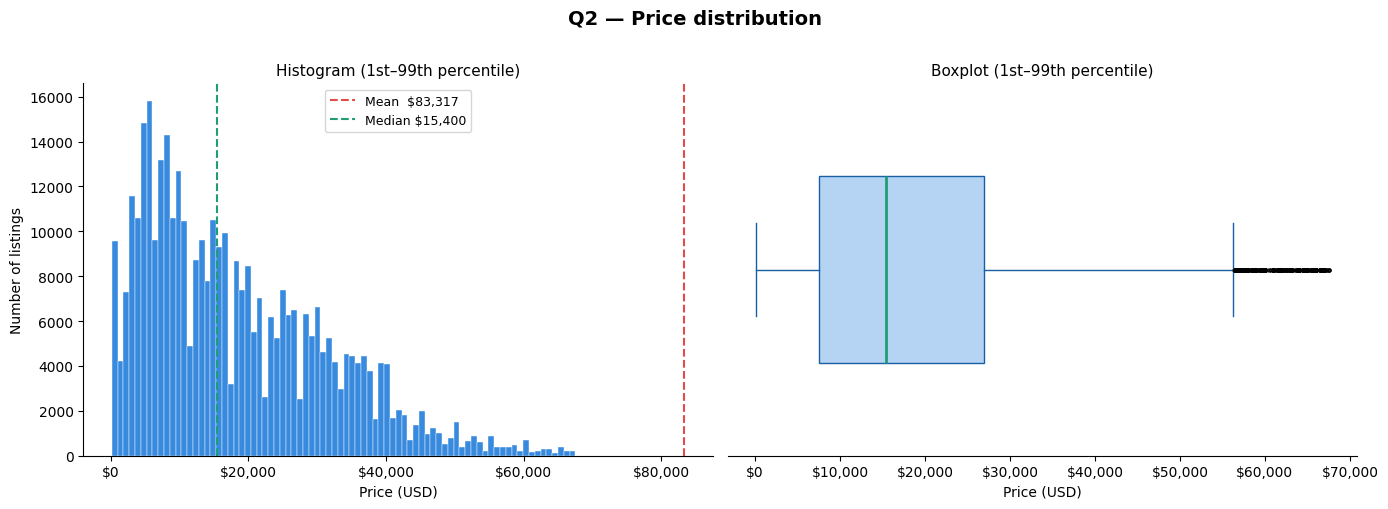


── Price distribution summary ──────────────────
  Count      380,325
  Mean       $83,317
  Median     $15,400
  Std Dev    $12,904,791
  Min        $1
  Max        $3,736,928,711
  Skewness   240.22

── Interpretation ──────────────────────────────
  Right-skewed (skew=240.22) — most listings are budget vehicles,
  but a long tail of high-priced vehicles pulls the mean above the median.


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── FILTER ────────────────────────────────────────────────────
# Remove extreme outliers for clean visualization
q_low  = df['price'].quantile(0.01)
q_high = df['price'].quantile(0.99)
price  = df['price'].dropna()
price_filtered = price[(price >= q_low) & (price <= q_high)]

# ── STATS ─────────────────────────────────────────────────────
stats = {
    'Count'   : f"{price.count():,}",
    'Mean'    : f"${price.mean():,.0f}",
    'Median'  : f"${price.median():,.0f}",
    'Std Dev' : f"${price.std():,.0f}",
    'Min'     : f"${price.min():,.0f}",
    'Max'     : f"${price.max():,.0f}",
    'Skewness': f"{price.skew():.2f}",
}

# ── PLOT ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q2 — Price distribution', fontsize=14, fontweight='bold', y=1.01)

# ── LEFT: Histogram ───────────────────────────────────────────
ax1 = axes[0]
ax1.hist(price_filtered, bins=80, color='#378ADD', edgecolor='white', linewidth=0.3)
ax1.axvline(price.mean(),   color='#E24B4A', linewidth=1.5, linestyle='--', label=f"Mean  ${price.mean():,.0f}")
ax1.axvline(price.median(), color='#1D9E75', linewidth=1.5, linestyle='--', label=f"Median ${price.median():,.0f}")
ax1.set_title('Histogram (1st–99th percentile)', fontsize=11)
ax1.set_xlabel('Price (USD)')
ax1.set_ylabel('Number of listings')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

# ── RIGHT: Boxplot ────────────────────────────────────────────
ax2 = axes[1]
bp = ax2.boxplot(
    price_filtered,
    vert=False,
    patch_artist=True,
    widths=0.5,
    boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
    medianprops=dict(color='#1D9E75', linewidth=2),
    whiskerprops=dict(color='#185FA5'),
    capprops=dict(color='#185FA5'),
    flierprops=dict(marker='o', color='#E24B4A', alpha=0.3, markersize=2)
)
ax2.set_title('Boxplot (1st–99th percentile)', fontsize=11)
ax2.set_xlabel('Price (USD)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.set_yticks([])
ax2.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
plt.savefig('q2_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── STATS TABLE ───────────────────────────────────────────────
print("\n── Price distribution summary ──────────────────")
for k, v in stats.items():
    print(f"  {k:<10} {v}")

skew = price.skew()
print(f"\n── Interpretation ──────────────────────────────")
if skew > 1:
    print(f"  Right-skewed (skew={skew:.2f}) — most listings are budget vehicles,")
    print(f"  but a long tail of high-priced vehicles pulls the mean above the median.")
elif skew < -1:
    print(f"  Left-skewed (skew={skew:.2f}).")
else:
    print(f"  Roughly symmetric (skew={skew:.2f}).")

Q3
What are the top 10 most expensive and cheapest vehicles?

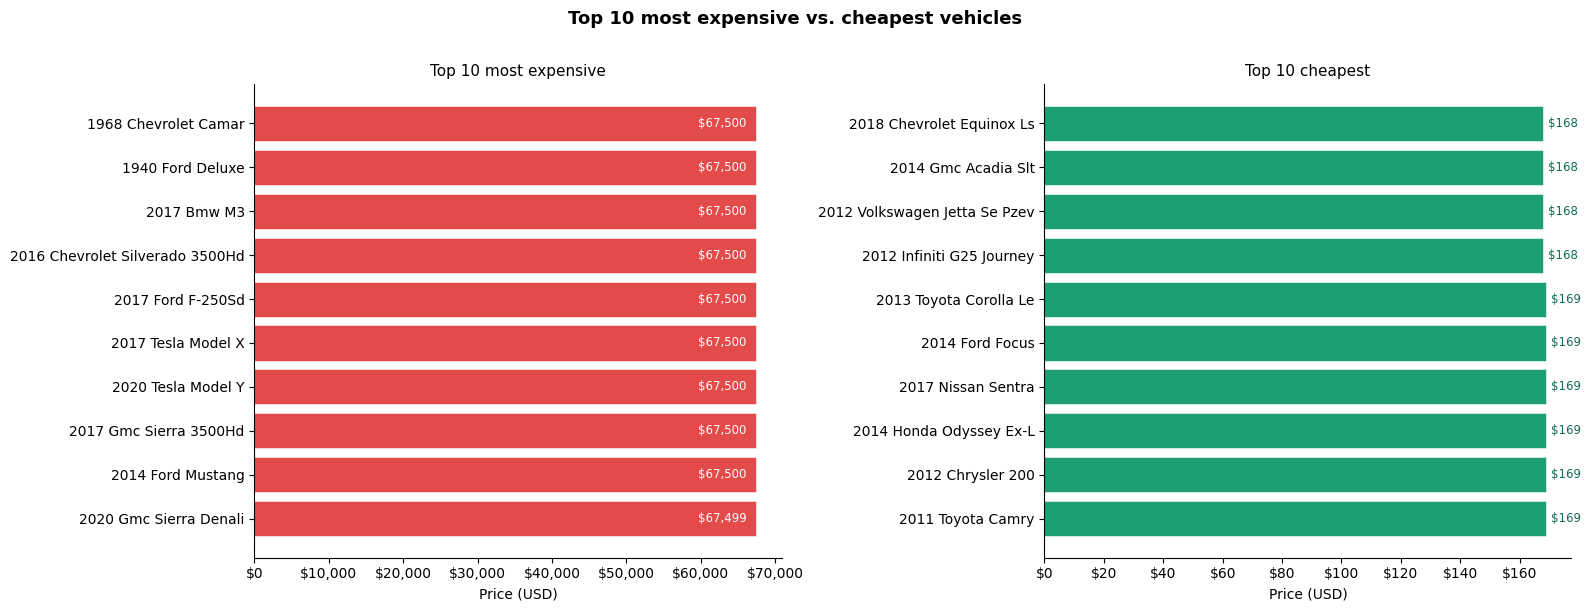


── Top 10 most expensive ───────────────────────────────────────────
                              label  price  condition  odometer state
1              1968 Chevrolet Camar  67500   like new      2500    ak
2                  1940 Ford Deluxe  67500  excellent        54    ca
3                       2017 Bmw M3  67500        new     15000    fl
4   2016 Chevrolet Silverado 3500Hd  67500    UNKNOWN     14180    hi
5                 2017 Ford F-250Sd  67500    UNKNOWN     14606    la
6                2017 Tesla Model X  67500    UNKNOWN     24977    ia
7                2020 Tesla Model Y  67500  excellent      5200    nc
8            2017 Gmc Sierra 3500Hd  67500  excellent     25000    nm
9                 2014 Ford Mustang  67500   like new      2034    wi
10           2020 Gmc Sierra Denali  67499    UNKNOWN     12516    az

── Top 10 cheapest ─────────────────────────────────────────────────
                            label  price  condition  odometer state
1       2018 Chevrolet

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── DATA ──────────────────────────────────────────────────────
cols = ['price', 'year', 'manufacturer', 'model', 'condition', 'odometer', 'state']

df_clean = df[cols].dropna(subset=['price', 'manufacturer', 'model'])
df_clean = df_clean[df_clean['price'] > 0]

# ── 🔥 PERCENTILE FILTERING ───────────────────────────────────
low = df_clean['price'].quantile(0.01)
high = df_clean['price'].quantile(0.99)

df_clean = df_clean[(df_clean['price'] >= low) & (df_clean['price'] <= high)]

# ── LABEL ─────────────────────────────────────────────────────
df_clean['label'] = (
    df_clean['year'].astype(int).astype(str) + ' ' +
    df_clean['manufacturer'].str.title() + ' ' +
    df_clean['model'].str.title()
)

# ── TOP 10 MOST EXPENSIVE ─────────────────────────────────────
top10_exp = (
    df_clean.nlargest(10, 'price')
    [['label', 'price', 'condition', 'odometer', 'state']]
    .reset_index(drop=True)
)
top10_exp.index += 1

# ── TOP 10 CHEAPEST ───────────────────────────────────────────
top10_cheap = (
    df_clean.nsmallest(10, 'price')
    [['label', 'price', 'condition', 'odometer', 'state']]
    .reset_index(drop=True)
)
top10_cheap.index += 1

# ── PLOT ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 10 most expensive vs. cheapest vehicles',
             fontsize=13, fontweight='bold', y=1.01)

# ── LEFT: Most expensive ──────────────────────────────────────
ax1 = axes[0]
bars1 = ax1.barh(
    top10_exp['label'][::-1],
    top10_exp['price'][::-1],
    color='#E24B4A', edgecolor='white', linewidth=0.4
)

for bar, val in zip(bars1, top10_exp['price'][::-1]):
    ax1.text(bar.get_width() * 0.98,
             bar.get_y() + bar.get_height() / 2,
             f"${val:,.0f}",
             va='center', ha='right',
             fontsize=8.5, color='white')

ax1.set_title('Top 10 most expensive', fontsize=11)
ax1.set_xlabel('Price (USD)')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.spines[['top', 'right']].set_visible(False)

# ── RIGHT: Cheapest ───────────────────────────────────────────
ax2 = axes[1]
bars2 = ax2.barh(
    top10_cheap['label'][::-1],
    top10_cheap['price'][::-1],
    color='#1D9E75', edgecolor='white', linewidth=0.4
)

for bar, val in zip(bars2, top10_cheap['price'][::-1]):
    ax2.text(bar.get_width() + max(top10_cheap['price']) * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f"${val:,.0f}",
             va='center', ha='left',
             fontsize=8.5, color='#0F6E56')

ax2.set_title('Top 10 cheapest', fontsize=11)
ax2.set_xlabel('Price (USD)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('q3_top10_price_clean.png', dpi=150, bbox_inches='tight')
plt.show()

# ── PRINT ─────────────────────────────────────────────────────
print("\n── Top 10 most expensive ───────────────────────────────────────────")
print(top10_exp.to_string())

print("\n── Top 10 cheapest ─────────────────────────────────────────────────")
print(top10_cheap.to_string())

print("\n── Insights ────────────────────────────────────────────────────────")
print(f"  Most expensive : {top10_exp.iloc[0]['label']} — ${top10_exp.iloc[0]['price']:,.0f}")
print(f"  Cheapest       : {top10_cheap.iloc[0]['label']} — ${top10_cheap.iloc[0]['price']:,.0f}")
print(f"  Price gap      : ${top10_exp.iloc[0]['price'] - top10_cheap.iloc[0]['price']:,.0f}")

Q4
How does average price vary by manufacturer?

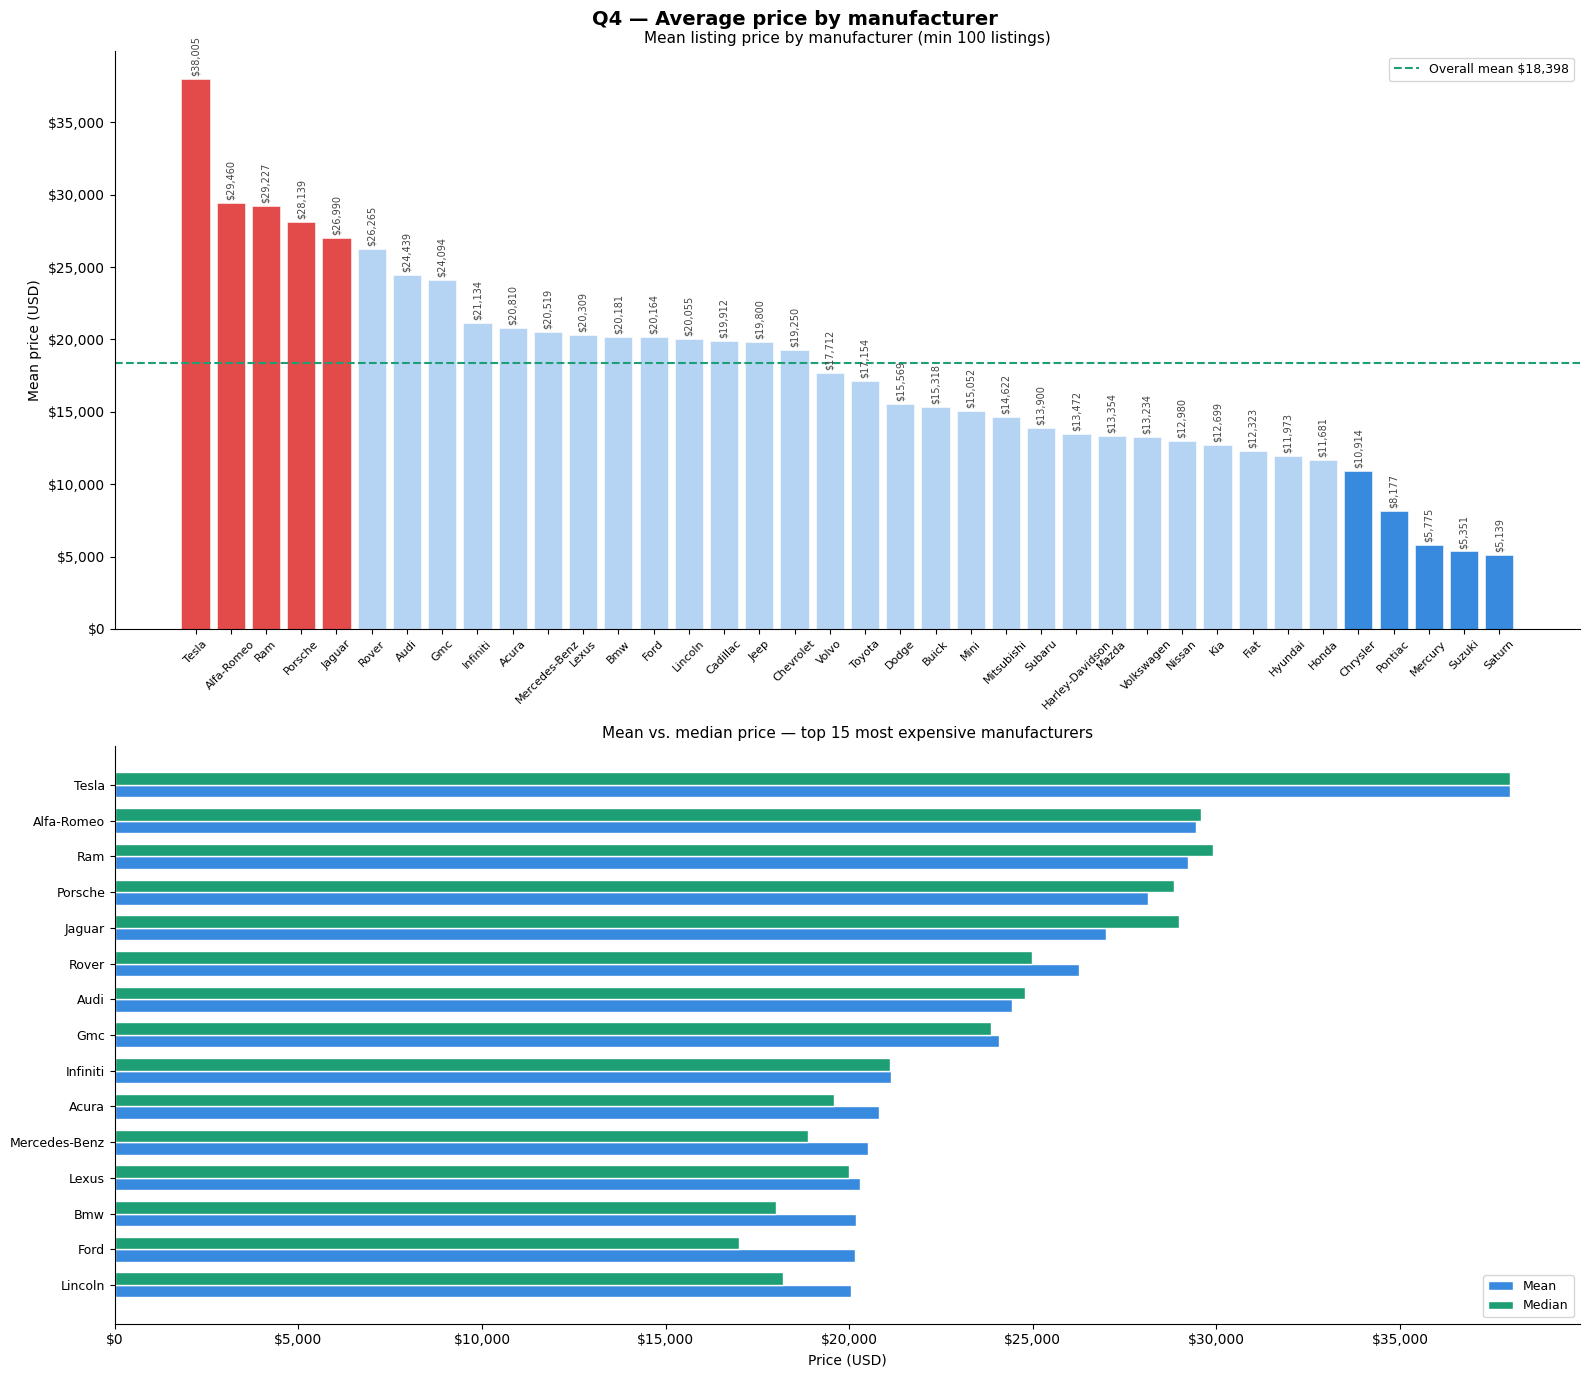


── Average price by manufacturer ───────────────────────────────────
Manufacturer               Mean     Median        Std    Count
──────────────────────────────────────────────────────────────
  Tesla              $   38,005 $   37,990 $   11,744      814
  Alfa-Romeo         $   29,460 $   29,590 $    5,348      856
  Ram                $   29,227 $   29,900 $   14,903   16,244
  Porsche            $   28,139 $   28,850 $   14,819    1,195
  Jaguar             $   26,990 $   28,989 $   14,013    1,903
  Rover              $   26,265 $   24,990 $   15,244    1,866
  Audi               $   24,439 $   24,798 $   13,539    7,037
  Gmc                $   24,094 $   23,868 $   15,441   15,041
  Infiniti           $   21,134 $   21,124 $   11,066    4,460
  Acura              $   20,810 $   19,590 $   12,484    5,650
  Mercedes-Benz      $   20,519 $   18,872 $   13,391   10,050
  Lexus              $   20,309 $   19,990 $   11,463    7,645
  Bmw                $   20,181 $   17,995 $   1

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── DATA ──────────────────────────────────────────────────────
df_clean = df[['price', 'manufacturer']].dropna()
df_clean = df_clean[df_clean['price'] > 0]

# remove price outliers
low  = df_clean['price'].quantile(0.01)
high = df_clean['price'].quantile(0.99)
df_clean = df_clean[(df_clean['price'] >= low) & (df_clean['price'] <= high)]

# ── AGGREGATE ─────────────────────────────────────────────────
mfr_stats = (
    df_clean.groupby('manufacturer')['price']
    .agg(
        mean_price  = 'mean',
        median_price= 'median',
        count       = 'count',
        std         = 'std'
    )
    .reset_index()
    .sort_values('mean_price', ascending=False)
)

# keep only manufacturers with enough listings to be meaningful
mfr_stats = mfr_stats[mfr_stats['count'] >= 100]

# ── PLOT ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 14))
fig.suptitle('Q4 — Average price by manufacturer',
             fontsize=14, fontweight='bold')

# ── TOP: Mean price bar chart ─────────────────────────────────
ax1 = axes[0]

colors = ['#E24B4A' if i < 5 else '#378ADD' if i >= len(mfr_stats) - 5
          else '#B5D4F4' for i in range(len(mfr_stats))]

bars = ax1.bar(
    mfr_stats['manufacturer'].str.title(),
    mfr_stats['mean_price'],
    color=colors, edgecolor='white', linewidth=0.4
)

# add mean price labels on top of bars
for bar, val in zip(bars, mfr_stats['mean_price']):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 200,
             f"${val:,.0f}",
             ha='center', va='bottom',
             fontsize=7, color='#444441', rotation=90)

# overall mean line
overall_mean = df_clean['price'].mean()
ax1.axhline(overall_mean, color='#1D9E75', linewidth=1.5,
            linestyle='--', label=f"Overall mean ${overall_mean:,.0f}")

ax1.set_title('Mean listing price by manufacturer (min 100 listings)', fontsize=11)
ax1.set_ylabel('Mean price (USD)')
ax1.set_xlabel('')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.spines[['top', 'right']].set_visible(False)
ax1.legend(fontsize=9)

# ── BOTTOM: Mean vs Median comparison (top 15 only) ───────────
ax2 = axes[1]

top15 = mfr_stats.head(15).sort_values('mean_price', ascending=True)
x     = np.arange(len(top15))
width = 0.35

bars1 = ax2.barh(x - width/2, top15['mean_price'],   width,
                 color='#378ADD', label='Mean',   edgecolor='white')
bars2 = ax2.barh(x + width/2, top15['median_price'], width,
                 color='#1D9E75', label='Median', edgecolor='white')

ax2.set_yticks(x)
ax2.set_yticklabels(top15['manufacturer'].str.title(), fontsize=9)
ax2.set_title('Mean vs. median price — top 15 most expensive manufacturers', fontsize=11)
ax2.set_xlabel('Price (USD)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('q4_price_by_manufacturer.png', dpi=150, bbox_inches='tight')
plt.show()

# ── PRINT TABLE ───────────────────────────────────────────────
print("\n── Average price by manufacturer ───────────────────────────────────")
print(f"{'Manufacturer':<20} {'Mean':>10} {'Median':>10} {'Std':>10} {'Count':>8}")
print("─" * 62)
for _, row in mfr_stats.iterrows():
    print(f"  {str(row['manufacturer']).title():<18} "
          f"${row['mean_price']:>9,.0f} "
          f"${row['median_price']:>9,.0f} "
          f"${row['std']:>9,.0f} "
          f"{row['count']:>8,}")

# ── INSIGHTS ──────────────────────────────────────────────────
print("\n── Insights ────────────────────────────────────────────────────────")
top    = mfr_stats.iloc[0]
bottom = mfr_stats.iloc[-1]
print(f"  Most expensive  : {str(top['manufacturer']).title():<15} avg ${top['mean_price']:,.0f}")
print(f"  Least expensive : {str(bottom['manufacturer']).title():<15} avg ${bottom['mean_price']:,.0f}")
print(f"  Price gap       : ${top['mean_price'] - bottom['mean_price']:,.0f}")
print(f"  Overall mean    : ${overall_mean:,.0f}")
print(f"  Manufacturers above overall mean : "
      f"{(mfr_stats['mean_price'] > overall_mean).sum()} / {len(mfr_stats)}")

Q5
How does average price vary by vehicle type (pickup, SUV, coupe, etc.)?

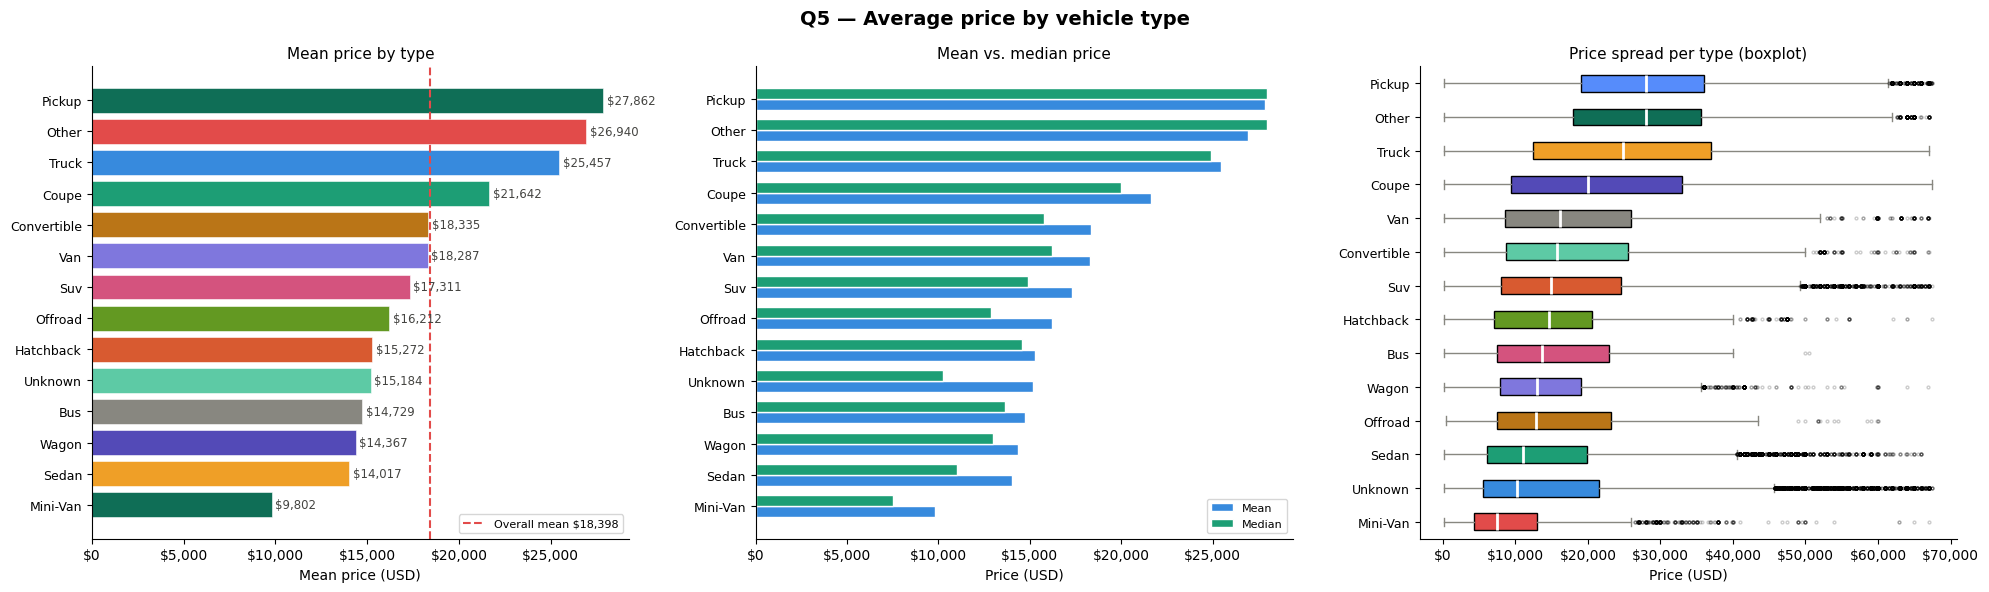


── Average price by vehicle type ───────────────────────────────────
Type                  Mean     Median        Std        Q25        Q75    Count
──────────────────────────────────────────────────────────────────────────────
  Pickup        $   27,862 $   27,990 $   13,222 $   18,990 $   35,969   40,095
  Other         $   26,940 $   27,990 $   12,916 $   17,880 $   35,590   19,159
  Truck         $   25,457 $   24,895 $   15,768 $   12,375 $   36,998   27,993
  Coupe         $   21,642 $   19,998 $   13,789 $    9,400 $   32,990   16,405
  Convertible   $   18,335 $   15,800 $   12,125 $    8,750 $   25,590    6,639
  Van           $   18,287 $   16,194 $   12,187 $    8,550 $   25,950    7,739
  Suv           $   17,311 $   14,900 $   11,999 $    7,995 $   24,500   68,604
  Offroad       $   16,212 $   12,900 $   11,721 $    7,500 $   23,194      563
  Hatchback     $   15,272 $   14,590 $    9,533 $    6,999 $   20,590   14,713
  Unknown       $   15,184 $   10,250 $   13,284 $ 

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── DATA ──────────────────────────────────────────────────────
df_clean = df[['price', 'type']].dropna()
df_clean = df_clean[df_clean['price'] > 0]

# remove price outliers
low  = df_clean['price'].quantile(0.01)
high = df_clean['price'].quantile(0.99)
df_clean = df_clean[(df_clean['price'] >= low) & (df_clean['price'] <= high)]

# ── AGGREGATE ─────────────────────────────────────────────────
type_stats = (
    df_clean.groupby('type')['price']
    .agg(
        mean_price   = 'mean',
        median_price = 'median',
        count        = 'count',
        std          = 'std',
        q25          = lambda x: x.quantile(0.25),
        q75          = lambda x: x.quantile(0.75)
    )
    .reset_index()
    .sort_values('mean_price', ascending=False)
)

# ── COLORS — one per type ──────────────────────────────────────
palette = [
    '#E24B4A','#378ADD','#1D9E75','#BA7517','#7F77DD',
    '#D4537E','#639922','#D85A30','#5DCAA5','#888780',
    '#534AB7','#EF9F27','#0F6E56'
]
colors = palette[:len(type_stats)]

# ── PLOT ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Q5 — Average price by vehicle type',
             fontsize=14, fontweight='bold')

# ── LEFT: Mean price bar chart ────────────────────────────────
ax1 = axes[0]
bars = ax1.barh(
    type_stats['type'].str.title()[::-1],
    type_stats['mean_price'][::-1],
    color=colors[::-1], edgecolor='white', linewidth=0.4
)
for bar, val in zip(bars, type_stats['mean_price'][::-1]):
    ax1.text(bar.get_width() + 200,
             bar.get_y() + bar.get_height() / 2,
             f"${val:,.0f}",
             va='center', ha='left', fontsize=8.5, color='#444441')

overall_mean = df_clean['price'].mean()
ax1.axvline(overall_mean, color='#E24B4A', linewidth=1.5,
            linestyle='--', label=f"Overall mean ${overall_mean:,.0f}")
ax1.set_title('Mean price by type', fontsize=11)
ax1.set_xlabel('Mean price (USD)')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.spines[['top', 'right']].set_visible(False)
ax1.legend(fontsize=8)
ax1.tick_params(axis='y', labelsize=9)

# ── MIDDLE: Mean vs Median ────────────────────────────────────
ax2 = axes[1]
x     = np.arange(len(type_stats))
width = 0.35
type_sorted = type_stats.sort_values('mean_price', ascending=True)

ax2.barh(x - width/2, type_sorted['mean_price'],
         width, color='#378ADD', label='Mean',   edgecolor='white')
ax2.barh(x + width/2, type_sorted['median_price'],
         width, color='#1D9E75', label='Median', edgecolor='white')

ax2.set_yticks(x)
ax2.set_yticklabels(type_sorted['type'].str.title(), fontsize=9)
ax2.set_title('Mean vs. median price', fontsize=11)
ax2.set_xlabel('Price (USD)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(fontsize=8)

# ── RIGHT: Boxplot per type ───────────────────────────────────
ax3 = axes[2]
type_order = type_stats.sort_values('median_price', ascending=True)['type'].tolist()
box_data   = [df_clean[df_clean['type'] == t]['price'].dropna().values
              for t in type_order]

bp = ax3.boxplot(
    box_data,
    vert=False,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#888780'),
    capprops=dict(color='#888780'),
    flierprops=dict(marker='o', alpha=0.2, markersize=2, color='#888780')
)
for patch, color in zip(bp['boxes'], palette[:len(type_order)]):
    patch.set_facecolor(color)

ax3.set_yticks(range(1, len(type_order) + 1))
ax3.set_yticklabels([t.title() for t in type_order], fontsize=9)
ax3.set_title('Price spread per type (boxplot)', fontsize=11)
ax3.set_xlabel('Price (USD)')
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax3.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('q5_price_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

# ── PRINT TABLE ───────────────────────────────────────────────
print("\n── Average price by vehicle type ───────────────────────────────────")
print(f"{'Type':<15} {'Mean':>10} {'Median':>10} {'Std':>10} {'Q25':>10} {'Q75':>10} {'Count':>8}")
print("─" * 78)
for _, row in type_stats.iterrows():
    print(f"  {str(row['type']).title():<13} "
          f"${row['mean_price']:>9,.0f} "
          f"${row['median_price']:>9,.0f} "
          f"${row['std']:>9,.0f} "
          f"${row['q25']:>9,.0f} "
          f"${row['q75']:>9,.0f} "
          f"{row['count']:>8,}")

# ── INSIGHTS ──────────────────────────────────────────────────
top    = type_stats.iloc[0]
bottom = type_stats.iloc[-1]
print("\n── Insights ────────────────────────────────────────────────────────")
print(f"  Most expensive type  : {str(top['type']).title():<12} avg ${top['mean_price']:,.0f}")
print(f"  Least expensive type : {str(bottom['type']).title():<12} avg ${bottom['mean_price']:,.0f}")
print(f"  Price gap            : ${top['mean_price'] - bottom['mean_price']:,.0f}")
print(f"  Overall mean         : ${overall_mean:,.0f}")
print(f"  Types above mean     : {(type_stats['mean_price'] > overall_mean).sum()} / {len(type_stats)}")

# mean vs median gap — reveals skew per type
print("\n── Mean vs. median gap (skew indicator) ────────────────────────────")
type_stats['gap'] = type_stats['mean_price'] - type_stats['median_price']
for _, row in type_stats.sort_values('gap', ascending=False).iterrows():
    direction = 'right-skewed' if row['gap'] > 0 else 'left-skewed'
    print(f"  {str(row['type']).title():<15} gap ${row['gap']:>8,.0f}  →  {direction}")

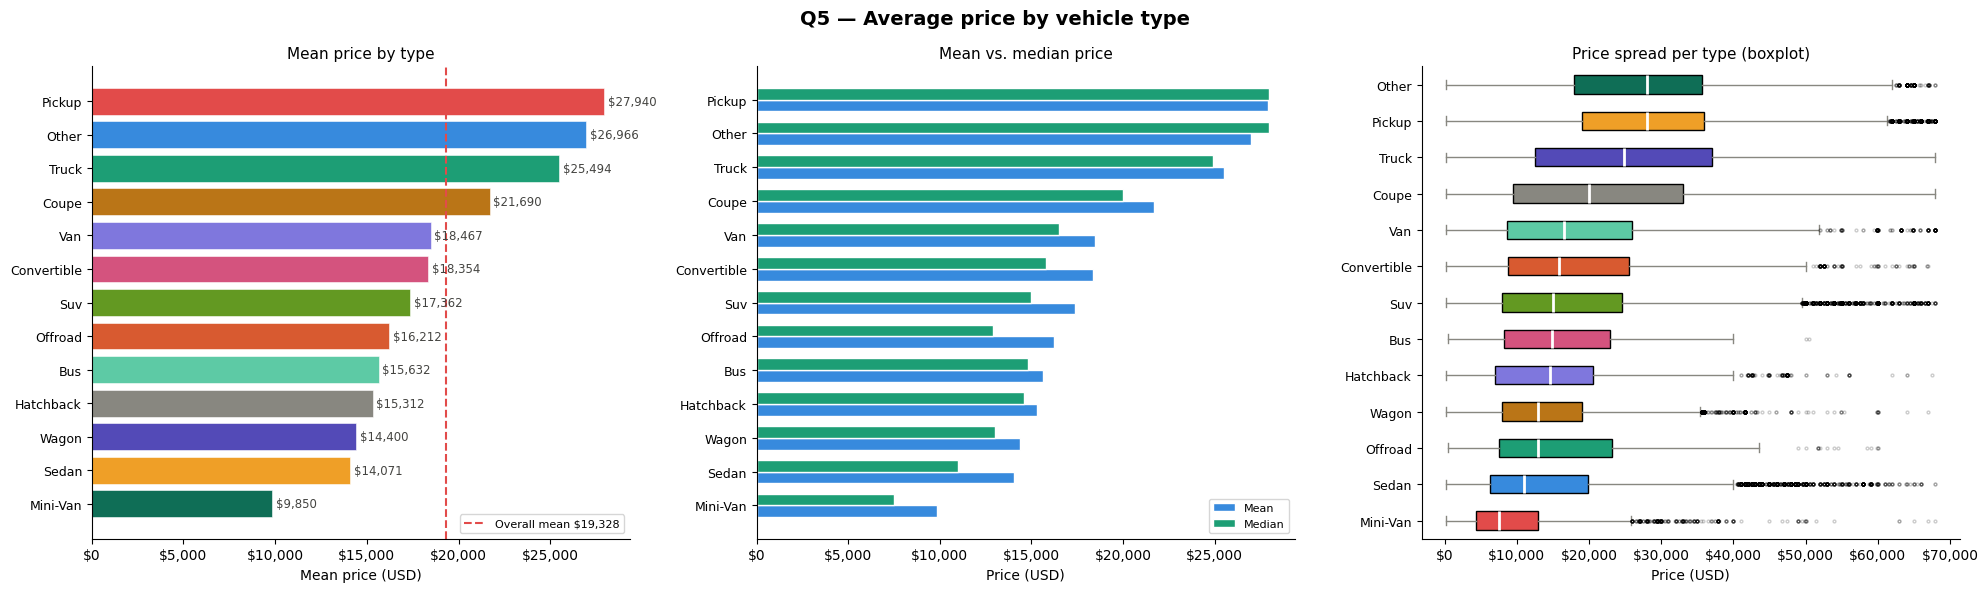


── Average price by vehicle type ───────────────────────────────────
Type                  Mean     Median        Std        Q25        Q75    Count
──────────────────────────────────────────────────────────────────────────────
  Pickup        $   27,940 $   27,990 $   13,322 $   18,990 $   35,990   40,168
  Other         $   26,966 $   27,990 $   12,909 $   17,900 $   35,590   19,148
  Truck         $   25,494 $   24,900 $   15,775 $   12,495 $   36,999   27,979
  Coupe         $   21,690 $   19,999 $   13,823 $    9,495 $   32,990   16,400
  Van           $   18,467 $   16,500 $   12,452 $    8,700 $   25,990    7,748
  Convertible   $   18,354 $   15,800 $   12,118 $    8,799 $   25,590    6,632
  Suv           $   17,362 $   14,950 $   11,993 $    7,995 $   24,590   68,431
  Offroad       $   16,212 $   12,900 $   11,721 $    7,500 $   23,194      563
  Bus           $   15,632 $   14,825 $    8,934 $    8,225 $   22,950      290
  Hatchback     $   15,312 $   14,590 $    9,514 $ 

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── DATA ──────────────────────────────────────────────────────
df_clean = df[['price', 'type']].dropna()
df_clean = df_clean[df_clean['price'] > 0]

# IGNORE UNKNOWN TYPES
df_clean = df_clean[df_clean['type'].str.lower() != 'unknown']

# remove price outliers
low  = df_clean['price'].quantile(0.01)
high = df_clean['price'].quantile(0.99)
df_clean = df_clean[(df_clean['price'] >= low) & (df_clean['price'] <= high)]

# ── AGGREGATE ─────────────────────────────────────────────────
type_stats = (
    df_clean.groupby('type')['price']
    .agg(
        mean_price   = 'mean',
        median_price = 'median',
        count        = 'count',
        std          = 'std',
        q25          = lambda x: x.quantile(0.25),
        q75          = lambda x: x.quantile(0.75)
    )
    .reset_index()
    .sort_values('mean_price', ascending=False)
)

# ── COLORS — one per type ──────────────────────────────────────
palette = [
    '#E24B4A','#378ADD','#1D9E75','#BA7517','#7F77DD',
    '#D4537E','#639922','#D85A30','#5DCAA5','#888780',
    '#534AB7','#EF9F27','#0F6E56'
]
colors = palette[:len(type_stats)]

# ── PLOT ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Q5 — Average price by vehicle type',
             fontsize=14, fontweight='bold')

# ── LEFT: Mean price bar chart ────────────────────────────────
ax1 = axes[0]
bars = ax1.barh(
    type_stats['type'].str.title()[::-1],
    type_stats['mean_price'][::-1],
    color=colors[::-1], edgecolor='white', linewidth=0.4
)
for bar, val in zip(bars, type_stats['mean_price'][::-1]):
    ax1.text(bar.get_width() + 200,
             bar.get_y() + bar.get_height() / 2,
             f"${val:,.0f}",
             va='center', ha='left', fontsize=8.5, color='#444441')

overall_mean = df_clean['price'].mean()
ax1.axvline(overall_mean, color='#E24B4A', linewidth=1.5,
            linestyle='--', label=f"Overall mean ${overall_mean:,.0f}")
ax1.set_title('Mean price by type', fontsize=11)
ax1.set_xlabel('Mean price (USD)')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.spines[['top', 'right']].set_visible(False)
ax1.legend(fontsize=8)
ax1.tick_params(axis='y', labelsize=9)

# ── MIDDLE: Mean vs Median ────────────────────────────────────
ax2 = axes[1]
x     = np.arange(len(type_stats))
width = 0.35
type_sorted = type_stats.sort_values('mean_price', ascending=True)

ax2.barh(x - width/2, type_sorted['mean_price'],
         width, color='#378ADD', label='Mean',   edgecolor='white')
ax2.barh(x + width/2, type_sorted['median_price'],
         width, color='#1D9E75', label='Median', edgecolor='white')

ax2.set_yticks(x)
ax2.set_yticklabels(type_sorted['type'].str.title(), fontsize=9)
ax2.set_title('Mean vs. median price', fontsize=11)
ax2.set_xlabel('Price (USD)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(fontsize=8)

# ── RIGHT: Boxplot per type ───────────────────────────────────
ax3 = axes[2]
type_order = type_stats.sort_values('median_price', ascending=True)['type'].tolist()
box_data   = [df_clean[df_clean['type'] == t]['price'].dropna().values
              for t in type_order]

bp = ax3.boxplot(
    box_data,
    vert=False,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#888780'),
    capprops=dict(color='#888780'),
    flierprops=dict(marker='o', alpha=0.2, markersize=2, color='#888780')
)
for patch, color in zip(bp['boxes'], palette[:len(type_order)]):
    patch.set_facecolor(color)

ax3.set_yticks(range(1, len(type_order) + 1))
ax3.set_yticklabels([t.title() for t in type_order], fontsize=9)
ax3.set_title('Price spread per type (boxplot)', fontsize=11)
ax3.set_xlabel('Price (USD)')
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax3.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('q5_price_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

# ── PRINT TABLE ───────────────────────────────────────────────
print("\n── Average price by vehicle type ───────────────────────────────────")
print(f"{'Type':<15} {'Mean':>10} {'Median':>10} {'Std':>10} {'Q25':>10} {'Q75':>10} {'Count':>8}")
print("─" * 78)
for _, row in type_stats.iterrows():
    print(f"  {str(row['type']).title():<13} "
          f"${row['mean_price']:>9,.0f} "
          f"${row['median_price']:>9,.0f} "
          f"${row['std']:>9,.0f} "
          f"${row['q25']:>9,.0f} "
          f"${row['q75']:>9,.0f} "
          f"{row['count']:>8,}")

# ── INSIGHTS ──────────────────────────────────────────────────
top    = type_stats.iloc[0]
bottom = type_stats.iloc[-1]
print("\n── Insights ────────────────────────────────────────────────────────")
print(f"  Most expensive type  : {str(top['type']).title():<12} avg ${top['mean_price']:,.0f}")
print(f"  Least expensive type : {str(bottom['type']).title():<12} avg ${bottom['mean_price']:,.0f}")
print(f"  Price gap            : ${top['mean_price'] - bottom['mean_price']:,.0f}")
print(f"  Overall mean         : ${overall_mean:,.0f}")
print(f"  Types above mean     : {(type_stats['mean_price'] > overall_mean).sum()} / {len(type_stats)}")

# mean vs median gap — reveals skew per type
print("\n── Mean vs. median gap (skew indicator) ────────────────────────────")
type_stats['gap'] = type_stats['mean_price'] - type_stats['median_price']
for _, row in type_stats.sort_values('gap', ascending=False).iterrows():
    direction = 'right-skewed' if row['gap'] > 0 else 'left-skewed'
    print(f"  {str(row['type']).title():<15} gap ${row['gap']:>8,.0f}  →  {direction}")

## **Odometer analysis**

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── SHARED CLEANING ───────────────────────────────────────────
df_odo = df[['odometer', 'price', 'manufacturer', 'model',
             'condition', 'fuel', 'type', 'year']].copy()
df_odo = df_odo[df_odo['odometer'] > 0]
df_odo = df_odo[df_odo['price']    > 0]

low  = df_odo['odometer'].quantile(0.01)
high = df_odo['odometer'].quantile(0.99)
df_odo = df_odo[(df_odo['odometer'] >= low) & (df_odo['odometer'] <= high)]

# ── vehicle age ───────────────────────────────────────────────
df_odo['vehicle_age'] = 2021 - df_odo['year']
df_odo = df_odo[df_odo['vehicle_age'].between(0, 40)]

print("=" * 65)
print("  ODOMETER / MILEAGE ANALYSIS — Q17, Q20, Q22, Q26, Q27")
print("=" * 65)

  ODOMETER / MILEAGE ANALYSIS — Q17, Q20, Q22, Q26, Q27


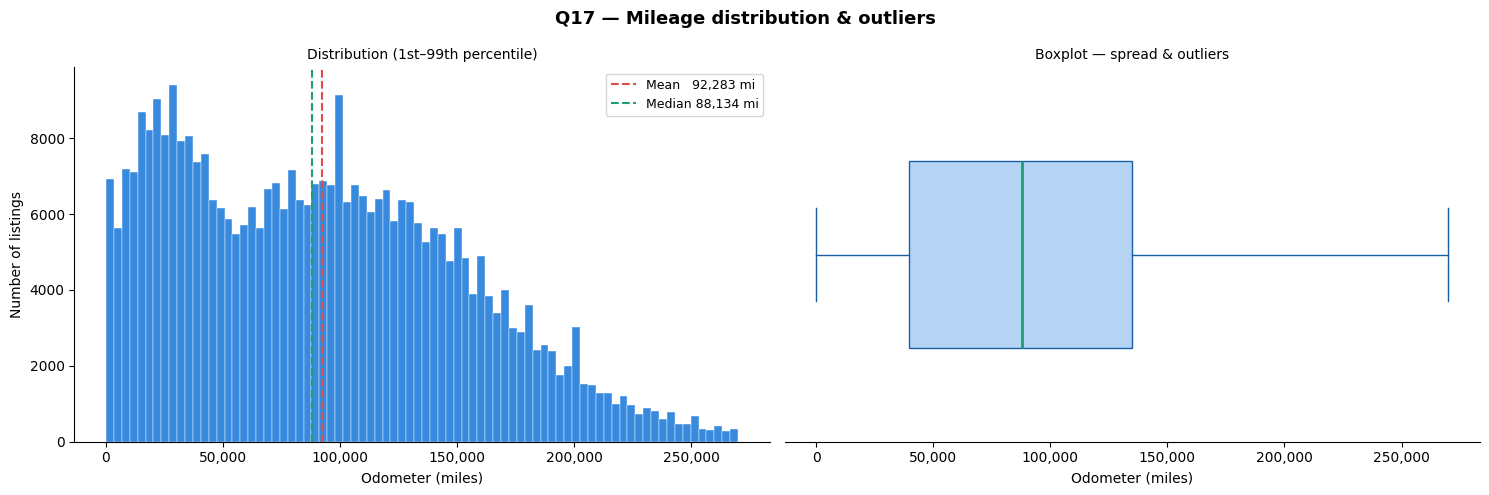


── Q17 Mileage summary ─────────────────────────────────
  Count   : 365,650
  Mean    : 92,283 miles
  Median  : 88,134 miles
  Std     : 59,994 miles
  Min     : 102 miles
  Max     : 270,000 miles
  Skew    : 0.44
  Q1      : 39,650 miles
  Q3      : 135,000 miles


In [11]:
# ════════════════════════════════════════════════════════════════
# Q17 — Mileage distribution & outliers
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Q17 — Mileage distribution & outliers',
             fontsize=13, fontweight='bold')

odo = df_odo['odometer']

# LEFT: Histogram
ax1 = axes[0]
ax1.hist(odo, bins=80, color='#378ADD', edgecolor='white', linewidth=0.3)
ax1.axvline(odo.mean(),   color='#E24B4A', linewidth=1.5,
            linestyle='--', label=f"Mean   {odo.mean():,.0f} mi")
ax1.axvline(odo.median(), color='#1D9E75', linewidth=1.5,
            linestyle='--', label=f"Median {odo.median():,.0f} mi")
ax1.set_title('Distribution (1st–99th percentile)', fontsize=10)
ax1.set_xlabel('Odometer (miles)')
ax1.set_ylabel('Number of listings')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax1.legend(fontsize=9)
ax1.spines[['top','right']].set_visible(False)

# RIGHT: Boxplot
ax2 = axes[1]
ax2.boxplot(odo, vert=False, patch_artist=True, widths=0.5,
            boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
            medianprops=dict(color='#1D9E75', linewidth=2),
            whiskerprops=dict(color='#185FA5'),
            capprops=dict(color='#185FA5'),
            flierprops=dict(marker='o', color='#E24B4A',
                            alpha=0.2, markersize=2))
ax2.set_title('Boxplot — spread & outliers', fontsize=10)
ax2.set_xlabel('Odometer (miles)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax2.set_yticks([])
ax2.spines[['top','right','left']].set_visible(False)

plt.tight_layout()
plt.savefig('q17_mileage_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Q17 Mileage summary ─────────────────────────────────")
print(f"  Count   : {odo.count():,}")
print(f"  Mean    : {odo.mean():,.0f} miles")
print(f"  Median  : {odo.median():,.0f} miles")
print(f"  Std     : {odo.std():,.0f} miles")
print(f"  Min     : {odo.min():,.0f} miles")
print(f"  Max     : {odo.max():,.0f} miles")
print(f"  Skew    : {odo.skew():.2f}")
print(f"  Q1      : {odo.quantile(0.25):,.0f} miles")
print(f"  Q3      : {odo.quantile(0.75):,.0f} miles")

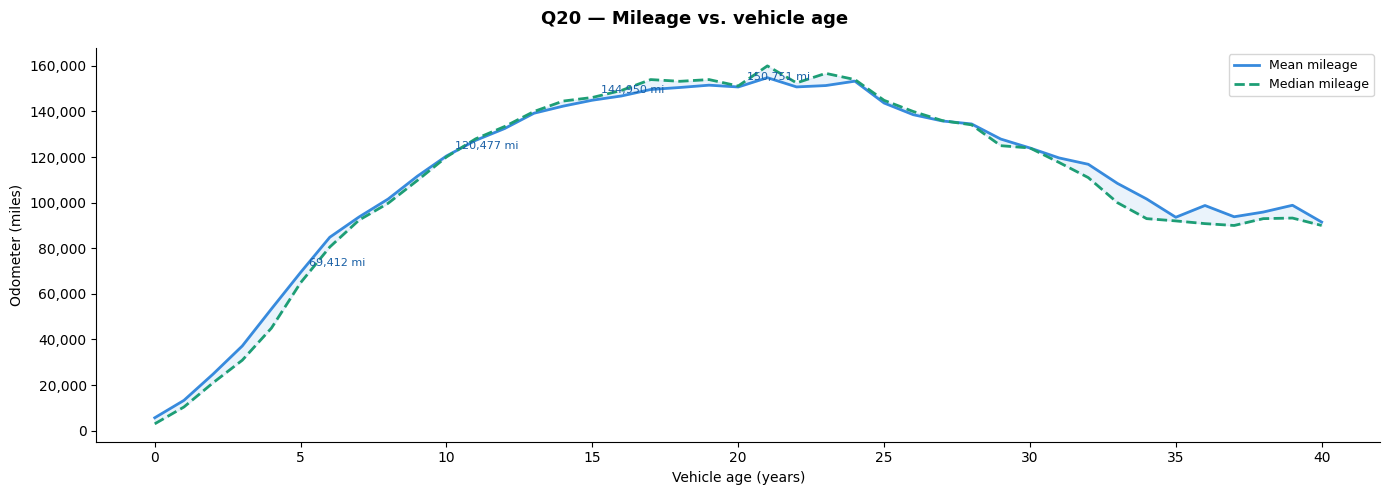


── Q20 Mileage by vehicle age (every 5 years) ──────────
  Age (yrs)      Mean miles   Median miles   Listings
  ────────────────────────────────────────────────────
  0                   5,652          2,995        949
  5                  69,412         64,907     25,993
  10                120,477        120,073     18,386
  15                144,950        146,148     11,166
  20                150,751        151,184      3,884
  25                143,713        144,900      1,105
  30                123,992        124,000        536
  35                 93,607         92,004        448
  40                 91,500         90,000        175


In [12]:
# ════════════════════════════════════════════════════════════════
# Q20 — How does mileage vary by vehicle age?
# ════════════════════════════════════════════════════════════════
age_odo = (
    df_odo.groupby('vehicle_age')['odometer']
    .agg(mean='mean', median='median', count='count')
    .reset_index()
)
age_odo = age_odo[age_odo['count'] >= 50]

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Q20 — Mileage vs. vehicle age',
             fontsize=13, fontweight='bold')

ax.plot(age_odo['vehicle_age'], age_odo['mean'],
        color='#378ADD', linewidth=2, label='Mean mileage')
ax.plot(age_odo['vehicle_age'], age_odo['median'],
        color='#1D9E75', linewidth=2,
        linestyle='--', label='Median mileage')
ax.fill_between(age_odo['vehicle_age'],
                age_odo['mean'], age_odo['median'],
                alpha=0.1, color='#378ADD')

ax.set_xlabel('Vehicle age (years)')
ax.set_ylabel('Odometer (miles)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.spines[['top','right']].set_visible(False)
ax.legend(fontsize=9)

# annotate expected mileage at 5 year intervals
for age in [5, 10, 15, 20]:
    row = age_odo[age_odo['vehicle_age'] == age]
    if not row.empty:
        val = row['mean'].values[0]
        ax.annotate(f"{val:,.0f} mi",
                    xy=(age, val),
                    xytext=(age + 0.3, val + 3000),
                    fontsize=8, color='#185FA5')

plt.tight_layout()
plt.savefig('q20_mileage_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Q20 Mileage by vehicle age (every 5 years) ──────────")
print(f"  {'Age (yrs)':<12} {'Mean miles':>12} {'Median miles':>14} {'Listings':>10}")
print("  " + "─" * 52)
for _, row in age_odo[age_odo['vehicle_age'] % 5 == 0].iterrows():
    print(f"  {int(row['vehicle_age']):<12} "
          f"{row['mean']:>12,.0f} "
          f"{row['median']:>14,.0f} "
          f"{int(row['count']):>10,}")

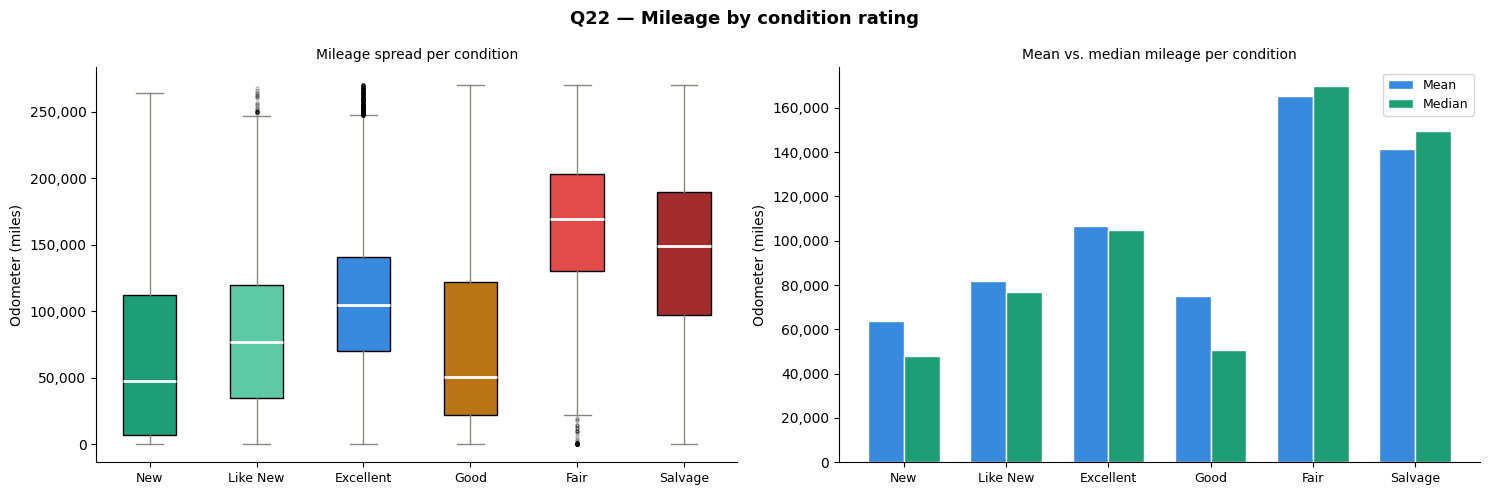


── Q22 Mileage by condition ─────────────────────────────
  Condition      Mean miles   Median miles    Count
  ──────────────────────────────────────────────────
  New                63,952         48,000      716
  Like New           81,971         77,013   18,942
  Excellent         106,809        105,000   87,734
  Good               75,204         50,473  111,026
  Fair              165,432        169,815    5,160
  Salvage           141,585        149,500      474


In [13]:
# ════════════════════════════════════════════════════════════════
# Q22 — Mileage vs. condition rating
# ════════════════════════════════════════════════════════════════
cond_order = ['new', 'like new', 'excellent', 'good', 'fair', 'salvage']
df_cond = df_odo[df_odo['condition'].isin(cond_order)].copy()

cond_stats = (
    df_cond.groupby('condition')['odometer']
    .agg(mean='mean', median='median', count='count')
    .reindex(cond_order)
    .dropna()
    .reset_index()
)

box_data = [df_cond[df_cond['condition'] == c]['odometer'].values
            for c in cond_order if c in df_cond['condition'].values]
labels   = [c.title() for c in cond_order
            if c in df_cond['condition'].values]

palette  = ['#1D9E75','#5DCAA5','#378ADD','#BA7517','#E24B4A','#A32D2D']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Q22 — Mileage by condition rating',
             fontsize=13, fontweight='bold')

# LEFT: Boxplot
ax1 = axes[0]
bp = ax1.boxplot(box_data, patch_artist=True, widths=0.5,
                 medianprops=dict(color='white', linewidth=2),
                 whiskerprops=dict(color='#888780'),
                 capprops=dict(color='#888780'),
                 flierprops=dict(marker='o', alpha=0.15,
                                 markersize=2, color='#888780'))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
ax1.set_xticklabels(labels, fontsize=9)
ax1.set_ylabel('Odometer (miles)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax1.set_title('Mileage spread per condition', fontsize=10)
ax1.spines[['top','right']].set_visible(False)

# RIGHT: Mean & median bars
ax2 = axes[1]
x     = np.arange(len(cond_stats))
width = 0.35
ax2.bar(x - width/2, cond_stats['mean'],   width,
        color='#378ADD', label='Mean',   edgecolor='white')
ax2.bar(x + width/2, cond_stats['median'], width,
        color='#1D9E75', label='Median', edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(cond_stats['condition'].str.title(), fontsize=9)
ax2.set_ylabel('Odometer (miles)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax2.set_title('Mean vs. median mileage per condition', fontsize=10)
ax2.spines[['top','right']].set_visible(False)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('q22_mileage_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Q22 Mileage by condition ─────────────────────────────")
print(f"  {'Condition':<12} {'Mean miles':>12} {'Median miles':>14} {'Count':>8}")
print("  " + "─" * 50)
for _, row in cond_stats.iterrows():
    print(f"  {str(row['condition']).title():<12} "
          f"{row['mean']:>12,.0f} "
          f"{row['median']:>14,.0f} "
          f"{int(row['count']):>8,}")

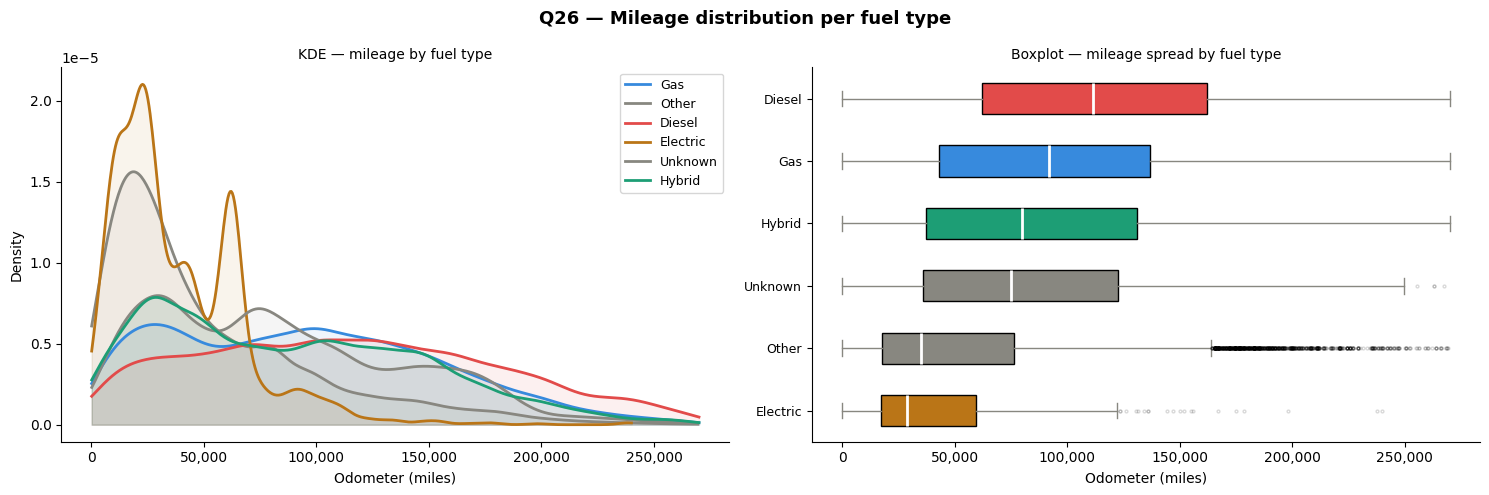


── Q26 Mileage by fuel type ─────────────────────────────
  Fuel               Mean       Median          Std    Count
  ──────────────────────────────────────────────────────────
  Diesel          114,171      111,301       65,487   21,906
  Gas              94,606       92,000       59,141  308,596
  Hybrid           88,103       79,958       59,076    4,772
  Unknown          84,065       75,108       55,111    2,062
  Other            52,066       35,226       46,706   26,795
  Electric         38,483       28,902       28,926    1,519


In [14]:
# ════════════════════════════════════════════════════════════════
# Q26 — Mileage distribution per fuel type
# ════════════════════════════════════════════════════════════════
fuel_types = df_odo['fuel'].dropna().unique()
fuel_colors = {
    'gas'      : '#378ADD',
    'diesel'   : '#E24B4A',
    'hybrid'   : '#1D9E75',
    'electric' : '#BA7517',
    'other'    : '#888780'
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Q26 — Mileage distribution per fuel type',
             fontsize=13, fontweight='bold')

# LEFT: Overlapping KDE
ax1 = axes[0]
from scipy.stats import gaussian_kde
for fuel in fuel_types:
    data = df_odo[df_odo['fuel'] == fuel]['odometer'].dropna()
    if len(data) < 100:
        continue
    kde  = gaussian_kde(data, bw_method=0.15)
    x    = np.linspace(data.min(), data.max(), 500)
    y    = kde(x)
    color = fuel_colors.get(str(fuel), '#888780')
    ax1.plot(x, y, linewidth=2, label=str(fuel).title(), color=color)
    ax1.fill_between(x, y, alpha=0.08, color=color)

ax1.set_xlabel('Odometer (miles)')
ax1.set_ylabel('Density')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax1.set_title('KDE — mileage by fuel type', fontsize=10)
ax1.spines[['top','right']].set_visible(False)
ax1.legend(fontsize=9)

# RIGHT: Boxplot per fuel type
ax2 = axes[1]
fuel_order = (
    df_odo.groupby('fuel')['odometer']
    .median()
    .sort_values()
    .index.tolist()
)
box_data2 = [df_odo[df_odo['fuel'] == f]['odometer'].values
             for f in fuel_order]
colors2   = [fuel_colors.get(str(f), '#888780') for f in fuel_order]

bp2 = ax2.boxplot(box_data2, vert=False, patch_artist=True,
                  widths=0.5,
                  medianprops=dict(color='white', linewidth=2),
                  whiskerprops=dict(color='#888780'),
                  capprops=dict(color='#888780'),
                  flierprops=dict(marker='o', alpha=0.15,
                                  markersize=2, color='#888780'))
for patch, color in zip(bp2['boxes'], colors2):
    patch.set_facecolor(color)

ax2.set_yticks(range(1, len(fuel_order) + 1))
ax2.set_yticklabels([str(f).title() for f in fuel_order], fontsize=9)
ax2.set_xlabel('Odometer (miles)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax2.set_title('Boxplot — mileage spread by fuel type', fontsize=10)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('q26_mileage_by_fuel.png', dpi=150, bbox_inches='tight')
plt.show()

fuel_stats = (
    df_odo.groupby('fuel')['odometer']
    .agg(mean='mean', median='median', std='std', count='count')
    .sort_values('median', ascending=False)
)
print("\n── Q26 Mileage by fuel type ─────────────────────────────")
print(f"  {'Fuel':<10} {'Mean':>12} {'Median':>12} {'Std':>12} {'Count':>8}")
print("  " + "─" * 58)
for fuel, row in fuel_stats.iterrows():
    print(f"  {str(fuel).title():<10} "
          f"{row['mean']:>12,.0f} "
          f"{row['median']:>12,.0f} "
          f"{row['std']:>12,.0f} "
          f"{int(row['count']):>8,}")

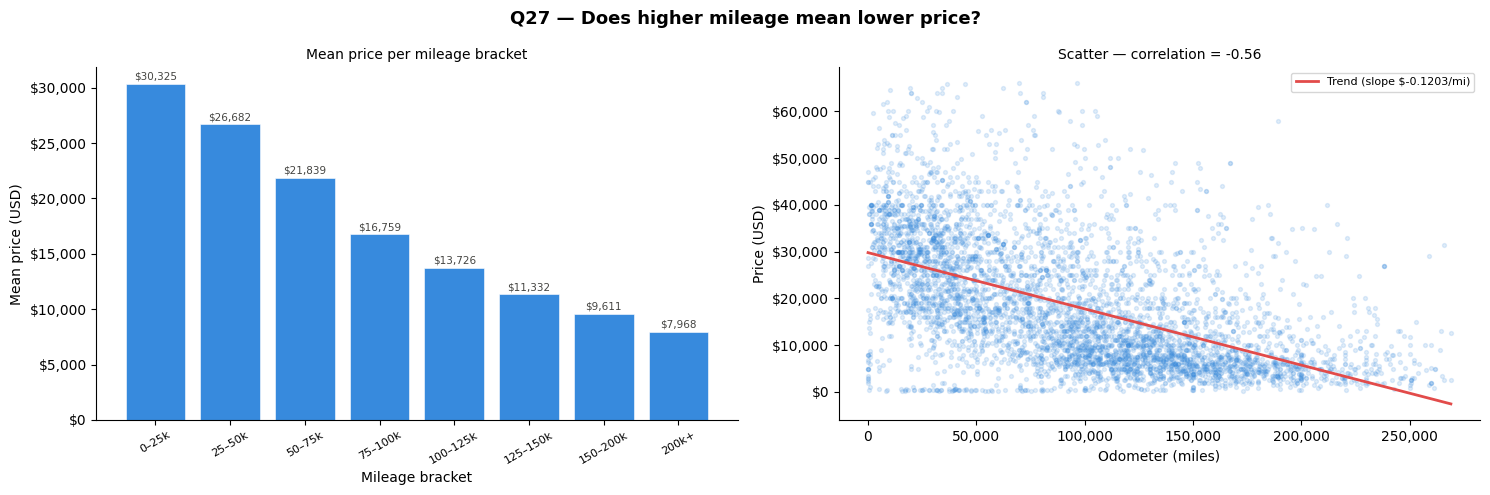


── Q27 Price by mileage bracket ────────────────────────
  Bracket        Mean price   Median price    Count
  ────────────────────────────────────────────────────
  0–25k        $     30,325 $       30,398   53,638
  25–50k       $     26,682 $       25,990   54,969
  50–75k       $     21,839 $       19,000   43,734
  75–100k      $     16,759 $       13,999   50,312
  100–125k     $     13,726 $       10,995   47,627
  125–150k     $     11,332 $        8,494   41,957
  150–200k     $      9,611 $        6,700   49,209
  200k+        $      7,968 $        5,495   16,912

  Pearson correlation (odometer vs price) : -0.558
  Interpretation : strong negative relationship


In [15]:
# ════════════════════════════════════════════════════════════════
# Q27 — Do higher-mileage vehicles sell for less?
# ════════════════════════════════════════════════════════════════
df_q27 = df_odo[['odometer', 'price']].dropna()

# price outlier filter
p_low  = df_q27['price'].quantile(0.01)
p_high = df_q27['price'].quantile(0.99)
df_q27 = df_q27[(df_q27['price'] >= p_low) & (df_q27['price'] <= p_high)]

# bin odometer into brackets
bins   = [0, 25000, 50000, 75000, 100000, 125000, 150000, 200000, 999999]
labels = ['0–25k','25–50k','50–75k','75–100k',
          '100–125k','125–150k','150–200k','200k+']
df_q27['odo_bin'] = pd.cut(df_q27['odometer'], bins=bins, labels=labels)

bin_stats = (
    df_q27.groupby('odo_bin', observed=True)['price']
    .agg(mean='mean', median='median', count='count')
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Q27 — Does higher mileage mean lower price?',
             fontsize=13, fontweight='bold')

# LEFT: Mean price per mileage bracket
ax1 = axes[0]
bars = ax1.bar(bin_stats['odo_bin'].astype(str),
               bin_stats['mean'],
               color='#378ADD', edgecolor='white', linewidth=0.4)
for bar, val in zip(bars, bin_stats['mean']):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 200,
             f"${val:,.0f}",
             ha='center', va='bottom', fontsize=7.5, color='#444441')

ax1.set_xlabel('Mileage bracket')
ax1.set_ylabel('Mean price (USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax1.set_title('Mean price per mileage bracket', fontsize=10)
ax1.spines[['top','right']].set_visible(False)
ax1.tick_params(axis='x', rotation=30, labelsize=8)

# RIGHT: Scatter sample + trend line
ax2 = axes[1]
sample = df_q27.sample(min(5000, len(df_q27)), random_state=42)
ax2.scatter(sample['odometer'], sample['price'],
            alpha=0.15, s=8, color='#378ADD')

# trend line
z   = np.polyfit(sample['odometer'], sample['price'], 1)
p   = np.poly1d(z)
x_line = np.linspace(sample['odometer'].min(),
                     sample['odometer'].max(), 300)
ax2.plot(x_line, p(x_line), color='#E24B4A',
         linewidth=2, label=f"Trend (slope ${z[0]:,.4f}/mi)")

corr = df_q27['odometer'].corr(df_q27['price'])
ax2.set_xlabel('Odometer (miles)')
ax2.set_ylabel('Price (USD)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax2.set_title(f'Scatter — correlation = {corr:.2f}', fontsize=10)
ax2.spines[['top','right']].set_visible(False)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('q27_mileage_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Q27 Price by mileage bracket ────────────────────────")
print(f"  {'Bracket':<12} {'Mean price':>12} {'Median price':>14} {'Count':>8}")
print("  " + "─" * 52)
for _, row in bin_stats.iterrows():
    print(f"  {str(row['odo_bin']):<12} "
          f"${row['mean']:>11,.0f} "
          f"${row['median']:>13,.0f} "
          f"{int(row['count']):>8,}")
print(f"\n  Pearson correlation (odometer vs price) : {corr:.3f}")
direction = 'negative' if corr < 0 else 'positive'
strength  = 'strong' if abs(corr) > 0.5 else 'moderate' if abs(corr) > 0.3 else 'weak'
print(f"  Interpretation : {strength} {direction} relationship")

## **Manufacturer & model analysis**


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── SHARED CLEANING ───────────────────────────────────────────
df_mfr = df[['price', 'manufacturer', 'model', 'year',
             'odometer', 'condition', 'fuel', 'type', 'state']].copy()

df_mfr = df_mfr[df_mfr['price']    > 0]
df_mfr = df_mfr[df_mfr['odometer'] > 0]
df_mfr = df_mfr.dropna(subset=['manufacturer'])

# price outlier filter
p_low  = df_mfr['price'].quantile(0.01)
p_high = df_mfr['price'].quantile(0.99)
df_mfr = df_mfr[(df_mfr['price'] >= p_low) & (df_mfr['price'] <= p_high)]

# odometer outlier filter
o_low  = df_mfr['odometer'].quantile(0.01)
o_high = df_mfr['odometer'].quantile(0.99)
df_mfr = df_mfr[(df_mfr['odometer'] >= o_low) & (df_mfr['odometer'] <= o_high)]

# vehicle age
df_mfr['vehicle_age'] = 2021 - df_mfr['year']
df_mfr = df_mfr[df_mfr['vehicle_age'].between(0, 40)]

# price per 1k miles
df_mfr['price_per_mile'] = (df_mfr['price'] / df_mfr['odometer']) * 1000

# keep only manufacturers with enough listings
mfr_counts = df_mfr['manufacturer'].value_counts()
valid_mfrs  = mfr_counts[mfr_counts >= 100].index
df_mfr      = df_mfr[df_mfr['manufacturer'].isin(valid_mfrs)]

print(f"df_mfr ready — {len(df_mfr):,} rows")
print(f"Manufacturers : {df_mfr['manufacturer'].nunique()}")
print(f"Safety check  : 'df_mfr' in scope ✓")

df_mfr ready — 358,447 rows
Manufacturers : 38
Safety check  : 'df_mfr' in scope ✓


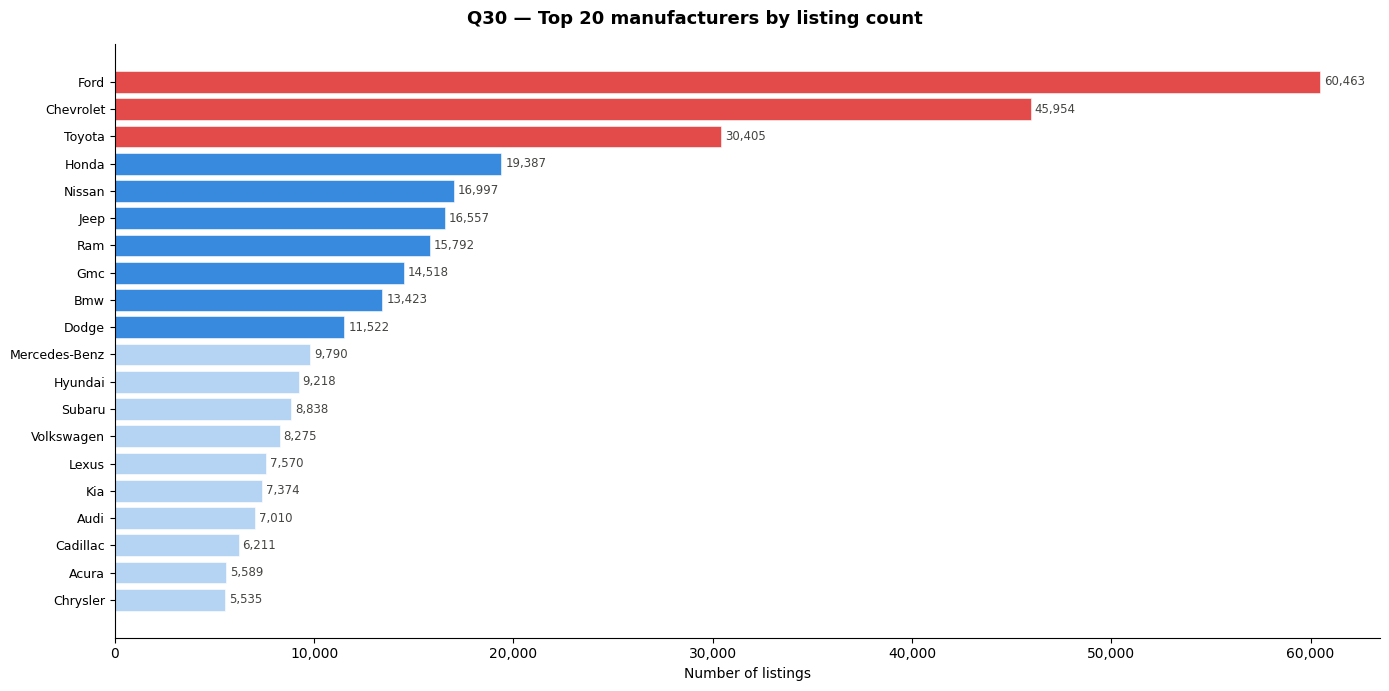


── Q30 Top 20 manufacturers by listing count ───────────
  Manufacturer           Listings   % of total
  ──────────────────────────────────────────────
  Ford                     60,463        16.9%
  Chevrolet                45,954        12.8%
  Toyota                   30,405         8.5%
  Honda                    19,387         5.4%
  Nissan                   16,997         4.7%
  Jeep                     16,557         4.6%
  Ram                      15,792         4.4%
  Gmc                      14,518         4.1%
  Bmw                      13,423         3.7%
  Dodge                    11,522         3.2%
  Mercedes-Benz             9,790         2.7%
  Hyundai                   9,218         2.6%
  Subaru                    8,838         2.5%
  Volkswagen                8,275         2.3%
  Lexus                     7,570         2.1%
  Kia                       7,374         2.1%
  Audi                      7,010         2.0%
  Cadillac                  6,211         1.7%


In [17]:
# ════════════════════════════════════════════════════════════════
# Q30 — Which manufacturers have the most listings?
# ════════════════════════════════════════════════════════════════
if 'df_mfr' not in dir(): raise NameError("Run shared cleaning block first")

top20 = (
    df_mfr['manufacturer']
    .value_counts()
    .head(20)
    .reset_index()
)
top20.columns = ['manufacturer', 'count']

fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle('Q30 — Top 20 manufacturers by listing count',
             fontsize=13, fontweight='bold')

colors = ['#E24B4A' if i < 3 else '#378ADD' if i < 10
          else '#B5D4F4' for i in range(len(top20))]

bars = ax.barh(
    top20['manufacturer'].str.title()[::-1],
    top20['count'][::-1],
    color=colors[::-1], edgecolor='white', linewidth=0.4
)
for bar, val in zip(bars, top20['count'][::-1]):
    ax.text(bar.get_width() + 200,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,}",
            va='center', ha='left', fontsize=8.5, color='#444441')

ax.set_xlabel('Number of listings')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.spines[['top','right']].set_visible(False)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('q30_listings_by_manufacturer.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Q30 Top 20 manufacturers by listing count ───────────")
print(f"  {'Manufacturer':<20} {'Listings':>10} {'% of total':>12}")
print("  " + "─" * 46)
total = len(df_mfr)
for _, row in top20.iterrows():
    pct = row['count'] / total * 100
    print(f"  {str(row['manufacturer']).title():<20} "
          f"{row['count']:>10,} "
          f"{pct:>11.1f}%")

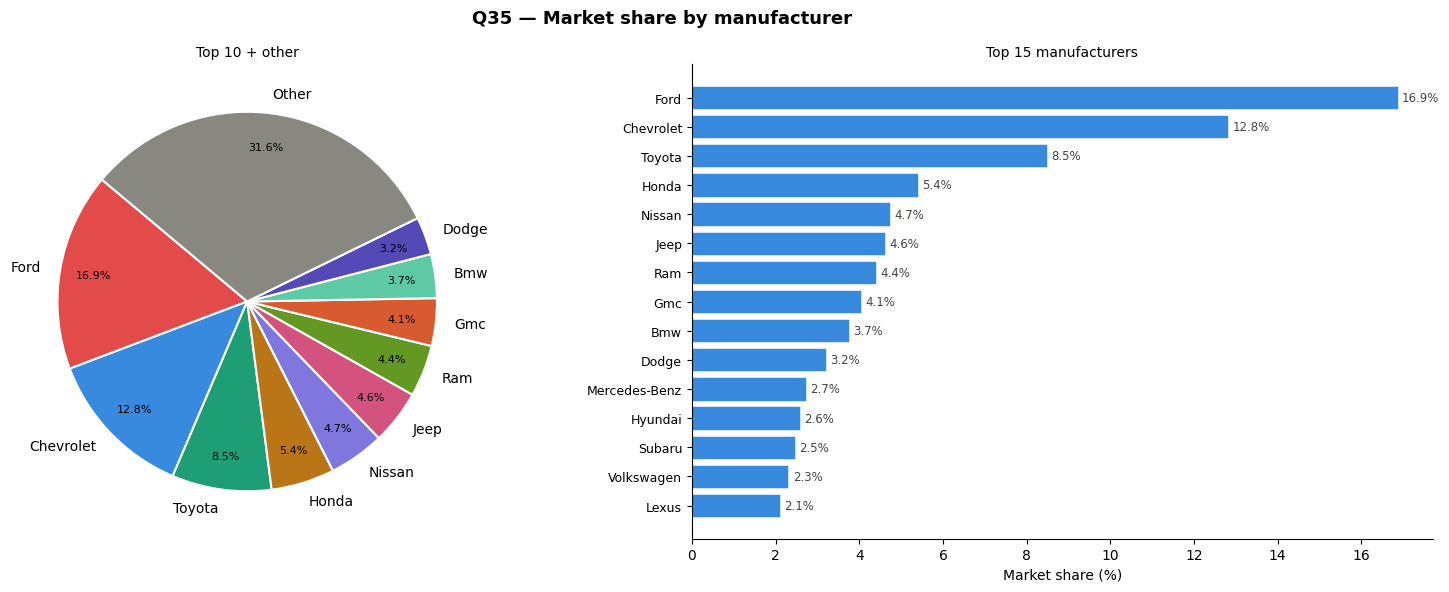


── Q35 Market share per manufacturer ───────────────────
  Manufacturer            Share %   Cumulative %
  ────────────────────────────────────────────────
  Ford                      16.9%          16.9%
  Chevrolet                 12.8%          29.7%
  Toyota                     8.5%          38.2%
  Honda                      5.4%          43.6%
  Nissan                     4.7%          48.3%
  Jeep                       4.6%          52.9%
  Ram                        4.4%          57.3%
  Gmc                        4.1%          61.4%
  Bmw                        3.7%          65.1%
  Dodge                      3.2%          68.4%
  Mercedes-Benz              2.7%          71.1%
  Hyundai                    2.6%          73.7%
  Subaru                     2.5%          76.1%
  Volkswagen                 2.3%          78.4%
  Lexus                      2.1%          80.5%
  Kia                        2.1%          82.6%
  Audi                       2.0%          84.6%
  Cadilla

In [18]:
# ════════════════════════════════════════════════════════════════
# Q35 — Market share (%) per manufacturer
# ════════════════════════════════════════════════════════════════
if 'df_mfr' not in dir(): raise NameError("Run shared cleaning block first")

mfr_share = (
    df_mfr['manufacturer']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)
mfr_share.columns = ['manufacturer', 'share_pct']

# top 10 + group rest as "other"
top10      = mfr_share.head(10).copy()
other_pct  = mfr_share.iloc[10:]['share_pct'].sum()
other_row  = pd.DataFrame([{'manufacturer': 'other', 'share_pct': other_pct}])
top10      = pd.concat([top10, other_row], ignore_index=True)

palette = [
    '#E24B4A','#378ADD','#1D9E75','#BA7517','#7F77DD',
    '#D4537E','#639922','#D85A30','#5DCAA5','#534AB7','#888780'
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Q35 — Market share by manufacturer',
             fontsize=13, fontweight='bold')

# LEFT: Pie chart
ax1 = axes[0]
wedges, texts, autotexts = ax1.pie(
    top10['share_pct'],
    labels=top10['manufacturer'].str.title(),
    autopct='%1.1f%%',
    colors=palette,
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for t in autotexts:
    t.set_fontsize(8)
ax1.set_title('Top 10 + other', fontsize=10)

# RIGHT: Horizontal bar — top 15
ax2 = axes[1]
top15 = mfr_share.head(15)
bars  = ax2.barh(
    top15['manufacturer'].str.title()[::-1],
    top15['share_pct'][::-1],
    color='#378ADD', edgecolor='white', linewidth=0.4
)
for bar, val in zip(bars, top15['share_pct'][::-1]):
    ax2.text(bar.get_width() + 0.1,
             bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}%",
             va='center', ha='left', fontsize=8.5, color='#444441')

ax2.set_xlabel('Market share (%)')
ax2.spines[['top','right']].set_visible(False)
ax2.tick_params(axis='y', labelsize=9)
ax2.set_title('Top 15 manufacturers', fontsize=10)

plt.tight_layout()
plt.savefig('q35_market_share.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Q35 Market share per manufacturer ───────────────────")
print(f"  {'Manufacturer':<20} {'Share %':>10} {'Cumulative %':>14}")
print("  " + "─" * 48)
cumulative = 0
for _, row in mfr_share.iterrows():
    cumulative += row['share_pct']
    print(f"  {str(row['manufacturer']).title():<20} "
          f"{row['share_pct']:>9.1f}% "
          f"{cumulative:>13.1f}%")

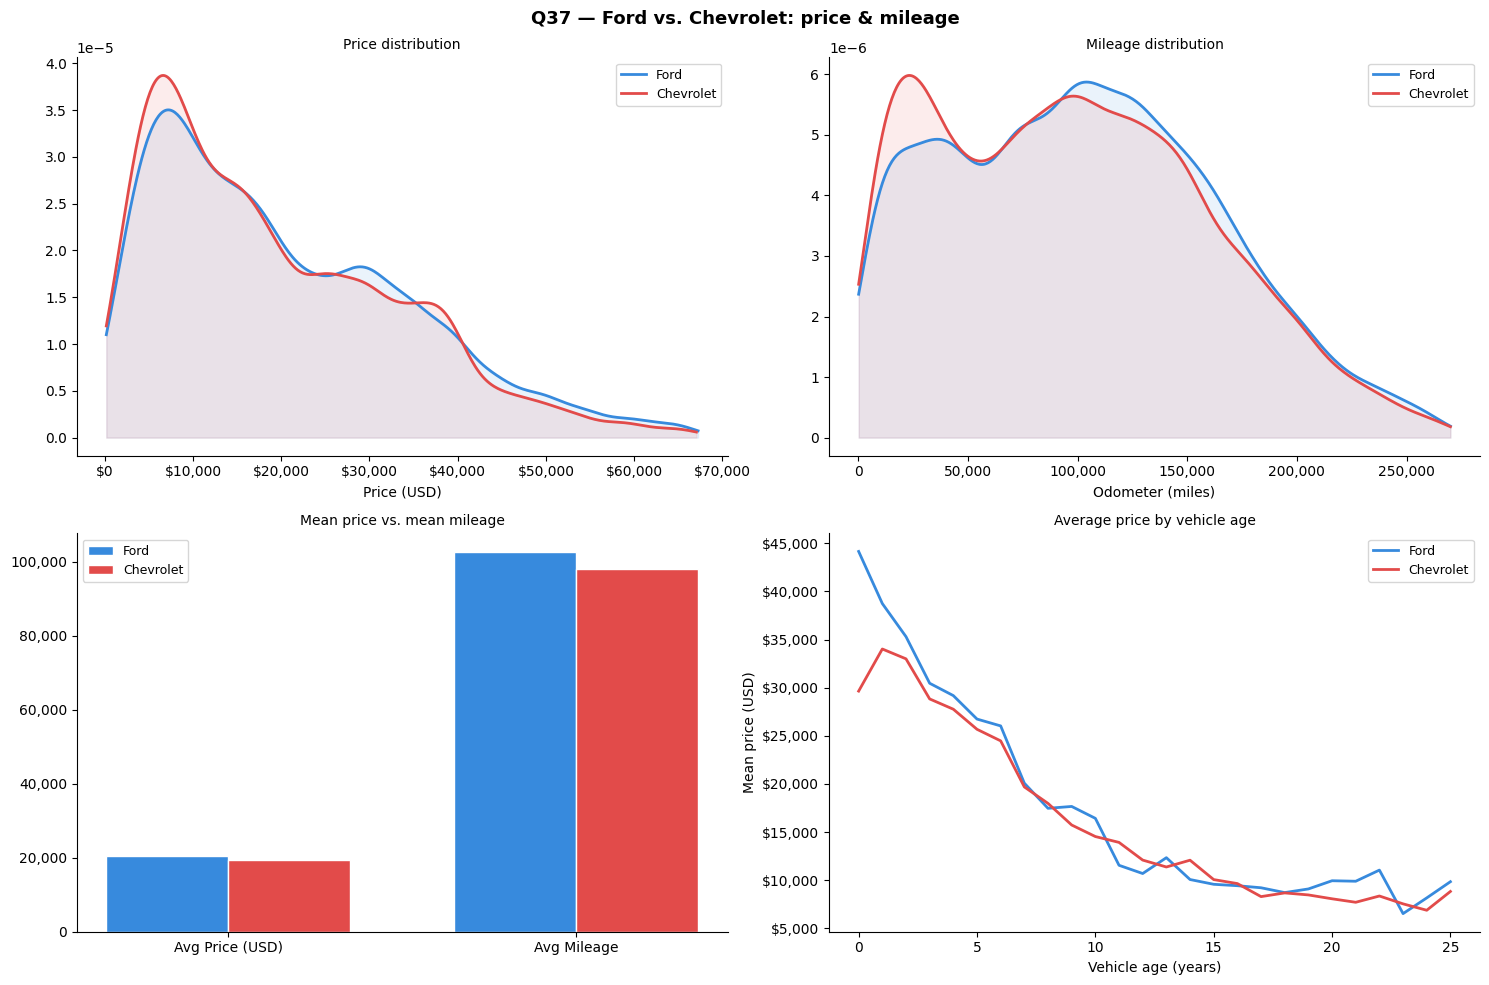


── Q37 Ford vs. Chevrolet summary ──────────────────────
  Metric                            Ford    Chevrolet
  ────────────────────────────────────────────────────
  Mean price                     $20,415      $19,304
  Median price                   $16,995      $15,990
  Mean mileage                102,507 mi    98,096 mi
  Median mileage              100,500 mi    95,240 mi
  Mean age                       9.2 yrs      9.6 yrs

  Cheaper on average : Ford


In [19]:
# ════════════════════════════════════════════════════════════════
# Q37 — Ford vs. Chevrolet: price and mileage comparison
# ════════════════════════════════════════════════════════════════
if 'df_mfr' not in dir(): raise NameError("Run shared cleaning block first")

brands    = ['ford', 'chevrolet']
df_q37    = df_mfr[df_mfr['manufacturer'].isin(brands)].copy()
colors_37 = {'ford': '#378ADD', 'chevrolet': '#E24B4A'}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Q37 — Ford vs. Chevrolet: price & mileage',
             fontsize=13, fontweight='bold')

# ── TOP LEFT: Price distribution KDE ─────────────────────────
from scipy.stats import gaussian_kde
ax1 = axes[0][0]
for brand in brands:
    data  = df_q37[df_q37['manufacturer'] == brand]['price'].dropna()
    kde   = gaussian_kde(data, bw_method=0.15)
    x     = np.linspace(data.min(), data.max(), 500)
    color = colors_37[brand]
    ax1.plot(x, kde(x), linewidth=2,
             label=brand.title(), color=color)
    ax1.fill_between(x, kde(x), alpha=0.1, color=color)
ax1.set_title('Price distribution', fontsize=10)
ax1.set_xlabel('Price (USD)')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax1.spines[['top','right']].set_visible(False)
ax1.legend(fontsize=9)

# ── TOP RIGHT: Mileage distribution KDE ──────────────────────
ax2 = axes[0][1]
for brand in brands:
    data  = df_q37[df_q37['manufacturer'] == brand]['odometer'].dropna()
    kde   = gaussian_kde(data, bw_method=0.15)
    x     = np.linspace(data.min(), data.max(), 500)
    color = colors_37[brand]
    ax2.plot(x, kde(x), linewidth=2,
             label=brand.title(), color=color)
    ax2.fill_between(x, kde(x), alpha=0.1, color=color)
ax2.set_title('Mileage distribution', fontsize=10)
ax2.set_xlabel('Odometer (miles)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax2.spines[['top','right']].set_visible(False)
ax2.legend(fontsize=9)

# ── BOTTOM LEFT: Mean price & mileage grouped bars ────────────
ax3 = axes[1][0]
metrics = ['price', 'odometer']
x       = np.arange(len(metrics))
width   = 0.35
stats37 = df_q37.groupby('manufacturer')[['price', 'odometer']].mean()

for i, brand in enumerate(brands):
    vals = [stats37.loc[brand, 'price'],
            stats37.loc[brand, 'odometer']]
    bars = ax3.bar(x + i * width - width/2, vals, width,
                   label=brand.title(),
                   color=colors_37[brand], edgecolor='white')

ax3.set_xticks(x)
ax3.set_xticklabels(['Avg Price (USD)', 'Avg Mileage'], fontsize=10)
ax3.set_title('Mean price vs. mean mileage', fontsize=10)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax3.spines[['top','right']].set_visible(False)
ax3.legend(fontsize=9)

# ── BOTTOM RIGHT: Price by vehicle age ───────────────────────
ax4 = axes[1][1]
for brand in brands:
    data = (
        df_q37[df_q37['manufacturer'] == brand]
        .groupby('vehicle_age')['price']
        .mean()
        .reset_index()
    )
    data = data[data['vehicle_age'] <= 25]
    ax4.plot(data['vehicle_age'], data['price'],
             linewidth=2, label=brand.title(),
             color=colors_37[brand])

ax4.set_title('Average price by vehicle age', fontsize=10)
ax4.set_xlabel('Vehicle age (years)')
ax4.set_ylabel('Mean price (USD)')
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax4.spines[['top','right']].set_visible(False)
ax4.legend(fontsize=9)

plt.tight_layout()
plt.savefig('q37_ford_vs_chevrolet.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Q37 Ford vs. Chevrolet summary ──────────────────────")
print(f"  {'Metric':<25} {'Ford':>12} {'Chevrolet':>12}")
print("  " + "─" * 52)
for brand in brands:
    d = df_q37[df_q37['manufacturer'] == brand]
for metric, label, fmt in [
    ('price',       'Mean price',    '${:,.0f}'),
    ('price',       'Median price',  '${:,.0f}'),
    ('odometer',    'Mean mileage',  '{:,.0f} mi'),
    ('odometer',    'Median mileage','{:,.0f} mi'),
    ('vehicle_age', 'Mean age',      '{:.1f} yrs'),
]:
    vals = {}
    for brand in brands:
        d = df_q37[df_q37['manufacturer'] == brand][metric]
        vals[brand] = d.mean() if 'Mean' in label else d.median()
    print(f"  {label:<25} "
          f"{fmt.format(vals['ford']):>12} "
          f"{fmt.format(vals['chevrolet']):>12}")

winner_price = 'Ford' if vals['ford'] < vals['chevrolet'] else 'Chevrolet'
print(f"\n  Cheaper on average : {winner_price}")

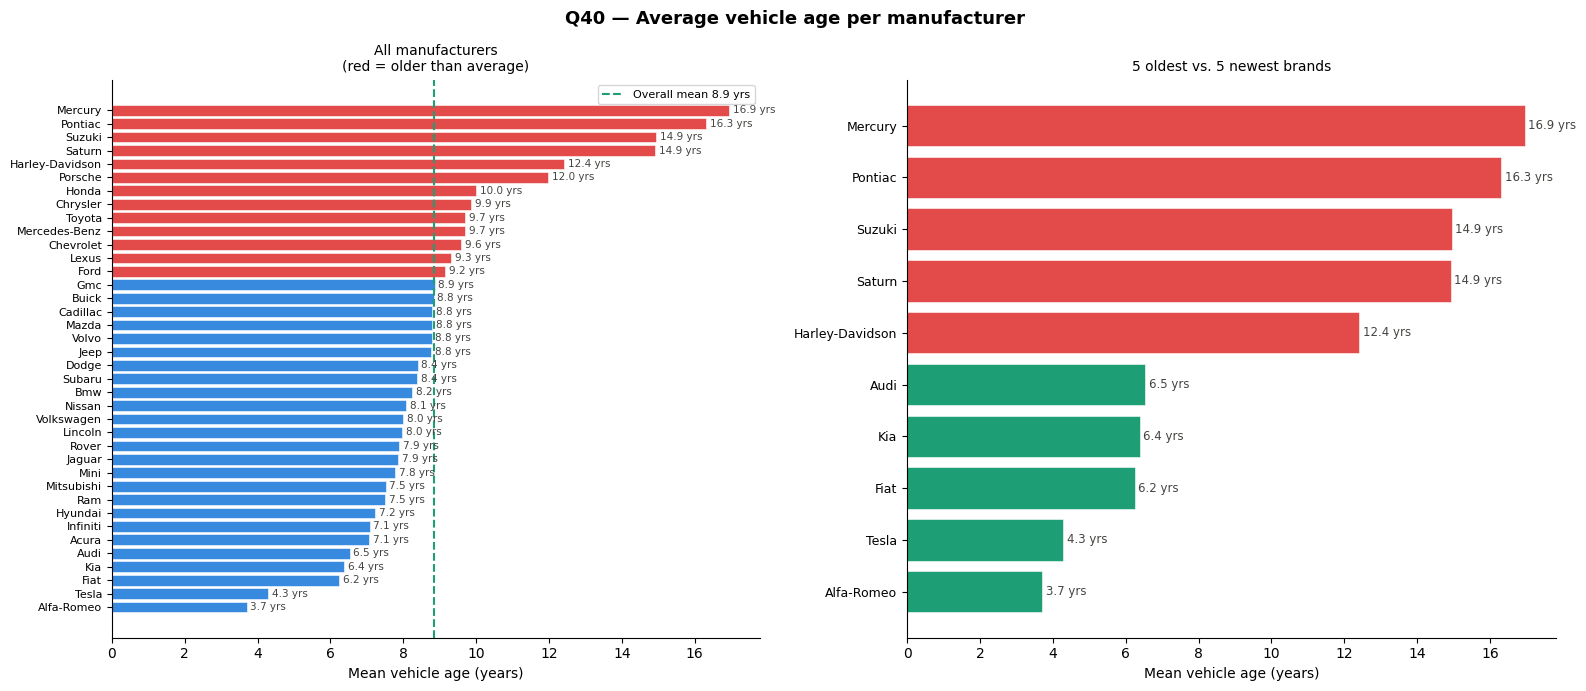


── Q40 Average vehicle age per manufacturer ─────────────
  Manufacturer           Mean age   Median age    Count
  ──────────────────────────────────────────────────────
  Mercury                   16.9y        16.0y      982
  Pontiac                   16.3y        15.0y    1,897
  Suzuki                    14.9y        13.0y      298
  Saturn                    14.9y        14.0y    1,057
  Harley-Davidson           12.4y        12.0y      136
  Porsche                   12.0y        10.0y    1,165
  Honda                     10.0y        10.0y   19,387
  Chrysler                   9.9y         9.0y    5,535
  Toyota                     9.7y         9.0y   30,405
  Mercedes-Benz              9.7y         8.0y    9,790
  Chevrolet                  9.6y         8.0y   45,954
  Lexus                      9.3y         8.0y    7,570
  Ford                       9.2y         8.0y   60,463
  Gmc                        8.9y         7.0y   14,518
  Buick                      8.8y         7.

In [20]:
# ════════════════════════════════════════════════════════════════
# Q40 — Average age of vehicles per manufacturer
# ════════════════════════════════════════════════════════════════
if 'df_mfr' not in dir(): raise NameError("Run shared cleaning block first")

age_stats = (
    df_mfr.groupby('manufacturer')['vehicle_age']
    .agg(mean_age='mean', median_age='median', count='count')
    .reset_index()
    .sort_values('mean_age', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Q40 — Average vehicle age per manufacturer',
             fontsize=13, fontweight='bold')

# LEFT: All manufacturers
ax1 = axes[0]
colors_age = ['#E24B4A' if v > age_stats['mean_age'].mean()
              else '#378ADD' for v in age_stats['mean_age']]
bars = ax1.barh(
    age_stats['manufacturer'].str.title()[::-1],
    age_stats['mean_age'][::-1],
    color=colors_age[::-1], edgecolor='white', linewidth=0.4
)
overall_age = df_mfr['vehicle_age'].mean()
ax1.axvline(overall_age, color='#1D9E75', linewidth=1.5,
            linestyle='--', label=f"Overall mean {overall_age:.1f} yrs")
for bar, val in zip(bars, age_stats['mean_age'][::-1]):
    ax1.text(bar.get_width() + 0.1,
             bar.get_y() + bar.get_height() / 2,
             f"{val:.1f} yrs",
             va='center', ha='left', fontsize=7.5, color='#444441')
ax1.set_xlabel('Mean vehicle age (years)')
ax1.set_title('All manufacturers\n(red = older than average)', fontsize=10)
ax1.spines[['top','right']].set_visible(False)
ax1.legend(fontsize=8)
ax1.tick_params(axis='y', labelsize=8)

# RIGHT: Top 10 oldest vs newest
ax2 = axes[1]
top5_old = age_stats.head(5)
top5_new = age_stats.tail(5)
combined  = pd.concat([top5_old, top5_new])
colors2   = ['#E24B4A'] * 5 + ['#1D9E75'] * 5

bars2 = ax2.barh(
    combined['manufacturer'].str.title()[::-1],
    combined['mean_age'][::-1],
    color=colors2[::-1], edgecolor='white', linewidth=0.4
)
for bar, val in zip(bars2, combined['mean_age'][::-1]):
    ax2.text(bar.get_width() + 0.1,
             bar.get_y() + bar.get_height() / 2,
             f"{val:.1f} yrs",
             va='center', ha='left', fontsize=8.5, color='#444441')
ax2.set_xlabel('Mean vehicle age (years)')
ax2.set_title('5 oldest vs. 5 newest brands', fontsize=10)
ax2.spines[['top','right']].set_visible(False)
ax2.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('q40_age_by_manufacturer.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Q40 Average vehicle age per manufacturer ─────────────")
print(f"  {'Manufacturer':<20} {'Mean age':>10} {'Median age':>12} {'Count':>8}")
print("  " + "─" * 54)
for _, row in age_stats.iterrows():
    print(f"  {str(row['manufacturer']).title():<20} "
          f"{row['mean_age']:>9.1f}y "
          f"{row['median_age']:>11.1f}y "
          f"{int(row['count']):>8,}")

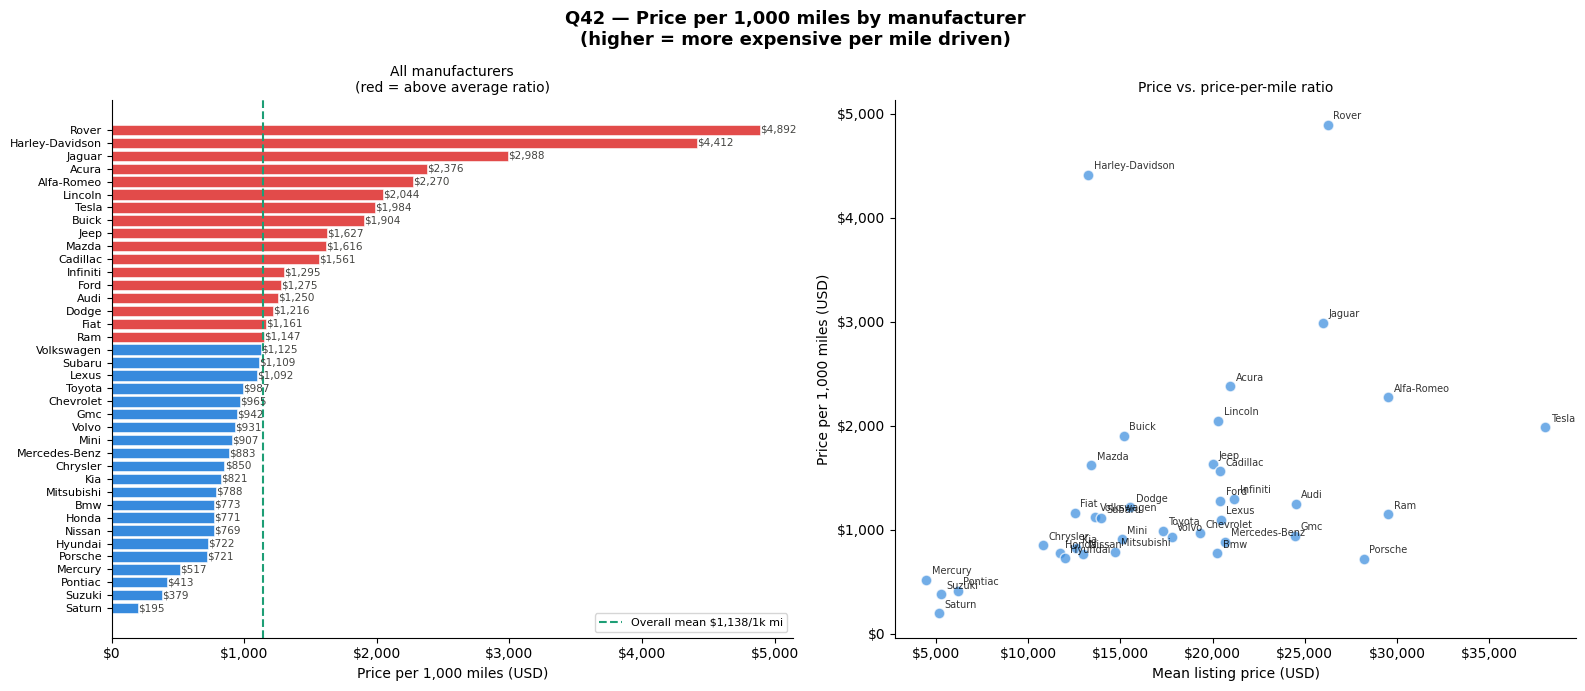


── Q42 Price per 1,000 miles by manufacturer ───────────
  Manufacturer           $/1k mi (mean)   $/1k mi (median)    Count
  ──────────────────────────────────────────────────────────────────
  Rover                $          4,892 $              376    1,845
  Harley-Davidson      $          4,412 $              485      136
  Jaguar               $          2,988 $              891    1,805
  Acura                $          2,376 $              382    5,589
  Alfa-Romeo           $          2,270 $            1,499      824
  Lincoln              $          2,044 $              317    3,889
  Tesla                $          1,984 $            1,490      806
  Buick                $          1,904 $              154    4,913
  Jeep                 $          1,627 $              218   16,557
  Mazda                $          1,616 $              111    5,017
  Cadillac             $          1,561 $              231    6,211
  Infiniti             $          1,295 $              36

In [21]:
# ════════════════════════════════════════════════════════════════
# Q42 — Price-to-mileage ratio per manufacturer
# ════════════════════════════════════════════════════════════════
if 'df_mfr' not in dir(): raise NameError("Run shared cleaning block first")

ratio_stats = (
    df_mfr.groupby('manufacturer')['price_per_mile']
    .agg(mean_ratio='mean', median_ratio='median', count='count')
    .reset_index()
    .sort_values('mean_ratio', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Q42 — Price per 1,000 miles by manufacturer\n'
             '(higher = more expensive per mile driven)',
             fontsize=13, fontweight='bold')

# LEFT: All manufacturers
ax1 = axes[0]
overall_ratio = df_mfr['price_per_mile'].mean()
colors_r = ['#E24B4A' if v > overall_ratio else '#378ADD'
            for v in ratio_stats['mean_ratio']]
bars = ax1.barh(
    ratio_stats['manufacturer'].str.title()[::-1],
    ratio_stats['mean_ratio'][::-1],
    color=colors_r[::-1], edgecolor='white', linewidth=0.4
)
ax1.axvline(overall_ratio, color='#1D9E75', linewidth=1.5,
            linestyle='--',
            label=f"Overall mean ${overall_ratio:,.0f}/1k mi")
for bar, val in zip(bars, ratio_stats['mean_ratio'][::-1]):
    ax1.text(bar.get_width() + 1,
             bar.get_y() + bar.get_height() / 2,
             f"${val:,.0f}",
             va='center', ha='left', fontsize=7.5, color='#444441')
ax1.set_xlabel('Price per 1,000 miles (USD)')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax1.set_title('All manufacturers\n(red = above average ratio)', fontsize=10)
ax1.spines[['top','right']].set_visible(False)
ax1.legend(fontsize=8)
ax1.tick_params(axis='y', labelsize=8)

# RIGHT: Mean ratio vs mean price scatter
ax2 = axes[1]
merged = ratio_stats.merge(
    df_mfr.groupby('manufacturer')['price'].mean().reset_index(),
    on='manufacturer'
)
ax2.scatter(merged['price'], merged['mean_ratio'],
            color='#378ADD', s=60, alpha=0.7, edgecolors='white')
for _, row in merged.iterrows():
    ax2.annotate(str(row['manufacturer']).title(),
                 (row['price'], row['mean_ratio']),
                 fontsize=7, alpha=0.8,
                 xytext=(4, 4), textcoords='offset points')
ax2.set_xlabel('Mean listing price (USD)')
ax2.set_ylabel('Price per 1,000 miles (USD)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax2.set_title('Price vs. price-per-mile ratio', fontsize=10)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('q42_price_per_mile.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Q42 Price per 1,000 miles by manufacturer ───────────")
print(f"  {'Manufacturer':<20} {'$/1k mi (mean)':>16} {'$/1k mi (median)':>18} {'Count':>8}")
print("  " + "─" * 66)
for _, row in ratio_stats.iterrows():
    print(f"  {str(row['manufacturer']).title():<20} "
          f"${row['mean_ratio']:>15,.0f} "
          f"${row['median_ratio']:>17,.0f} "
          f"{int(row['count']):>8,}")

print(f"\n  Best value (lowest $/mile) : "
      f"{str(ratio_stats.iloc[-1]['manufacturer']).title()} "
      f"— ${ratio_stats.iloc[-1]['mean_ratio']:,.0f}/1k mi")
print(f"  Worst value (highest $/mile): "
      f"{str(ratio_stats.iloc[0]['manufacturer']).title()} "
      f"— ${ratio_stats.iloc[0]['mean_ratio']:,.0f}/1k mi")

## **Vehicle age & year analysis**


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── SHARED CLEANING ───────────────────────────────────────────
df_age = df[['year', 'price', 'manufacturer', 'model',
             'type', 'odometer', 'condition']].copy()

df_age = df_age[df_age['price']    > 0]
df_age = df_age[df_age['odometer'] > 0]
df_age = df_age.dropna(subset=['year', 'manufacturer'])

# price outlier filter
p_low  = df_age['price'].quantile(0.01)
p_high = df_age['price'].quantile(0.99)
df_age = df_age[(df_age['price'] >= p_low) & (df_age['price'] <= p_high)]

# valid years only
df_age = df_age[df_age['year'].between(1900, 2021)]

# vehicle age at time of listing (dataset posted ~2021)
df_age['vehicle_age'] = 2021 - df_age['year']

# decade column
def get_decade(y):
    return f"{int(y // 10 * 10)}s"
df_age['decade'] = df_age['year'].apply(get_decade)

print(f"df_age ready — {len(df_age):,} rows")
print(f"Year range    : {int(df_age['year'].min())} → {int(df_age['year'].max())}")
print(f"Safety check  : 'df_age' in scope ✓")

df_age ready — 371,781 rows
Year range    : 1900 → 2021
Safety check  : 'df_age' in scope ✓


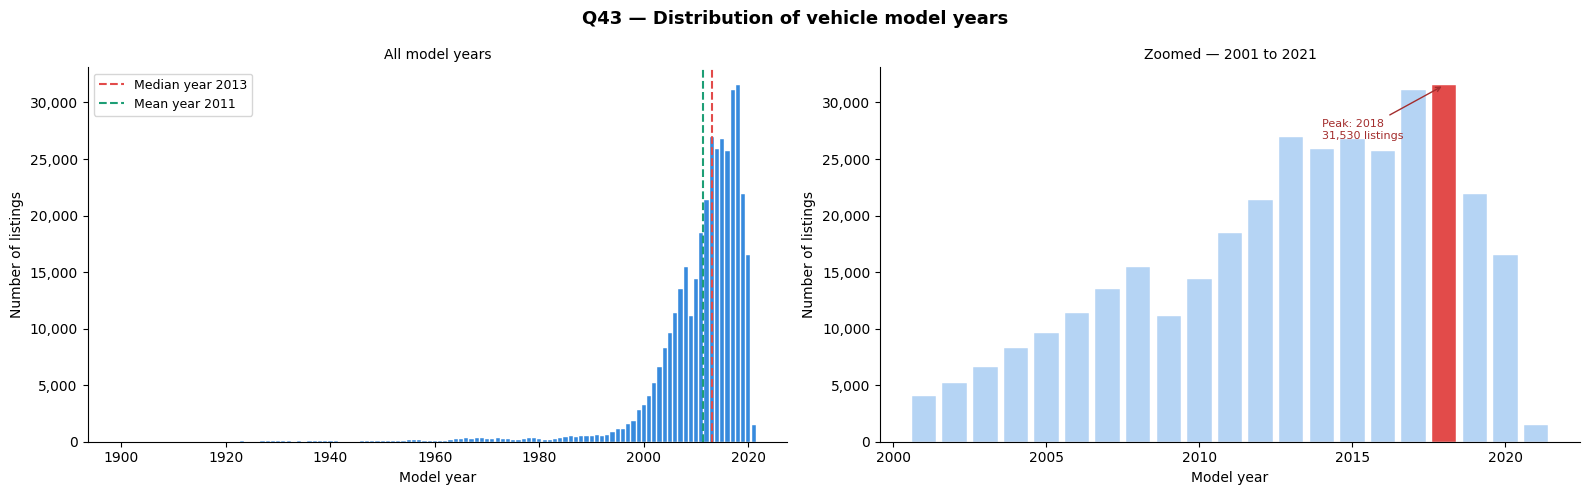


── Q43 Model year distribution summary ─────────────────
  Earliest year : 1900
  Latest year   : 2021
  Most common   : 2018
  Mean year     : 2011.2
  Median year   : 2013

── Top 10 most listed years ─────────────────────────────
  Year       Listings   % of total
  ──────────────────────────────────
  2018         31,530         8.5%
  2017         31,061         8.4%
  2013         26,942         7.2%
  2015         26,738         7.2%
  2014         25,857         7.0%
  2016         25,695         6.9%
  2019         21,906         5.9%
  2012         21,376         5.7%
  2011         18,421         5.0%
  2020         16,551         4.5%


In [23]:
# ════════════════════════════════════════════════════════════════
# Q43 — Distribution of vehicle model years
# ════════════════════════════════════════════════════════════════
if 'df_age' not in dir(): raise NameError("Run shared cleaning block first")

year_counts = df_age['year'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Q43 — Distribution of vehicle model years',
             fontsize=13, fontweight='bold')

# LEFT: Full distribution bar chart
ax1 = axes[0]
ax1.bar(year_counts.index, year_counts.values,
        color='#378ADD', edgecolor='white', linewidth=0.3, width=0.8)
ax1.axvline(df_age['year'].median(), color='#E24B4A', linewidth=1.5,
            linestyle='--',
            label=f"Median year {int(df_age['year'].median())}")
ax1.axvline(df_age['year'].mean(), color='#1D9E75', linewidth=1.5,
            linestyle='--',
            label=f"Mean year {df_age['year'].mean():.0f}")
ax1.set_title('All model years', fontsize=10)
ax1.set_xlabel('Model year')
ax1.set_ylabel('Number of listings')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax1.spines[['top','right']].set_visible(False)
ax1.legend(fontsize=9)

# RIGHT: Zoomed — last 20 years (2001–2021)
ax2 = axes[1]
recent = year_counts[year_counts.index >= 2001]
colors_r = ['#E24B4A' if y == recent.idxmax()
            else '#B5D4F4' for y in recent.index]
bars = ax2.bar(recent.index, recent.values,
               color=colors_r, edgecolor='white', linewidth=0.3, width=0.8)
ax2.set_title('Zoomed — 2001 to 2021', fontsize=10)
ax2.set_xlabel('Model year')
ax2.set_ylabel('Number of listings')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax2.spines[['top','right']].set_visible(False)

# annotate peak year
peak_year = recent.idxmax()
peak_val  = recent.max()
ax2.annotate(f"Peak: {peak_year}\n{peak_val:,} listings",
             xy=(peak_year, peak_val),
             xytext=(peak_year - 4, peak_val * 0.85),
             fontsize=8, color='#A32D2D',
             arrowprops=dict(arrowstyle='->', color='#A32D2D'))

plt.tight_layout()
plt.savefig('q43_year_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Q43 Model year distribution summary ─────────────────")
print(f"  Earliest year : {int(df_age['year'].min())}")
print(f"  Latest year   : {int(df_age['year'].max())}")
print(f"  Most common   : {int(df_age['year'].mode()[0])}")
print(f"  Mean year     : {df_age['year'].mean():.1f}")
print(f"  Median year   : {int(df_age['year'].median())}")
print(f"\n── Top 10 most listed years ─────────────────────────────")
print(f"  {'Year':<8} {'Listings':>10} {'% of total':>12}")
print("  " + "─" * 34)
for year, cnt in year_counts.sort_values(ascending=False).head(10).items():
    print(f"  {int(year):<8} {cnt:>10,} {cnt/len(df_age)*100:>11.1f}%")

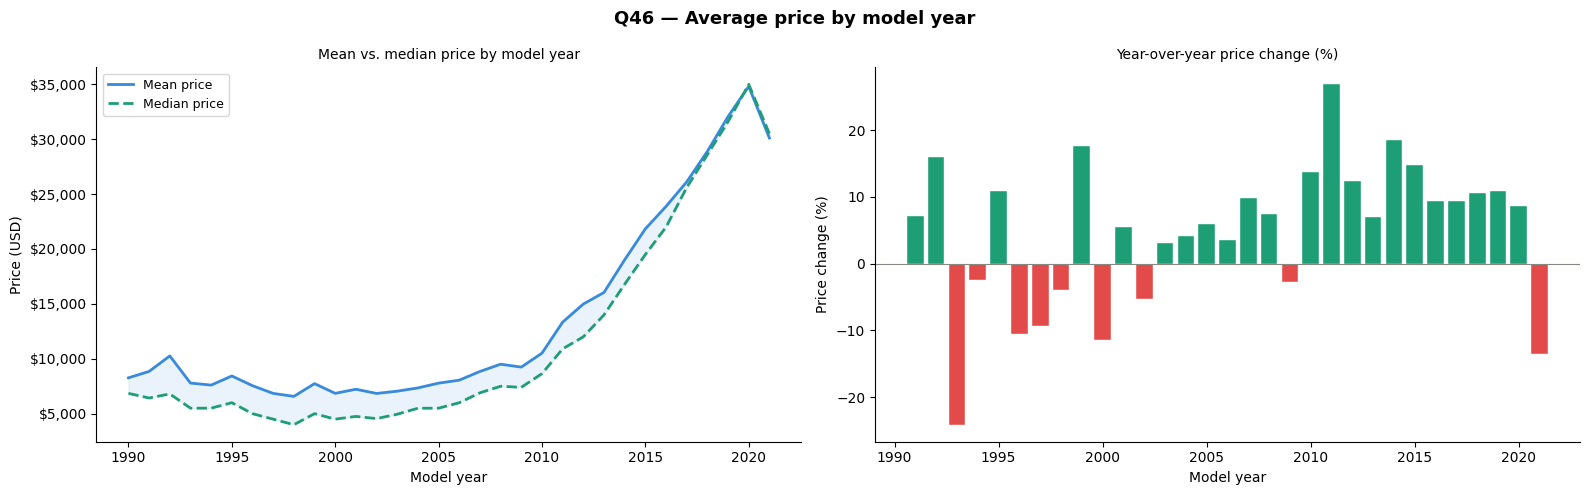


── Q46 Average price by model year (2010 onwards) ──────
  Year       Mean price   Median price   YoY change    Count
  ──────────────────────────────────────────────────────────
  2010     $     10,512 $        8,643       +13.8%   14,408
  2011     $     13,334 $       10,900       +26.9%   18,421
  2012     $     14,983 $       12,000       +12.4%   21,376
  2013     $     16,039 $       13,995        +7.0%   26,942
  2014     $     19,012 $       16,788       +18.5%   25,857
  2015     $     21,830 $       19,495       +14.8%   26,738
  2016     $     23,874 $       21,990        +9.4%   25,695
  2017     $     26,108 $       25,590        +9.4%   31,061
  2018     $     28,889 $       28,590       +10.7%   31,530
  2019     $     32,053 $       31,590       +11.0%   21,906
  2020     $     34,805 $       34,990        +8.6%   16,551
  2021     $     30,105 $       30,500       -13.5%    1,489


In [24]:
# ════════════════════════════════════════════════════════════════
# Q46 — How does average price change year over year?
# ════════════════════════════════════════════════════════════════
if 'df_age' not in dir(): raise NameError("Run shared cleaning block first")

year_price = (
    df_age[df_age['year'] >= 1990]
    .groupby('year')['price']
    .agg(mean='mean', median='median', count='count')
    .reset_index()
)
year_price = year_price[year_price['count'] >= 50]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Q46 — Average price by model year',
             fontsize=13, fontweight='bold')

# LEFT: Mean & median price over years
ax1 = axes[0]
ax1.plot(year_price['year'], year_price['mean'],
         color='#378ADD', linewidth=2, label='Mean price')
ax1.plot(year_price['year'], year_price['median'],
         color='#1D9E75', linewidth=2,
         linestyle='--', label='Median price')
ax1.fill_between(year_price['year'],
                 year_price['mean'], year_price['median'],
                 alpha=0.1, color='#378ADD')
ax1.set_title('Mean vs. median price by model year', fontsize=10)
ax1.set_xlabel('Model year')
ax1.set_ylabel('Price (USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax1.spines[['top','right']].set_visible(False)
ax1.legend(fontsize=9)

# RIGHT: Year-over-year price change %
ax2 = axes[1]
year_price['yoy_change'] = year_price['mean'].pct_change() * 100
colors_yoy = ['#1D9E75' if v >= 0 else '#E24B4A'
              for v in year_price['yoy_change']]
ax2.bar(year_price['year'], year_price['yoy_change'],
        color=colors_yoy, edgecolor='white', linewidth=0.3, width=0.8)
ax2.axhline(0, color='#888780', linewidth=0.8)
ax2.set_title('Year-over-year price change (%)', fontsize=10)
ax2.set_xlabel('Model year')
ax2.set_ylabel('Price change (%)')
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('q46_price_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Q46 Average price by model year (2010 onwards) ──────")
print(f"  {'Year':<8} {'Mean price':>12} {'Median price':>14} "
      f"{'YoY change':>12} {'Count':>8}")
print("  " + "─" * 58)
for _, row in year_price[year_price['year'] >= 2010].iterrows():
    yoy = f"{row['yoy_change']:+.1f}%" if not np.isnan(row['yoy_change']) else "  —"
    print(f"  {int(row['year']):<8} "
          f"${row['mean']:>11,.0f} "
          f"${row['median']:>13,.0f} "
          f"{yoy:>12} "
          f"{int(row['count']):>8,}")

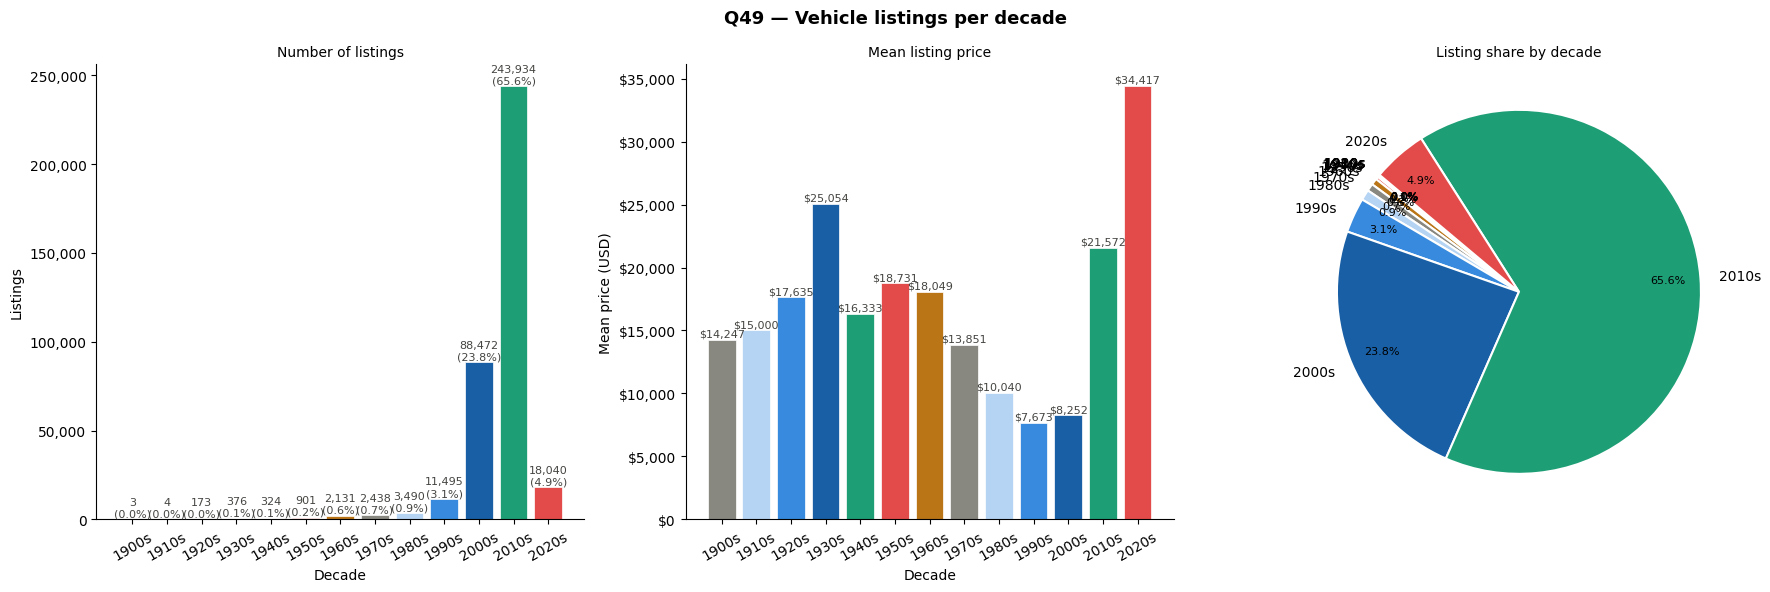


── Q49 Listings per decade ──────────────────────────────
  Decade          Count        %   Mean price   Mean age
  ────────────────────────────────────────────────────────
  1900s               3     0.0% $     14,247     119.3y
  1910s               4     0.0% $     15,000     105.5y
  1920s             173     0.0% $     17,635      94.3y
  1930s             376     0.1% $     25,054      86.9y
  1940s             324     0.1% $     16,333      75.8y
  1950s             901     0.2% $     18,731      66.3y
  1960s           2,131     0.6% $     18,049      55.2y
  1970s           2,438     0.7% $     13,851      46.5y
  1980s           3,490     0.9% $     10,040      35.6y
  1990s          11,495     3.1% $      7,673      24.9y
  2000s          88,472    23.8% $      8,252      15.3y
  2010s         243,934    65.6% $     21,572       6.1y
  2020s          18,040     4.9% $     34,417       0.9y


In [25]:
# ════════════════════════════════════════════════════════════════
# Q49 — Listings per decade
# ════════════════════════════════════════════════════════════════
if 'df_age' not in dir(): raise NameError("Run shared cleaning block first")

decade_stats = (
    df_age.groupby('decade')
    .agg(
        count        = ('year',  'count'),
        mean_price   = ('price', 'mean'),
        median_price = ('price', 'median'),
        mean_age     = ('vehicle_age', 'mean')
    )
    .reset_index()
    .sort_values('decade')
)
decade_stats['pct'] = decade_stats['count'] / decade_stats['count'].sum() * 100

palette_d = [
    '#888780','#B5D4F4','#378ADD','#185FA5',
    '#1D9E75','#E24B4A','#BA7517'
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Q49 — Vehicle listings per decade',
             fontsize=13, fontweight='bold')

# LEFT: Listings count bar
ax1 = axes[0]
bars = ax1.bar(decade_stats['decade'], decade_stats['count'],
               color=palette_d[:len(decade_stats)],
               edgecolor='white', linewidth=0.5)
for bar, val, pct in zip(bars, decade_stats['count'], decade_stats['pct']):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 500,
             f"{val:,}\n({pct:.1f}%)",
             ha='center', va='bottom', fontsize=8, color='#444441')
ax1.set_title('Number of listings', fontsize=10)
ax1.set_xlabel('Decade')
ax1.set_ylabel('Listings')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax1.spines[['top','right']].set_visible(False)
ax1.tick_params(axis='x', rotation=30)

# MIDDLE: Mean price per decade
ax2 = axes[1]
bars2 = ax2.bar(decade_stats['decade'], decade_stats['mean_price'],
                color=palette_d[:len(decade_stats)],
                edgecolor='white', linewidth=0.5)
for bar, val in zip(bars2, decade_stats['mean_price']):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 100,
             f"${val:,.0f}",
             ha='center', va='bottom', fontsize=8, color='#444441')
ax2.set_title('Mean listing price', fontsize=10)
ax2.set_xlabel('Decade')
ax2.set_ylabel('Mean price (USD)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax2.spines[['top','right']].set_visible(False)
ax2.tick_params(axis='x', rotation=30)

# RIGHT: Pie chart of listing share
ax3 = axes[2]
wedges, texts, autotexts = ax3.pie(
    decade_stats['count'],
    labels=decade_stats['decade'],
    autopct='%1.1f%%',
    colors=palette_d[:len(decade_stats)],
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    pctdistance=0.82
)
for t in autotexts:
    t.set_fontsize(8)
ax3.set_title('Listing share by decade', fontsize=10)

plt.tight_layout()
plt.savefig('q49_listings_by_decade.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Q49 Listings per decade ──────────────────────────────")
print(f"  {'Decade':<10} {'Count':>10} {'%':>8} "
      f"{'Mean price':>12} {'Mean age':>10}")
print("  " + "─" * 56)
for _, row in decade_stats.iterrows():
    print(f"  {row['decade']:<10} "
          f"{int(row['count']):>10,} "
          f"{row['pct']:>7.1f}% "
          f"${row['mean_price']:>11,.0f} "
          f"{row['mean_age']:>9.1f}y")

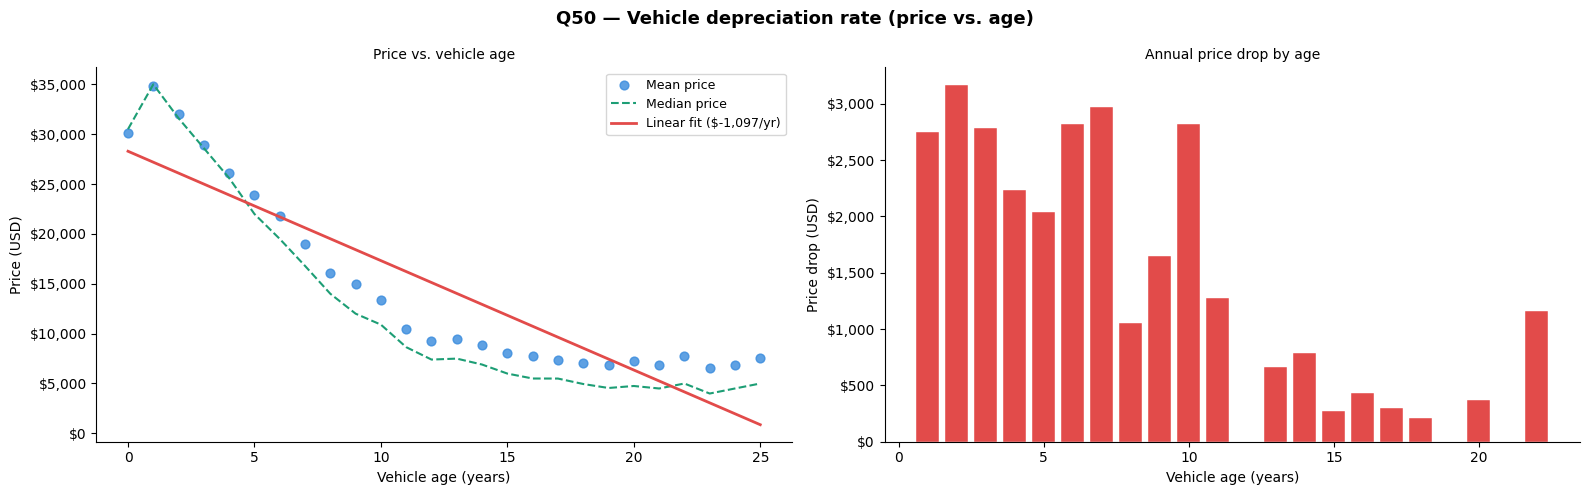


── Q50 Depreciation summary ─────────────────────────────
  Linear depreciation   : $1,097 per year
  Exponential rate      : -7.0% per year
  Value at age 0        : $30,105
  Value at age 10       : $13,334
  Total loss (0→10 yrs) : $16,771 (55.7%)

── Price by age (every 5 years) ─────────────────────────
     Age   Mean price   Drop from prev    Count
  ──────────────────────────────────────────────
       0 $     30,105                —    1,489
       5 $     23,874           $6,231   25,695
      10 $     13,334          $10,540   18,421
      15 $      8,051           $5,283   11,421
      20 $      7,224             $827    4,033
      25 $      7,548            $-324    1,164


In [26]:
# ════════════════════════════════════════════════════════════════
# Q50 — Depreciation rate: average price loss per year
# ════════════════════════════════════════════════════════════════
if 'df_age' not in dir(): raise NameError("Run shared cleaning block first")

depr = (
    df_age[df_age['vehicle_age'].between(0, 25)]
    .groupby('vehicle_age')['price']
    .agg(mean='mean', median='median', count='count')
    .reset_index()
)
depr = depr[depr['count'] >= 50]

# fit linear depreciation
z    = np.polyfit(depr['vehicle_age'], depr['mean'], 1)
p    = np.poly1d(z)
x_ln = np.linspace(depr['vehicle_age'].min(),
                   depr['vehicle_age'].max(), 100)

# fit exponential depreciation
log_price = np.log(depr['mean'])
z_exp     = np.polyfit(depr['vehicle_age'], log_price, 1)
exp_rate  = (np.exp(z_exp[0]) - 1) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Q50 — Vehicle depreciation rate (price vs. age)',
             fontsize=13, fontweight='bold')

# LEFT: Mean & median price vs age + linear trend
ax1 = axes[0]
ax1.scatter(depr['vehicle_age'], depr['mean'],
            color='#378ADD', s=40, alpha=0.8, label='Mean price')
ax1.plot(depr['vehicle_age'], depr['median'],
         color='#1D9E75', linewidth=1.5,
         linestyle='--', label='Median price')
ax1.plot(x_ln, p(x_ln), color='#E24B4A', linewidth=2,
         label=f"Linear fit (${z[0]:,.0f}/yr)")
ax1.set_title('Price vs. vehicle age', fontsize=10)
ax1.set_xlabel('Vehicle age (years)')
ax1.set_ylabel('Price (USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax1.spines[['top','right']].set_visible(False)
ax1.legend(fontsize=9)

# RIGHT: Annual price drop bar chart
ax2 = axes[1]
depr['price_drop'] = depr['mean'].diff(-1)
depr_drop = depr[depr['price_drop'] > 0].copy()
ax2.bar(depr_drop['vehicle_age'], depr_drop['price_drop'],
        color='#E24B4A', edgecolor='white', linewidth=0.3, width=0.8)
ax2.set_title('Annual price drop by age', fontsize=10)
ax2.set_xlabel('Vehicle age (years)')
ax2.set_ylabel('Price drop (USD)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('q50_depreciation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Q50 Depreciation summary ─────────────────────────────")
print(f"  Linear depreciation   : ${abs(z[0]):,.0f} per year")
print(f"  Exponential rate      : {exp_rate:.1f}% per year")
new_price = depr[depr['vehicle_age'] == depr['vehicle_age'].min()]['mean'].values[0]
old_price = depr[depr['vehicle_age'] == 10]['mean'].values[0]
total_loss = new_price - old_price
print(f"  Value at age 0        : ${new_price:,.0f}")
print(f"  Value at age 10       : ${old_price:,.0f}")
print(f"  Total loss (0→10 yrs) : ${total_loss:,.0f} ({total_loss/new_price*100:.1f}%)")
print(f"\n── Price by age (every 5 years) ─────────────────────────")
print(f"  {'Age':>6} {'Mean price':>12} {'Drop from prev':>16} {'Count':>8}")
print("  " + "─" * 46)
prev = None
for _, row in depr[depr['vehicle_age'] % 5 == 0].iterrows():
    drop = f"${prev - row['mean']:,.0f}" if prev else "—"
    print(f"  {int(row['vehicle_age']):>6} "
          f"${row['mean']:>11,.0f} "
          f"{drop:>16} "
          f"{int(row['count']):>8,}")
    prev = row['mean']

  Unique types found : 14
  Types              : ['offroad', 'convertible', 'bus', 'coupe', 'UNKNOWN', 'mini-van', 'truck', 'van', 'sedan', 'wagon', 'SUV', 'pickup', 'hatchback', 'other']


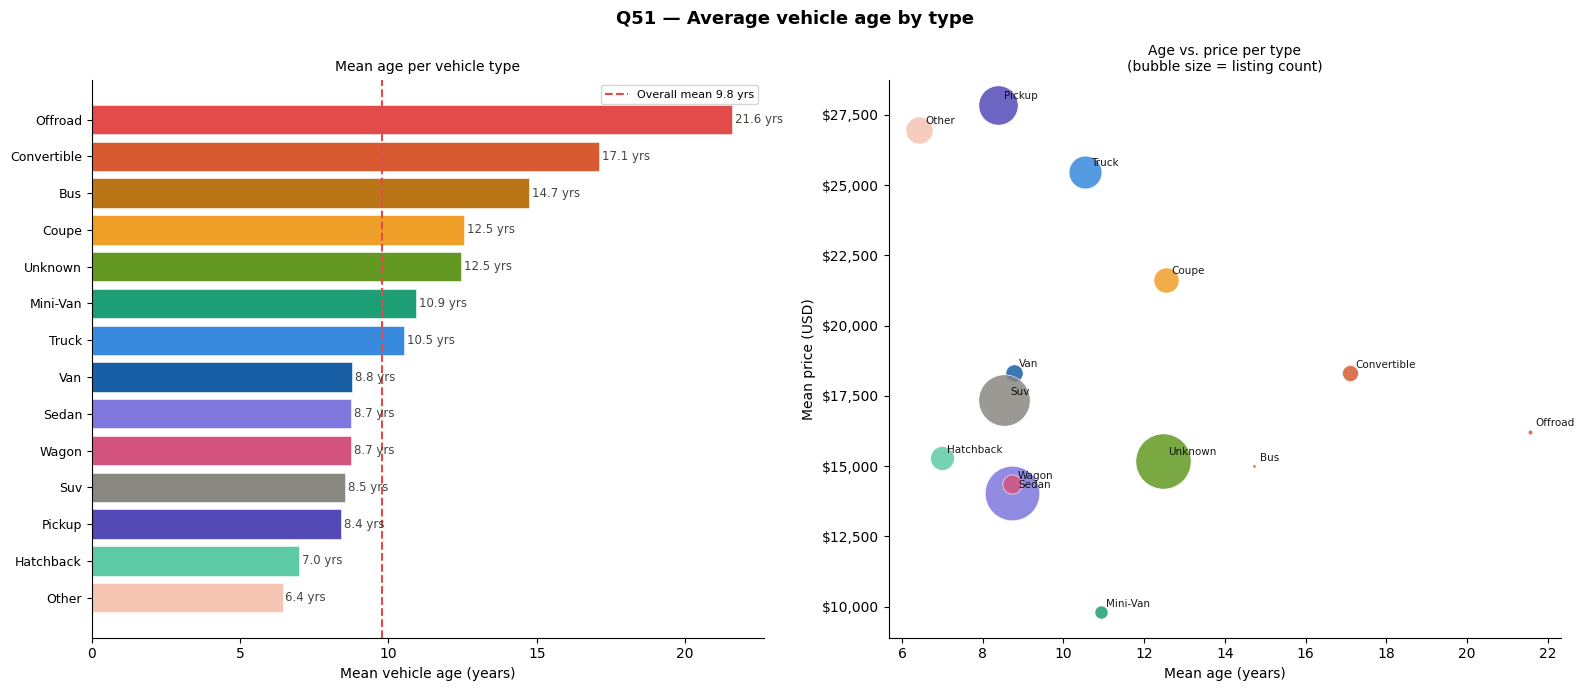


── Q51 Average age by vehicle type ─────────────────────
  Type              Mean age   Median age   Mean price    Count
  ──────────────────────────────────────────────────────────────
  Offroad              21.6y        18.0y $     16,212      563
  Convertible          17.1y        14.0y $     18,309    6,620
  Bus                  14.7y        10.0y $     14,996      298
  Coupe                12.5y         8.0y $     21,632   16,368
  Unknown              12.5y        10.0y $     15,187   78,953
  Mini-Van             10.9y        11.0y $      9,795    4,429
  Truck                10.5y         8.0y $     25,476   27,926
  Van                   8.8y         7.0y $     18,314    7,714
  Sedan                 8.7y         7.0y $     14,027   77,040
  Wagon                 8.7y         8.0y $     14,348    9,641
  Suv                   8.5y         7.0y $     17,340   68,402
  Pickup                8.4y         6.0y $     27,853   40,000
  Hatchback             7.0y         6.0y $  

In [27]:
# ════════════════════════════════════════════════════════════════
# Q51 — Which vehicle types have the oldest average age?
# ════════════════════════════════════════════════════════════════
if 'df_age' not in dir(): raise NameError("Run shared cleaning block first")

type_age = (
    df_age.dropna(subset=['type'])
    .groupby('type')
    .agg(
        mean_age     = ('vehicle_age', 'mean'),
        median_age   = ('vehicle_age', 'median'),
        mean_price   = ('price',       'mean'),
        count        = ('year',        'count')
    )
    .reset_index()
    .sort_values('mean_age', ascending=False)
)
type_age = type_age[type_age['count'] >= 100]

# ── FIX: dynamic palette that adapts to however many types exist ──
base_palette = [
    '#E24B4A','#D85A30','#BA7517','#EF9F27','#639922',
    '#1D9E75','#378ADD','#185FA5','#7F77DD','#D4537E',
    '#888780','#534AB7','#5DCAA5','#F5C4B3','#9FE1CB',
    '#CECBF6','#F4C0D1','#C0DD97','#FAC775','#F7C1C1'
]
n         = len(type_age)
palette_t = (base_palette * (n // len(base_palette) + 1))[:n]

print(f"  Unique types found : {n}")
print(f"  Types              : {type_age['type'].tolist()}")

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, n * 0.5)))
fig.suptitle('Q51 — Average vehicle age by type',
             fontsize=13, fontweight='bold')

# LEFT: Mean age bar chart
ax1 = axes[0]
overall_type_age = df_age['vehicle_age'].mean()
colors_t = palette_t

bars = ax1.barh(
    type_age['type'].str.title()[::-1],
    type_age['mean_age'][::-1],
    color=colors_t[::-1], edgecolor='white', linewidth=0.4
)
ax1.axvline(overall_type_age, color='#E24B4A', linewidth=1.5,
            linestyle='--',
            label=f"Overall mean {overall_type_age:.1f} yrs")
for bar, val in zip(bars, type_age['mean_age'][::-1]):
    ax1.text(bar.get_width() + 0.1,
             bar.get_y() + bar.get_height() / 2,
             f"{val:.1f} yrs",
             va='center', ha='left', fontsize=8.5, color='#444441')
ax1.set_xlabel('Mean vehicle age (years)')
ax1.set_title('Mean age per vehicle type', fontsize=10)
ax1.spines[['top','right']].set_visible(False)
ax1.legend(fontsize=8)
ax1.tick_params(axis='y', labelsize=9)

# RIGHT: Age vs price scatter per type
ax2 = axes[1]
for i, (_, row) in enumerate(type_age.iterrows()):
    ax2.scatter(row['mean_age'], row['mean_price'],
                s=row['count'] / 50,
                color=palette_t[i],
                alpha=0.85, edgecolors='white', linewidth=0.5)
    ax2.annotate(str(row['type']).title(),
                 (row['mean_age'], row['mean_price']),
                 fontsize=7.5, alpha=0.9,
                 xytext=(4, 4), textcoords='offset points')

ax2.set_xlabel('Mean age (years)')
ax2.set_ylabel('Mean price (USD)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax2.set_title('Age vs. price per type\n(bubble size = listing count)',
              fontsize=10)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('q51_age_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Q51 Average age by vehicle type ─────────────────────")
print(f"  {'Type':<15} {'Mean age':>10} {'Median age':>12} "
      f"{'Mean price':>12} {'Count':>8}")
print("  " + "─" * 62)
for _, row in type_age.iterrows():
    print(f"  {str(row['type']).title():<15} "
          f"{row['mean_age']:>9.1f}y "
          f"{row['median_age']:>11.1f}y "
          f"${row['mean_price']:>11,.0f} "
          f"{int(row['count']):>8,}")

## **Condition analysis**


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── SHARED CLEANING ───────────────────────────────────────────
df_cond = df[['condition', 'price', 'odometer', 'manufacturer',
              'type', 'year']].copy()

df_cond = df_cond[df_cond['price']    > 0]
df_cond = df_cond[df_cond['odometer'] > 0]

# price outlier filter
p_low  = df_cond['price'].quantile(0.01)
p_high = df_cond['price'].quantile(0.99)
df_cond = df_cond[(df_cond['price'] >= p_low) & (df_cond['price'] <= p_high)]

# odometer outlier filter
o_low  = df_cond['odometer'].quantile(0.01)
o_high = df_cond['odometer'].quantile(0.99)
df_cond = df_cond[(df_cond['odometer'] >= o_low) & (df_cond['odometer'] <= o_high)]

# vehicle age
df_cond['vehicle_age'] = 2021 - df_cond['year']
df_cond = df_cond[df_cond['vehicle_age'].between(0, 40)]

# ⚡ is_carvana — use original df with regex=False (much faster)
carvana_mask = df['description'].str.contains(
    'carvana', case=False, na=False, regex=False)
df_cond['is_carvana'] = carvana_mask.reindex(df_cond.index).fillna(False)

# condition order — from best to worst
COND_ORDER = ['new', 'like new', 'excellent', 'good', 'fair', 'salvage']

# ⚡ normalize condition — use category dtype before filtering
UNKNOWN_VALUES = ['unknown', 'UNKNOWN', '', 'nan', 'None', 'other']
# # df_cond['condition'] = df_cond['condition'].str.strip().str.lower()
# # df_cond['condition'] = df_cond['condition'].replace(UNKNOWN_VALUES, np.nan)

# known vs unknown
df_cond_known = df_cond[df_cond['condition'].isin(COND_ORDER)].copy()
df_cond_known['condition'] = pd.Categorical(
    df_cond_known['condition'], categories=COND_ORDER, ordered=True)

# condition color map
COND_COLORS = {
    'new'      : '#1D9E75',
    'like new' : '#5DCAA5',
    'excellent': '#378ADD',
    'good'     : '#BA7517',
    'fair'     : '#E24B4A',
    'salvage'  : '#A32D2D'
}

print(f"df_cond ready       — {len(df_cond):,} rows")
print(f"df_cond_known ready — {len(df_cond_known):,} rows")
print(f"Carvana listings    — {df_cond['is_carvana'].sum():,}")
print(f"Safety check        : 'df_cond' in scope ✓")


df_cond ready       — 358,505 rows
df_cond_known ready — 221,313 rows
Carvana listings    — 61,558
Safety check        : 'df_cond' in scope ✓


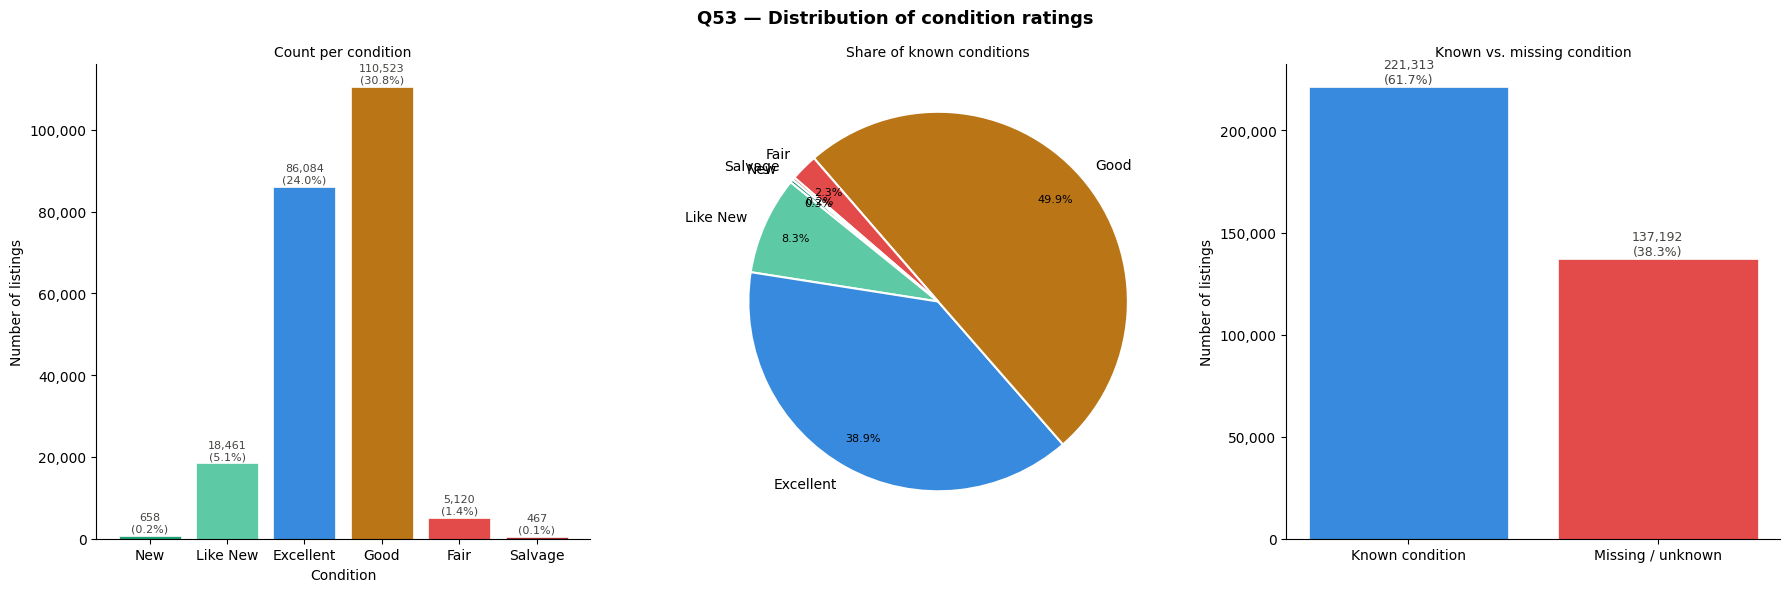


── Q53 Condition distribution ───────────────────────────
  Total listings      : 358,505
  Known condition     : 221,313 (61.7%)
  Missing / unknown   : 137,192 (38.3%)

  Condition         Count   % of total
  ──────────────────────────────────────
  New                 658         0.2%
  Like New         18,461         5.1%
  Excellent        86,084        24.0%
  Good            110,523        30.8%
  Fair              5,120         1.4%
  Salvage             467         0.1%


In [29]:
# ════════════════════════════════════════════════════════════════
# Q53 — Distribution of condition ratings
# ════════════════════════════════════════════════════════════════
if 'df_cond' not in dir(): raise NameError("Run shared cleaning block first")

total      = len(df_cond)
known      = len(df_cond_known)
missing    = total - known
missing_pct = missing / total * 100

cond_counts = (
    df_cond_known['condition']
    .value_counts()
    .reindex(COND_ORDER)
    .fillna(0)
    .astype(int)
    .reset_index()
)
cond_counts.columns = ['condition', 'count']
cond_counts['pct']  = cond_counts['count'] / total * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Q53 — Distribution of condition ratings',
             fontsize=13, fontweight='bold')

# LEFT: Bar chart
ax1 = axes[0]
colors_c = [COND_COLORS[c] for c in cond_counts['condition']]
bars = ax1.bar(
    cond_counts['condition'].str.title(),
    cond_counts['count'],
    color=colors_c, edgecolor='white', linewidth=0.5
)
for bar, val, pct in zip(bars, cond_counts['count'], cond_counts['pct']):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 500,
             f"{val:,}\n({pct:.1f}%)",
             ha='center', va='bottom', fontsize=8, color='#444441')
ax1.set_title('Count per condition', fontsize=10)
ax1.set_xlabel('Condition')
ax1.set_ylabel('Number of listings')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax1.spines[['top','right']].set_visible(False)

# MIDDLE: Pie chart (known conditions only)
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    cond_counts['count'],
    labels=cond_counts['condition'].str.title(),
    autopct='%1.1f%%',
    colors=colors_c,
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    pctdistance=0.82
)
for t in autotexts:
    t.set_fontsize(8)
ax2.set_title('Share of known conditions', fontsize=10)

# RIGHT: Known vs unknown
ax3 = axes[2]
known_unknown = pd.DataFrame({
    'category': ['Known condition', 'Missing / unknown'],
    'count'   : [known, missing],
    'pct'     : [known/total*100, missing_pct]
})
bars3 = ax3.bar(
    known_unknown['category'],
    known_unknown['count'],
    color=['#378ADD', '#E24B4A'],
    edgecolor='white', linewidth=0.5
)
for bar, val, pct in zip(bars3, known_unknown['count'], known_unknown['pct']):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 500,
             f"{val:,}\n({pct:.1f}%)",
             ha='center', va='bottom', fontsize=9, color='#444441')
ax3.set_title('Known vs. missing condition', fontsize=10)
ax3.set_ylabel('Number of listings')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax3.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('q53_condition_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Q53 Condition distribution ───────────────────────────")
print(f"  Total listings      : {total:,}")
print(f"  Known condition     : {known:,} ({known/total*100:.1f}%)")
print(f"  Missing / unknown   : {missing:,} ({missing_pct:.1f}%)")
print(f"\n  {'Condition':<12} {'Count':>10} {'% of total':>12}")
print("  " + "─" * 38)
for _, row in cond_counts.iterrows():
    print(f"  {str(row['condition']).title():<12} "
          f"{int(row['count']):>10,} "
          f"{row['pct']:>11.1f}%")

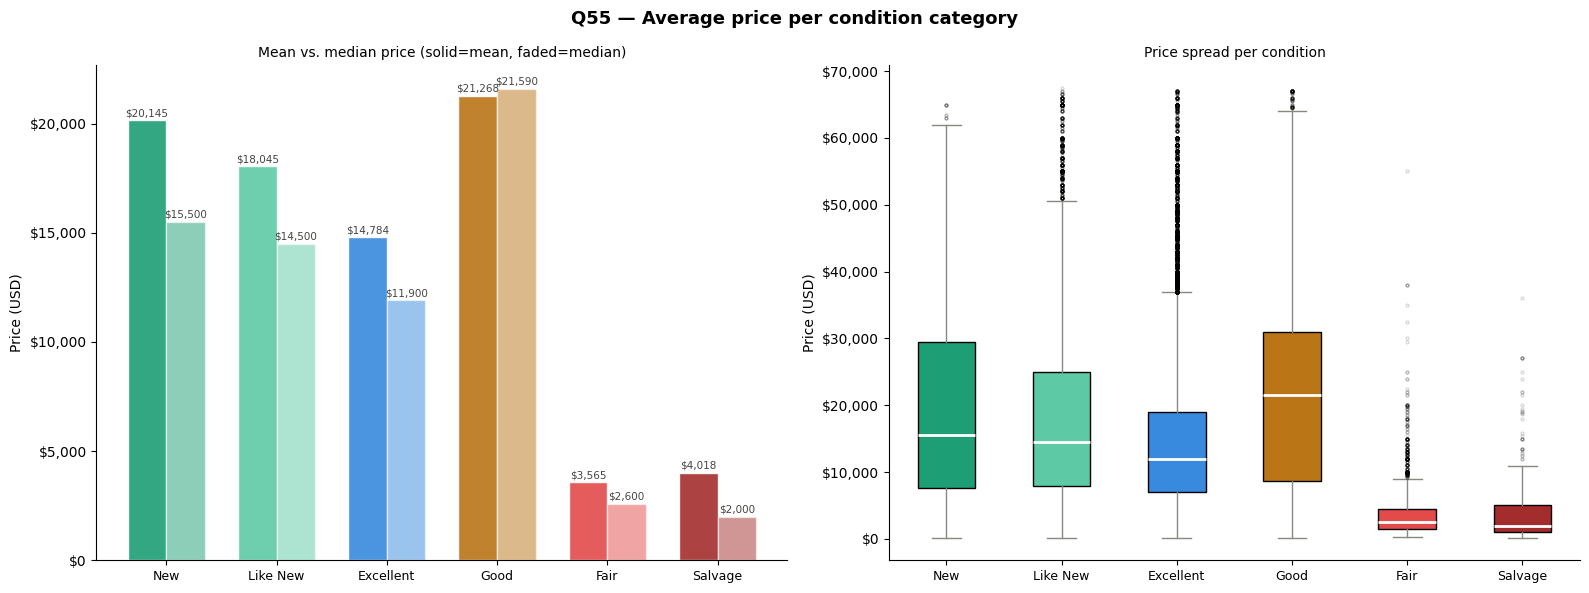


── Q55 Price per condition ──────────────────────────────
  Condition          Mean     Median        Std        Q25        Q75    Count
  ──────────────────────────────────────────────────────────────────────────
  New          $   20,145 $   15,500 $   16,393 $    7,612 $   29,500      658
  Like New     $   18,045 $   14,500 $   13,519 $    7,900 $   24,999   18,461
  Excellent    $   14,784 $   11,900 $   10,901 $    6,995 $   18,995   86,084
  Good         $   21,268 $   21,590 $   12,910 $    8,688 $   31,000  110,523
  Fair         $    3,565 $    2,600 $    3,305 $    1,500 $    4,500    5,120
  Salvage      $    4,018 $    2,000 $    5,024 $    1,000 $    5,000      467


In [30]:
# ════════════════════════════════════════════════════════════════
# Q55 — Average price per condition category
# ════════════════════════════════════════════════════════════════
if 'df_cond' not in dir(): raise NameError("Run shared cleaning block first")

price_cond = (
    df_cond_known.groupby('condition', observed=True)['price']
    .agg(mean='mean', median='median',
         std='std', count='count',
         q25=lambda x: x.quantile(0.25),
         q75=lambda x: x.quantile(0.75))
    .reindex(COND_ORDER)
    .dropna()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Q55 — Average price per condition category',
             fontsize=13, fontweight='bold')

colors_55 = [COND_COLORS[c] for c in price_cond['condition']]

# LEFT: Mean vs median grouped bars
ax1 = axes[0]
x     = np.arange(len(price_cond))
width = 0.35
ax1.bar(x - width/2, price_cond['mean'],   width,
        color=colors_55, label='Mean',   edgecolor='white', alpha=0.9)
ax1.bar(x + width/2, price_cond['median'], width,
        color=colors_55, label='Median', edgecolor='white', alpha=0.5)

for i, (mean, median) in enumerate(
        zip(price_cond['mean'], price_cond['median'])):
    ax1.text(i - width/2, mean + 100, f"${mean:,.0f}",
             ha='center', va='bottom', fontsize=7.5, color='#444441')
    ax1.text(i + width/2, median + 100, f"${median:,.0f}",
             ha='center', va='bottom', fontsize=7.5, color='#444441')

ax1.set_xticks(x)
ax1.set_xticklabels(price_cond['condition'].str.title(), fontsize=9)
ax1.set_ylabel('Price (USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax1.set_title('Mean vs. median price (solid=mean, faded=median)', fontsize=10)
ax1.spines[['top','right']].set_visible(False)

# RIGHT: Boxplot per condition
ax2 = axes[1]
box_data = [df_cond_known[df_cond_known['condition'] == c]['price'].values
            for c in COND_ORDER
            if c in df_cond_known['condition'].values]
box_labels = [c.title() for c in COND_ORDER
              if c in df_cond_known['condition'].values]
box_colors = [COND_COLORS[c] for c in COND_ORDER
              if c in df_cond_known['condition'].values]

bp = ax2.boxplot(
    box_data, patch_artist=True, widths=0.5,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#888780'),
    capprops=dict(color='#888780'),
    flierprops=dict(marker='o', alpha=0.15, markersize=2, color='#888780')
)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
ax2.set_xticklabels(box_labels, fontsize=9)
ax2.set_ylabel('Price (USD)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax2.set_title('Price spread per condition', fontsize=10)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('q55_price_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Q55 Price per condition ──────────────────────────────")
print(f"  {'Condition':<12} {'Mean':>10} {'Median':>10} "
      f"{'Std':>10} {'Q25':>10} {'Q75':>10} {'Count':>8}")
print("  " + "─" * 74)
for _, row in price_cond.iterrows():
    print(f"  {str(row['condition']).title():<12} "
          f"${row['mean']:>9,.0f} "
          f"${row['median']:>9,.0f} "
          f"${row['std']:>9,.0f} "
          f"${row['q25']:>9,.0f} "
          f"${row['q75']:>9,.0f} "
          f"{int(row['count']):>8,}")

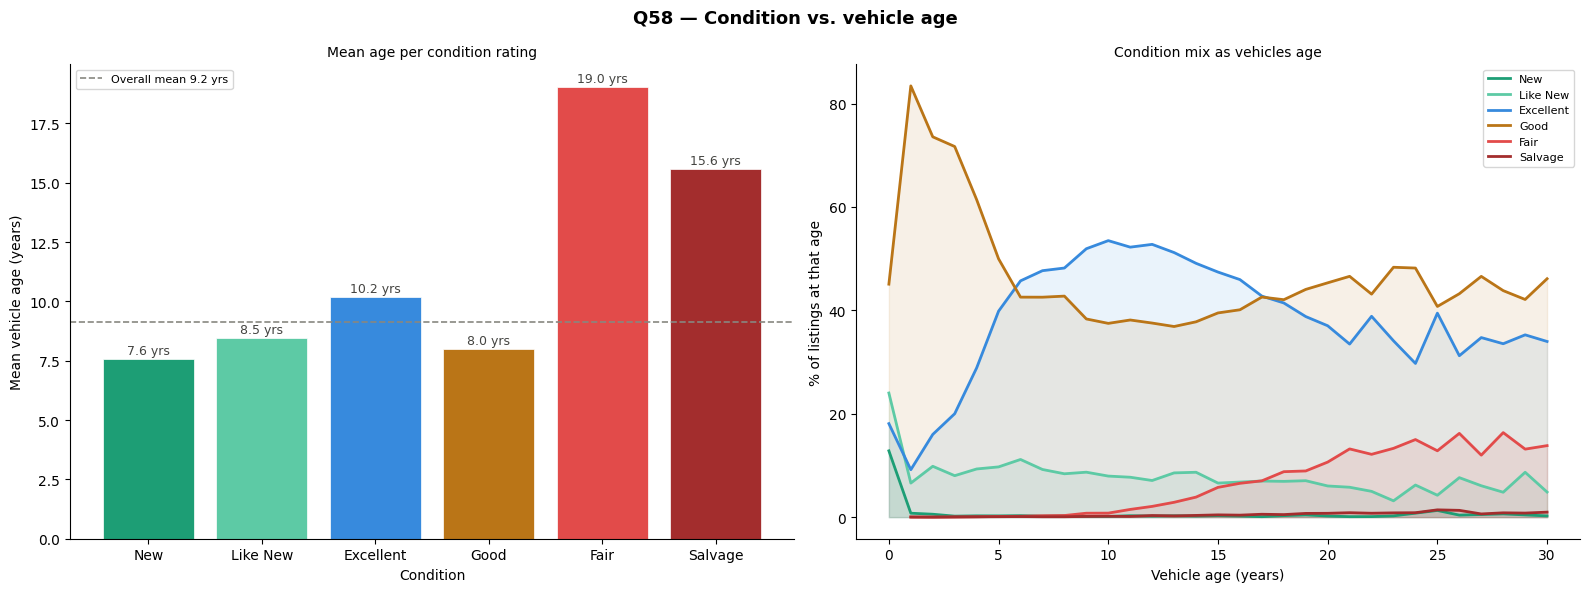


── Q58 Mean vehicle age per condition ───────────────────
  Condition      Mean age   Median age    Count
  ──────────────────────────────────────────────
  New                7.6y         6.0y      658
  Like New           8.5y         7.0y   18,461
  Excellent         10.2y         9.0y   86,084
  Good               8.0y         6.0y  110,523
  Fair              19.0y        18.0y    5,120
  Salvage           15.6y        15.0y      467


In [31]:
# ════════════════════════════════════════════════════════════════
# Q58 — How does condition correlate with vehicle age?
# ════════════════════════════════════════════════════════════════
if 'df_cond' not in dir(): raise NameError("Run shared cleaning block first")

age_cond = (
    df_cond_known.groupby('condition', observed=True)['vehicle_age']
    .agg(mean='mean', median='median', count='count')
    .reindex(COND_ORDER)
    .dropna()
    .reset_index()
)

# age distribution per condition
age_trend = (
    df_cond_known[df_cond_known['vehicle_age'] <= 30]
    .groupby(['vehicle_age', 'condition'], observed=True)
    .size()
    .reset_index(name='count')
)
age_trend['pct'] = age_trend.groupby('vehicle_age')['count'].transform(
    lambda x: x / x.sum() * 100)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Q58 — Condition vs. vehicle age',
             fontsize=13, fontweight='bold')

# LEFT: Mean age per condition bar
ax1 = axes[0]
colors_58 = [COND_COLORS[c] for c in age_cond['condition']]
bars = ax1.bar(
    age_cond['condition'].str.title(),
    age_cond['mean'],
    color=colors_58, edgecolor='white', linewidth=0.5
)
for bar, val in zip(bars, age_cond['mean']):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.1,
             f"{val:.1f} yrs",
             ha='center', va='bottom', fontsize=9, color='#444441')
overall_age = df_cond_known['vehicle_age'].mean()
ax1.axhline(overall_age, color='#888780', linewidth=1.2,
            linestyle='--', label=f"Overall mean {overall_age:.1f} yrs")
ax1.set_xlabel('Condition')
ax1.set_ylabel('Mean vehicle age (years)')
ax1.set_title('Mean age per condition rating', fontsize=10)
ax1.spines[['top','right']].set_visible(False)
ax1.legend(fontsize=8)

# RIGHT: Stacked area — condition mix by age
ax2 = axes[1]
for cond in COND_ORDER:
    data = age_trend[age_trend['condition'] == cond]
    if data.empty:
        continue
    ax2.plot(data['vehicle_age'], data['pct'],
             color=COND_COLORS[cond], linewidth=2,
             label=cond.title())
    ax2.fill_between(data['vehicle_age'], data['pct'],
                     alpha=0.1, color=COND_COLORS[cond])

ax2.set_xlabel('Vehicle age (years)')
ax2.set_ylabel('% of listings at that age')
ax2.set_title('Condition mix as vehicles age', fontsize=10)
ax2.spines[['top','right']].set_visible(False)
ax2.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('q58_condition_vs_age.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Q58 Mean vehicle age per condition ───────────────────")
print(f"  {'Condition':<12} {'Mean age':>10} {'Median age':>12} {'Count':>8}")
print("  " + "─" * 46)
for _, row in age_cond.iterrows():
    print(f"  {str(row['condition']).title():<12} "
          f"{row['mean']:>9.1f}y "
          f"{row['median']:>11.1f}y "
          f"{int(row['count']):>8,}")

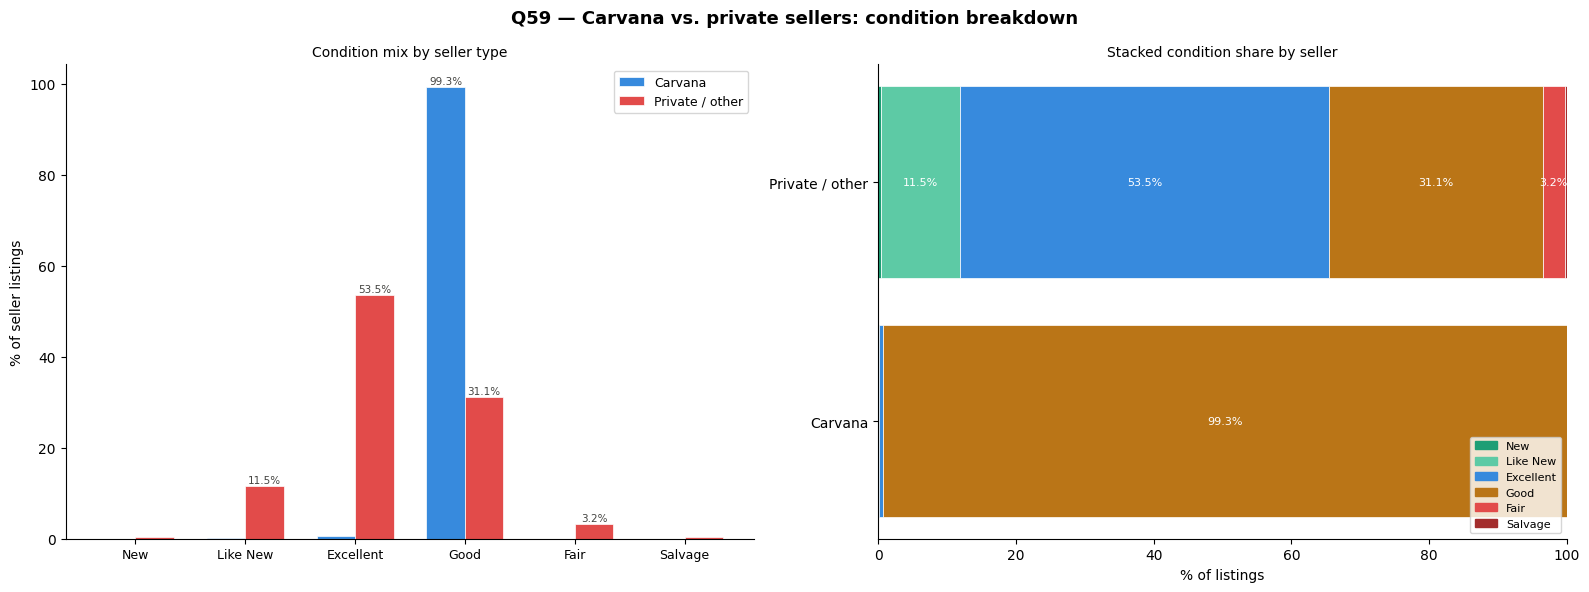


── Q59 Condition breakdown by seller type ───────────────
  Condition       Carvana %    Private %
  ────────────────────────────────────────
  New                  0.0%         0.4%
  Like New             0.1%        11.5%
  Excellent            0.6%        53.5%
  Good                99.3%        31.1%
  Fair                 0.0%         3.2%
  Salvage              0.0%         0.3%

  Carvana 'good' listings  : 99.3%
  Private 'good' listings  : 31.1%
  Difference               : +68.2%
  More 'good' ratings from : Carvana


In [32]:
# ════════════════════════════════════════════════════════════════
# Q59 — Carvana vs. private sellers: condition breakdown
# ════════════════════════════════════════════════════════════════
if 'df_cond' not in dir(): raise NameError("Run shared cleaning block first")

df_q59 = df_cond_known.copy()

# ⚡ convert condition back to plain string to avoid Categorical issues
df_q59['condition']   = df_q59['condition'].astype(str)
df_q59['seller_type'] = df_q59['is_carvana'].map(
    {True: 'Carvana', False: 'Private / other'})

cond_seller = (
    df_q59.groupby(['seller_type', 'condition'])
    .size()
    .reset_index(name='count')
)
cond_seller['pct'] = cond_seller.groupby('seller_type')['count'].transform(
    lambda x: x / x.sum() * 100)

# ⚡ pivot once — avoid repeated filtering inside loops
pivot = cond_seller.pivot(
    index='seller_type', columns='condition', values='pct'
).fillna(0)

# only keep known conditions that exist in data
cond_order_present = [c for c in COND_ORDER if c in pivot.columns]

sellers     = ['Carvana', 'Private / other']
seller_clrs = ['#378ADD', '#E24B4A']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Q59 — Carvana vs. private sellers: condition breakdown',
             fontsize=13, fontweight='bold')

# LEFT: Grouped bar
ax1 = axes[0]
x     = np.arange(len(cond_order_present))
width = 0.35

for i, (seller, color) in enumerate(zip(sellers, seller_clrs)):
    if seller not in pivot.index:
        continue
    vals = [pivot.loc[seller, c] if c in pivot.columns else 0
            for c in cond_order_present]
    bars = ax1.bar(x + i * width - width/2, vals, width,
                   label=seller, color=color,
                   edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        if val > 1:
            ax1.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.3,
                     f"{val:.1f}%",
                     ha='center', va='bottom',
                     fontsize=7.5, color='#444441')

ax1.set_xticks(x)
ax1.set_xticklabels([c.title() for c in cond_order_present], fontsize=9)
ax1.set_ylabel('% of seller listings')
ax1.set_title('Condition mix by seller type', fontsize=10)
ax1.spines[['top','right']].set_visible(False)
ax1.legend(fontsize=9)

# RIGHT: Horizontal stacked bar
ax2 = axes[1]
bottom_vals = {s: 0 for s in sellers}

for cond in cond_order_present:
    for i, seller in enumerate(sellers):
        if seller not in pivot.index:
            continue
        val = pivot.loc[seller, cond] if cond in pivot.columns else 0
        ax2.barh(seller, val, left=bottom_vals[seller],
                 color=COND_COLORS.get(cond, '#888780'),
                 edgecolor='white', linewidth=0.5,
                 label=cond.title() if i == 0 else '')
        if val > 3:
            ax2.text(bottom_vals[seller] + val / 2,
                     sellers.index(seller),
                     f"{val:.1f}%",
                     ha='center', va='center',
                     fontsize=8, color='white', fontweight='500')
        bottom_vals[seller] += val

ax2.set_xlabel('% of listings')
ax2.set_title('Stacked condition share by seller', fontsize=10)
ax2.spines[['top','right']].set_visible(False)
handles = [plt.Rectangle((0,0),1,1,
           color=COND_COLORS.get(c,'#888780'))
           for c in cond_order_present]
ax2.legend(handles, [c.title() for c in cond_order_present],
           fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('q59_carvana_vs_private.png', dpi=150, bbox_inches='tight')
plt.show()

# ── PRINT ─────────────────────────────────────────────────────
print("\n── Q59 Condition breakdown by seller type ───────────────")
print(f"  {'Condition':<12} {'Carvana %':>12} {'Private %':>12}")
print("  " + "─" * 40)
for cond in cond_order_present:
    c_val = pivot.loc['Carvana', cond] \
            if 'Carvana' in pivot.index and cond in pivot.columns else 0
    p_val = pivot.loc['Private / other', cond] \
            if 'Private / other' in pivot.index and cond in pivot.columns else 0
    print(f"  {cond.title():<12} {c_val:>11.1f}% {p_val:>11.1f}%")

if 'good' in pivot.columns:
    c_good = pivot.loc['Carvana', 'good'] \
             if 'Carvana' in pivot.index else 0
    p_good = pivot.loc['Private / other', 'good'] \
             if 'Private / other' in pivot.index else 0
    diff   = c_good - p_good
    print(f"\n  Carvana 'good' listings  : {c_good:.1f}%")
    print(f"  Private 'good' listings  : {p_good:.1f}%")
    print(f"  Difference               : {diff:+.1f}%")
    winner = 'Carvana' if diff > 0 else 'Private sellers'
    print(f"  More 'good' ratings from : {winner}")

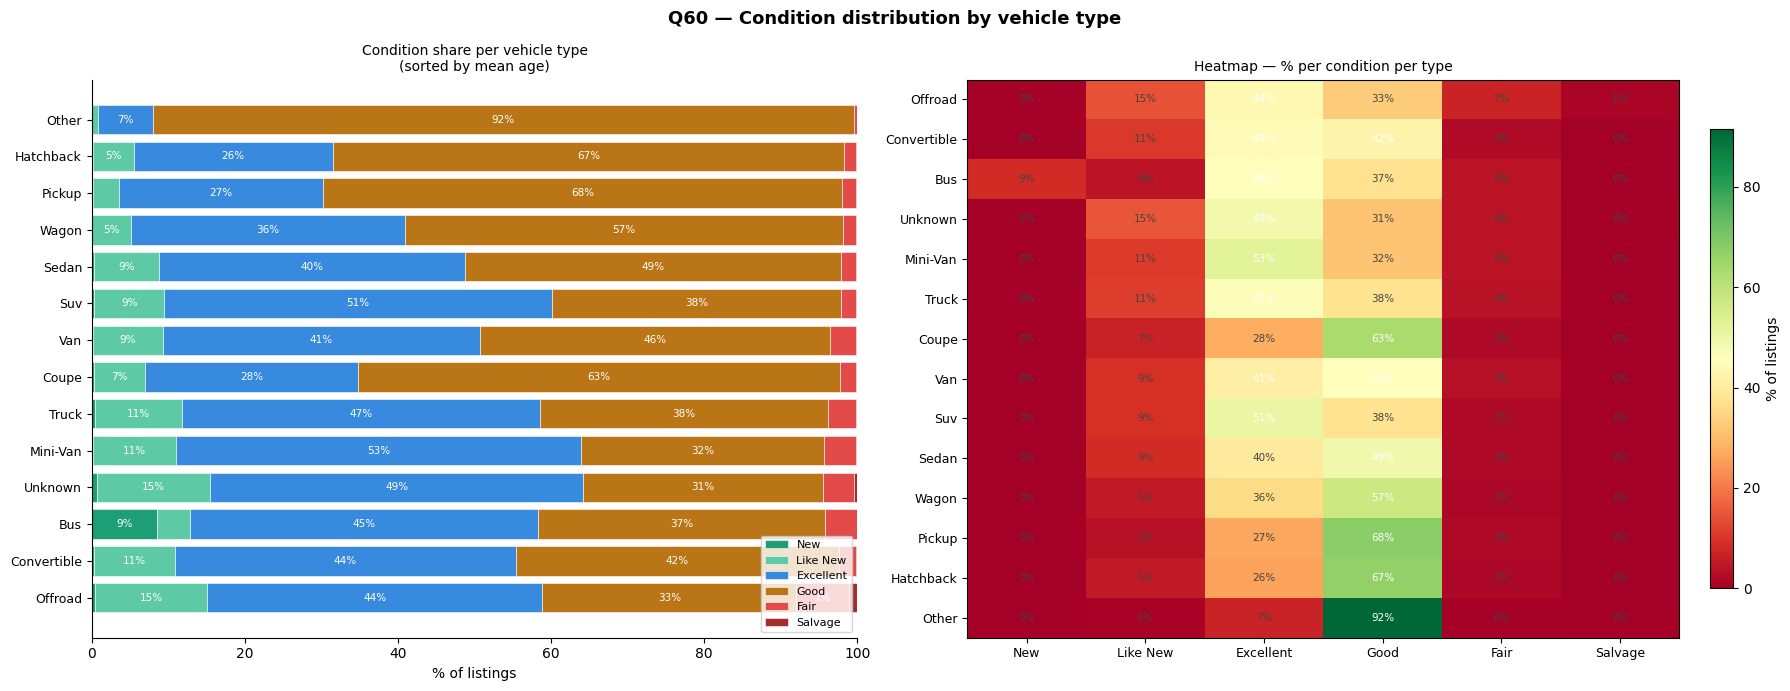


── Q60 Condition distribution by vehicle type ───────────
  Type                   New   Like New  Excellent       Good       Fair    Salvage
  ─────────────────────────────────────────────────────────────────────────────────
  Offroad               0.4%      14.7%      43.8%      33.2%       6.9%       1.1%
  Convertible           0.3%      10.5%      44.5%      42.3%       2.2%       0.2%
  Bus                   8.5%       4.3%      45.5%      37.4%       4.3%          —
  Unknown               0.6%      14.9%      48.7%      31.2%       4.1%       0.4%
  Mini-Van              0.2%      10.9%      52.9%      31.8%       4.2%       0.1%
  Truck                 0.4%      11.4%      46.7%      37.6%       3.6%       0.3%
  Coupe                 0.3%       6.7%      27.8%      63.0%       2.1%       0.2%
  Van                   0.1%       9.2%      41.4%      45.6%       3.4%       0.2%
  Suv                   0.3%       9.1%      50.7%      37.7%       2.0%       0.2%
  Sedan          

In [33]:
# ════════════════════════════════════════════════════════════════
# Q60 — Condition distribution by vehicle type
# ════════════════════════════════════════════════════════════════
if 'df_cond' not in dir(): raise NameError("Run shared cleaning block first")

df_q60 = df_cond_known.dropna(subset=['type']).copy()

type_cond = (
    df_q60.groupby(['type', 'condition'], observed=True)
    .size()
    .reset_index(name='count')
)
type_cond['pct'] = type_cond.groupby('type')['count'].transform(
    lambda x: x / x.sum() * 100)

# keep types with enough data
valid_types = (
    df_q60['type'].value_counts()[lambda x: x >= 200].index.tolist()
)
type_cond = type_cond[type_cond['type'].isin(valid_types)]
types_sorted = (
    df_q60[df_q60['type'].isin(valid_types)]
    .groupby('type', observed=True)['vehicle_age']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Q60 — Condition distribution by vehicle type',
             fontsize=13, fontweight='bold')

# LEFT: Stacked horizontal bar
ax1 = axes[0]
bottom_vals = {t: 0 for t in types_sorted}
for cond in COND_ORDER:
    vals = []
    for t in types_sorted:
        row = type_cond[
            (type_cond['type'] == t) &
            (type_cond['condition'] == cond)
        ]
        vals.append(row['pct'].values[0] if not row.empty else 0)
    ax1.barh(
        [t.title() for t in types_sorted], vals,
        left=[bottom_vals[t] for t in types_sorted],
        color=COND_COLORS[cond], edgecolor='white',
        linewidth=0.4, label=cond.title()
    )
    for i, (t, val) in enumerate(zip(types_sorted, vals)):
        if val > 5:
            ax1.text(bottom_vals[t] + val / 2, i,
                     f"{val:.0f}%",
                     ha='center', va='center',
                     fontsize=7.5, color='white', fontweight='500')
        bottom_vals[t] += val

ax1.set_xlabel('% of listings')
ax1.set_title('Condition share per vehicle type\n(sorted by mean age)',
              fontsize=10)
ax1.spines[['top','right']].set_visible(False)
ax1.legend(fontsize=8, loc='lower right')
ax1.tick_params(axis='y', labelsize=9)

# RIGHT: Heatmap — % good condition per type
ax2 = axes[1]
heatmap_data = type_cond.pivot(
    index='type', columns='condition', values='pct'
).reindex(index=types_sorted, columns=COND_ORDER).fillna(0)

im = ax2.imshow(heatmap_data.values, aspect='auto', cmap='RdYlGn')
ax2.set_xticks(range(len(COND_ORDER)))
ax2.set_xticklabels([c.title() for c in COND_ORDER], fontsize=9)
ax2.set_yticks(range(len(types_sorted)))
ax2.set_yticklabels([t.title() for t in types_sorted], fontsize=9)
ax2.set_title('Heatmap — % per condition per type', fontsize=10)

for i in range(len(types_sorted)):
    for j in range(len(COND_ORDER)):
        val = heatmap_data.values[i, j]
        ax2.text(j, i, f"{val:.0f}%",
                 ha='center', va='center',
                 fontsize=7.5,
                 color='white' if val > 40 else '#444441')
plt.colorbar(im, ax=ax2, fraction=0.03, pad=0.04, label='% of listings')

plt.tight_layout()
plt.savefig('q60_condition_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Q60 Condition distribution by vehicle type ───────────")
print(f"  {'Type':<15} " +
      " ".join(f"{c.title():>10}" for c in COND_ORDER))
print("  " + "─" * (15 + 11 * len(COND_ORDER)))
for t in types_sorted:
    row_vals = []
    for c in COND_ORDER:
        row = type_cond[
            (type_cond['type'] == t) &
            (type_cond['condition'] == c)
        ]
        row_vals.append(
            f"{row['pct'].values[0]:>9.1f}%" if not row.empty else f"{'—':>10}"
        )
    print(f"  {t.title():<15} " + " ".join(row_vals))

## **Geography & regional analysis**


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── SHARED CLEANING ───────────────────────────────────────────
df_age = df[['year', 'price', 'manufacturer', 'model',
             'type', 'odometer', 'condition',
             'state', 'region']].copy()

# Remove invalid values
df_age = df_age[df_age['price'] > 0]
df_age = df_age[df_age['odometer'] > 0]

# Remove missing values
df_age = df_age.dropna(subset=[
    'year',
    'manufacturer',
    'state',
    'region'
])

# Remove price outliers
p_low = df_age['price'].quantile(0.01)
p_high = df_age['price'].quantile(0.99)

df_age = df_age[
    (df_age['price'] >= p_low) &
    (df_age['price'] <= p_high)
    ]

# Keep only realistic model years
df_age = df_age[df_age['year'].between(1900, 2021)]

# Vehicle age
df_age['vehicle_age'] = 2021 - df_age['year']

# Decade column
# # df_age['decade'] = (df_age['year'] // 10 * 10).astype(int).astype(str) + 's'

print(f"df_age ready — {len(df_age):,} rows")
print(f"Year range    : {int(df_age['year'].min())} → {int(df_age['year'].max())}")
print("Safety check  : 'df_age' in scope ✓")


df_age ready — 371,781 rows
Year range    : 1900 → 2021
Safety check  : 'df_age' in scope ✓


state
wv   24,881.66
mt   23,892.83
ak   23,477.90
wa   22,741.79
mo   22,327.56
wy   22,156.27
ut   22,005.52
ar   21,579.19
nm   21,064.91
al   21,042.47
Name: price, dtype: float64


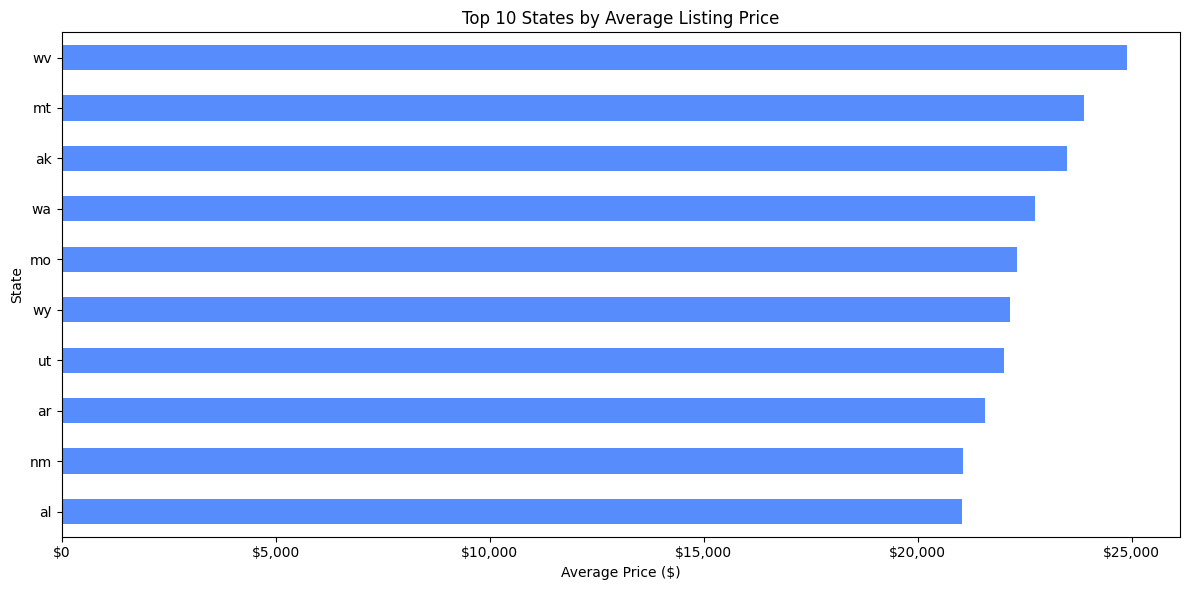

In [36]:
# ════════════════════════════════════════════════════════════════
# Q62 — Which states have the highest average listing price?
# ════════════════════════════════════════════════════════════════

state_price = (
    df_age.groupby('state')['price']
    .mean()
    .sort_values(ascending=False)
)

print(state_price.head(10))

plt.figure(figsize=(12,6))
state_price.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 States by Average Listing Price')
plt.xlabel('Average Price ($)')
plt.ylabel('State')
plt.gca().xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

region
scottsbluff   31,667.16
boone         31,268.89
olympic       31,149.30
logan         30,212.90
nwks          30,138.07
                 ...   
racine        10,919.75
showlow       10,757.84
seks          10,232.37
siskiyou       9,378.99
wv             8,627.14
Name: price, Length: 413, dtype: float64


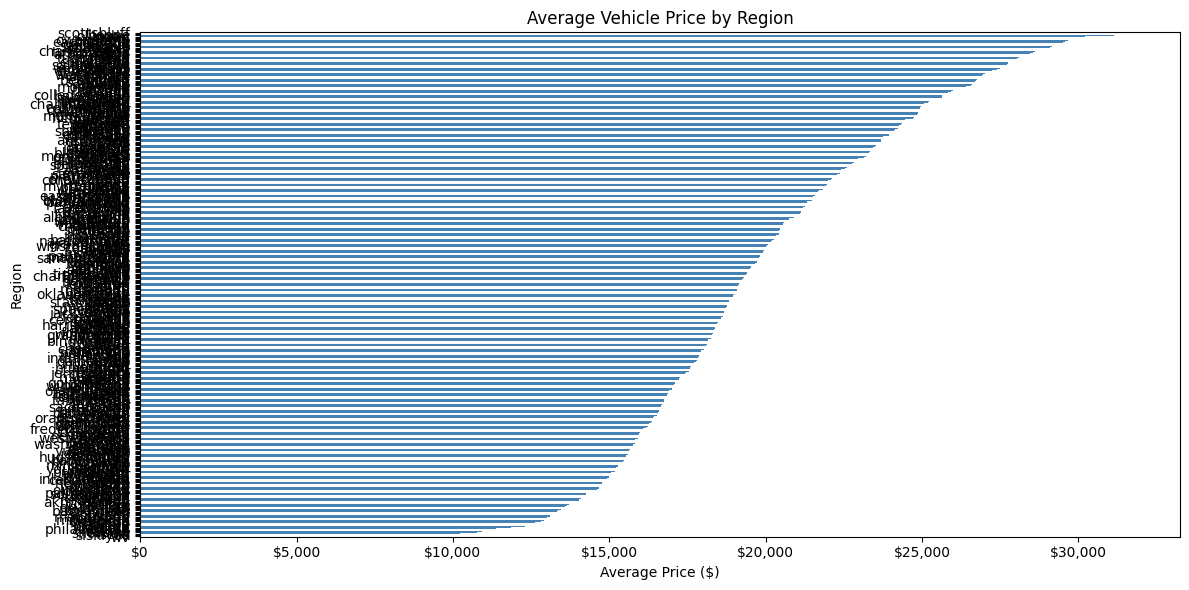

In [38]:
# ════════════════════════════════════════════════════════════════
# Q65 — How does average price vary by region?
# ════════════════════════════════════════════════════════════════

region_price = (
    df_age.groupby('region')['price']
    .mean()
    .sort_values(ascending=False)
)

print(region_price)

plt.figure(figsize=(12, 6))
region_price.sort_values().plot(kind='barh', color='steelblue')

plt.title('Average Vehicle Price by Region')
plt.xlabel('Average Price ($)')
plt.ylabel('Region')

plt.gca().xaxis.set_major_formatter(
    mticker.StrMethodFormatter('${x:,.0f}')
)

plt.tight_layout()
plt.show()

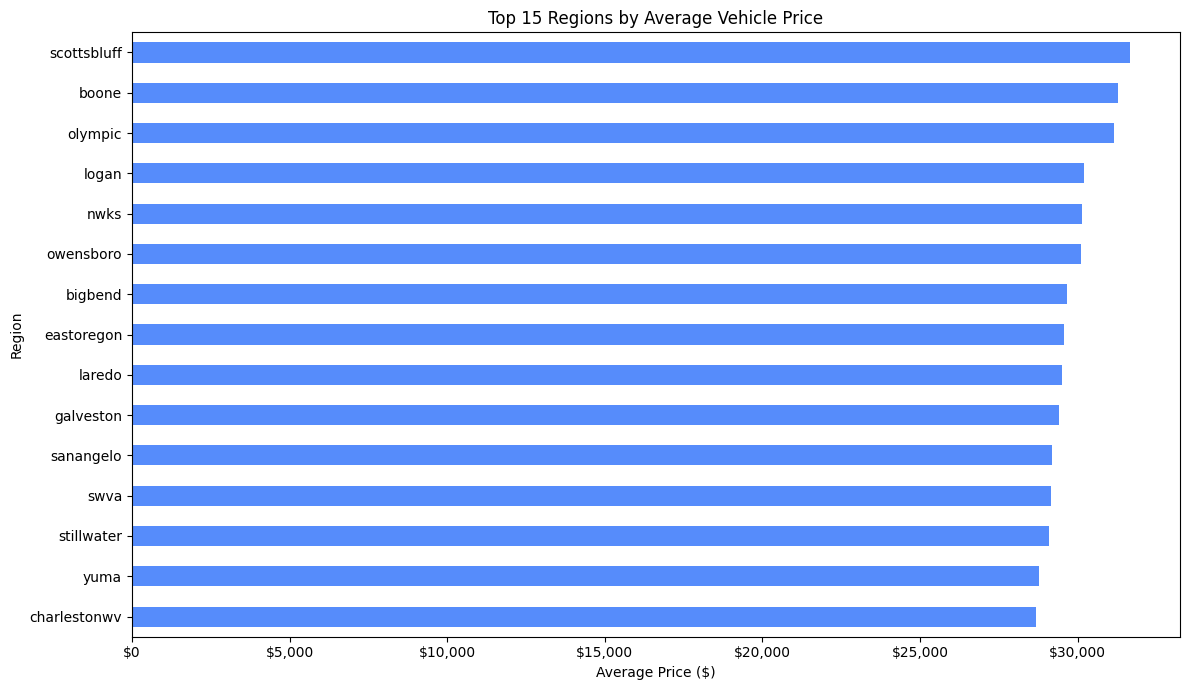

In [42]:
# make it more readable
region_price = (
    df_age.groupby('region')['price']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,7))
region_price.sort_values().plot(kind='barh')

plt.title('Top 15 Regions by Average Vehicle Price')
plt.xlabel('Average Price ($)')
plt.ylabel('Region')

plt.gca().xaxis.set_major_formatter(
    mticker.StrMethodFormatter('${x:,.0f}')
)

plt.tight_layout()
plt.show()

In [56]:
import plotly.express as px

# ── SAFE COPY (DO NOT TOUCH ORIGINAL) ───────────────────────
df_map = df_age.copy()

# ── CLEAN STATE ─────────────────────────────────────────────
# # df_map['state'] = df_map['state'].astype(str).str.upper().str.strip()
df_map = df_map[df_map['state'].str.len() == 2]

# ── REMOVE INVALID PRICES ───────────────────────────────────
df_map = df_map[df_map['price'] > 0]

# ── GROUP BY STATE ───────────────────────────────────────────
state_price = (
    df_map.groupby('state')['price']
    .mean()
    .reset_index()
)

# ── MAP ──────────────────────────────────────────────────────
fig = px.choropleth(
    state_price,
    locations='state',
    locationmode="USA-states",
    color='price',
    color_continuous_scale='Viridis',
    scope="usa",
    labels={'price': 'Avg Price ($)'},
    title='Average Vehicle Price by State'
)

fig.show()


manufacturer   bmw  chevrolet  dodge  ford   gmc  honda  jeep  nissan   ram  \
state                                                                         
ak             118        542    176   565   113    141   220     151   196   
al             125        579    120   874   210    190   214     243   133   
ar              73        563    132   483   197    124   155     160   201   
az             244       1145    245  1219   283    348   332     365   327   
ca            1945       4769   1113  6112  1244   2820  1340    2233  1570   

manufacturer  toyota  
state                 
ak               216  
al               375  
ar               210  
az               732  
ca              4734  


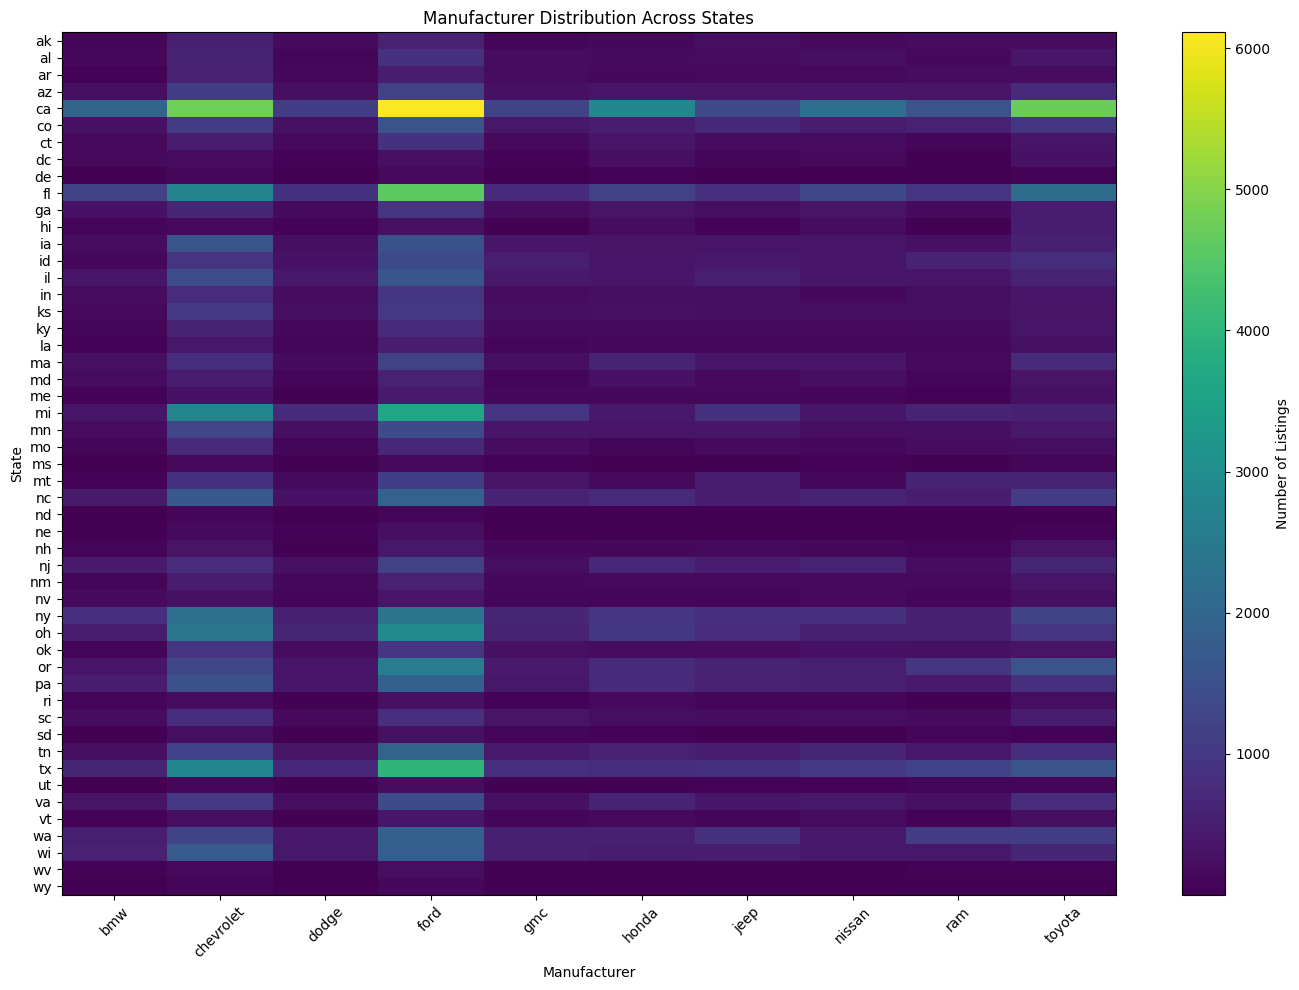

In [43]:
# ════════════════════════════════════════════════════════════════
# Q67 — Is there a geographic clustering of specific manufacturers?
# ════════════════════════════════════════════════════════════════

top_manufacturers = (
    df_age['manufacturer']
    .value_counts()
    .head(10)
    .index
)

cluster = (
    df_age[df_age['manufacturer'].isin(top_manufacturers)]
    .groupby(['state','manufacturer'])
    .size()
    .unstack(fill_value=0)
)

print(cluster.head())

plt.figure(figsize=(14,10))
plt.imshow(cluster, aspect='auto')

plt.title('Manufacturer Distribution Across States')
plt.xlabel('Manufacturer')
plt.ylabel('State')

plt.xticks(range(len(cluster.columns)), cluster.columns, rotation=45)
plt.yticks(range(len(cluster.index)), cluster.index)

plt.colorbar(label='Number of Listings')

plt.tight_layout()
plt.show()

state
sd   125,211.53
nd   120,551.27
ut   112,233.24
ms   112,227.98
me   110,202.97
mi   109,912.63
de   108,708.28
va   108,309.47
co   107,333.31
mn   106,983.31
Name: odometer, dtype: float64


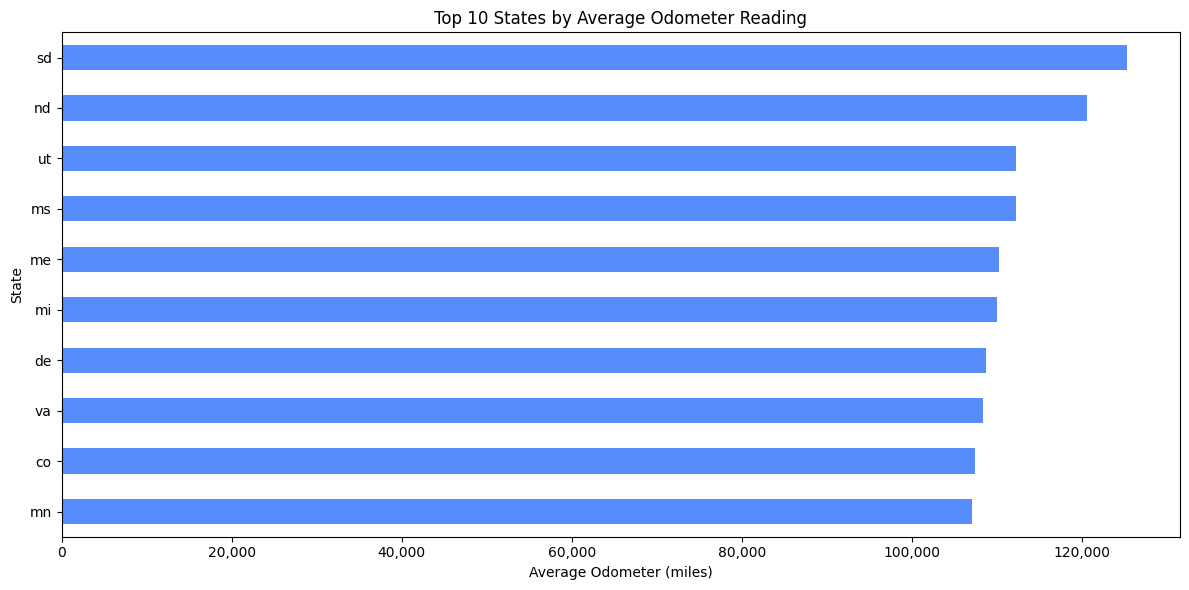

In [44]:
# ════════════════════════════════════════════════════════════════
# Q68 — What is the average odometer reading by state?
# ════════════════════════════════════════════════════════════════

state_odometer = (
    df_age.groupby('state')['odometer']
    .mean()
    .sort_values(ascending=False)
)

print(state_odometer.head(10))

plt.figure(figsize=(12,6))
state_odometer.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 States by Average Odometer Reading')
plt.xlabel('Average Odometer (miles)')
plt.ylabel('State')

plt.gca().xaxis.set_major_formatter(
    mticker.StrMethodFormatter('{x:,.0f}')
)

plt.tight_layout()
plt.show()

state                 ak        al        ar        az        ca        co  \
model                                                                        
1500           30,221.00 20,449.00 30,409.00 18,304.00 24,697.00 23,730.00   
UNKNOWN        16,589.00 21,548.00 18,753.00 15,225.00 13,995.00 16,035.00   
camry          20,747.00 11,582.00  8,880.00  9,283.00 10,458.00 12,863.00   
f-150          32,823.00 20,925.00 28,851.00 19,465.00 22,432.00 22,854.00   
silverado 1500 35,531.00 27,007.00 37,142.00 21,430.00 19,526.00 26,195.00   

state                 ct        dc        de        fl  ...        sd  \
model                                                   ...             
1500           20,539.00 27,377.00 29,398.00 17,604.00  ... 26,144.00   
UNKNOWN         9,466.00 10,719.00 13,602.00 17,637.00  ... 23,273.00   
camry           6,207.00  8,572.00  7,500.00 10,078.00  ... 11,257.00   
f-150          12,859.00 19,801.00  5,110.00 22,206.00  ... 23,181.00   
silverado 1500 

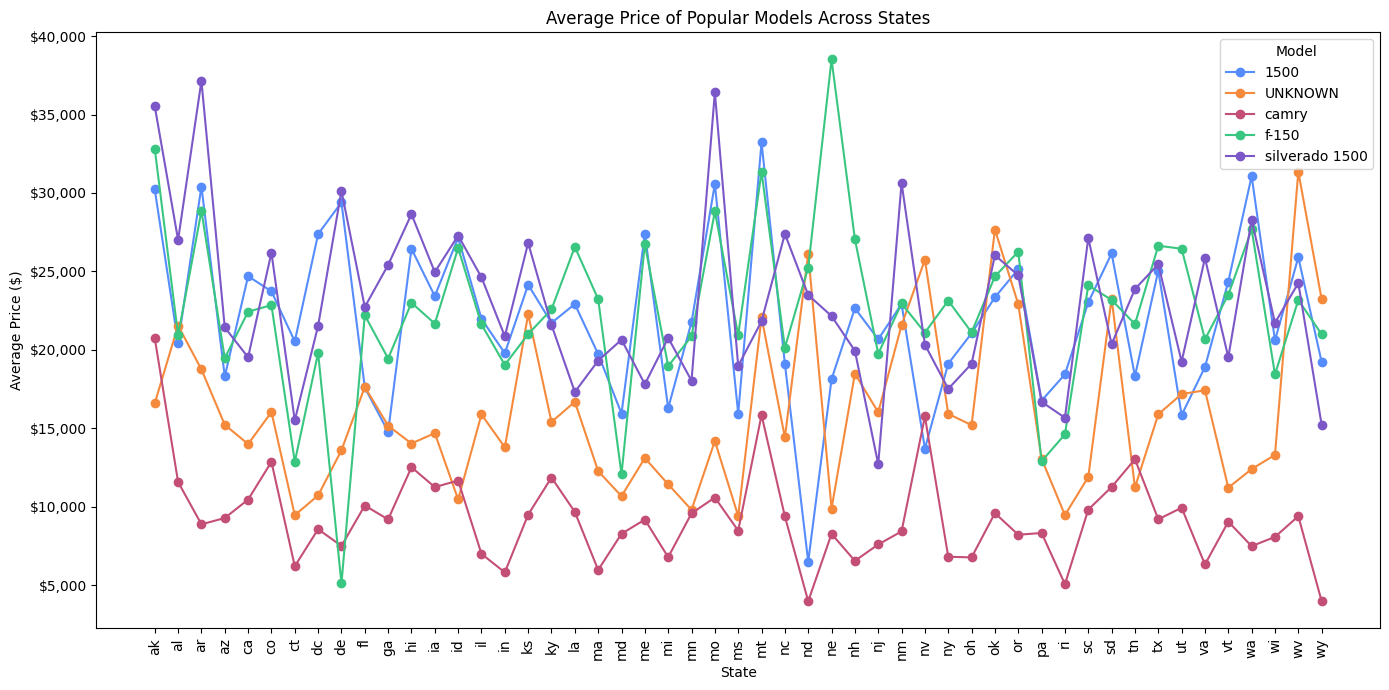

In [45]:
# ════════════════════════════════════════════════════════════════
# Q70 — Are there price differences for the same vehicle model
#        across different states?
# ════════════════════════════════════════════════════════════════

top_models = (
    df_age['model']
    .value_counts()
    .head(5)
    .index
)

model_state_price = (
    df_age[df_age['model'].isin(top_models)]
    .groupby(['model','state'])['price']
    .mean()
    .unstack()
)

print(model_state_price.round(0))

plt.figure(figsize=(14,7))

for model in model_state_price.index:
    plt.plot(
        model_state_price.columns,
        model_state_price.loc[model],
        marker='o',
        label=model
    )

plt.title('Average Price of Popular Models Across States')
plt.xlabel('State')
plt.ylabel('Average Price ($)')

plt.gca().yaxis.set_major_formatter(
    mticker.StrMethodFormatter('${x:,.0f}')
)

plt.xticks(rotation=90)
plt.legend(title='Model')

plt.tight_layout()
plt.show()

state                 ak        al        ar        az        ca        co  \
model                                                                        
1500           30,221.00 20,449.00 30,409.00 18,304.00 24,697.00 23,730.00   
camry          20,747.00 11,582.00  8,880.00  9,283.00 10,458.00 12,863.00   
f-150          32,823.00 20,925.00 28,851.00 19,465.00 22,432.00 22,854.00   
silverado      27,231.00 22,582.00 18,555.00 20,132.00 20,451.00 26,778.00   
silverado 1500 35,531.00 27,007.00 37,142.00 21,430.00 19,526.00 26,195.00   

state                 ct        dc        de        fl  ...        sd  \
model                                                   ...             
1500           20,539.00 27,377.00 29,398.00 17,604.00  ... 26,144.00   
camry           6,207.00  8,572.00  7,500.00 10,078.00  ... 11,257.00   
f-150          12,859.00 19,801.00  5,110.00 22,206.00  ... 23,181.00   
silverado      13,034.00 22,486.00 14,467.00 23,284.00  ... 19,264.00   
silverado 1500 

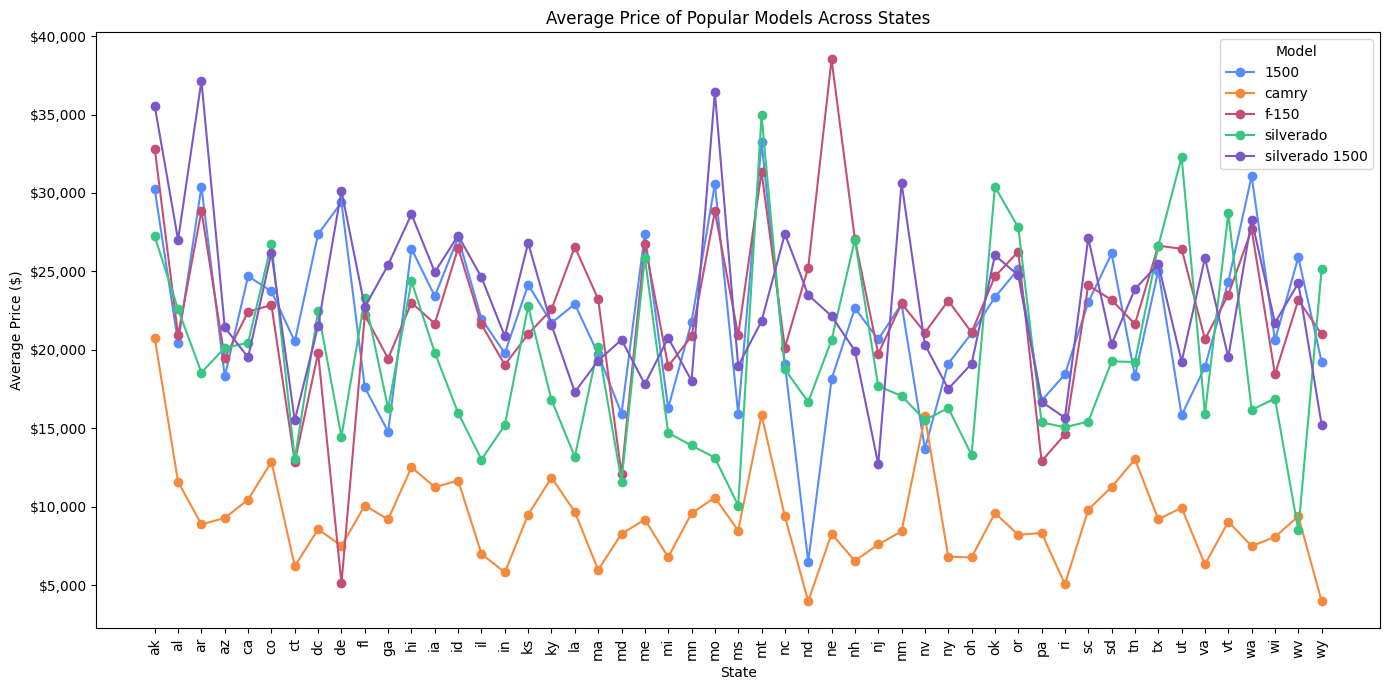

In [46]:
# ════════════════════════════════════════════════════════════════
# Q70 — Are there price differences for the same vehicle model
#        across different states?
# ════════════════════════════════════════════════════════════════

# Clean UNKNOWN values
df_clean = df_age[
    df_age['model'].notna() &
    (df_age['model'].str.lower() != 'unknown') &
    (df_age['model'].str.upper() != 'UNKOWN')
]

top_models = (
    df_clean['model']
    .value_counts()
    .head(5)
    .index
)

model_state_price = (
    df_clean[df_clean['model'].isin(top_models)]
    .groupby(['model', 'state'])['price']
    .mean()
    .unstack()
)

print(model_state_price.round(0))

plt.figure(figsize=(14,7))

for model in model_state_price.index:
    plt.plot(
        model_state_price.columns,
        model_state_price.loc[model],
        marker='o',
        label=model
    )

plt.title('Average Price of Popular Models Across States')
plt.xlabel('State')
plt.ylabel('Average Price ($)')

plt.gca().yaxis.set_major_formatter(
    mticker.StrMethodFormatter('${x:,.0f}')
)

plt.xticks(rotation=90)
plt.legend(title='Model')

plt.tight_layout()
plt.show()

## **Fuel & drivetrain analysis**

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── SHARED CLEANING ───────────────────────────────────────────

df_age = df[['year', 'price', 'manufacturer', 'model',
             'type', 'odometer', 'condition',
             'state', 'region',
             'fuel', 'drive']].copy()

# Remove invalid values
df_age = df_age[
    (df_age['price'] > 0) &
    (df_age['odometer'] > 0)
    ]

# Drop missing core fields
df_age = df_age.dropna(subset=[
    'year',
    'manufacturer',
    'state',
    'region',
    'fuel',
    'drive'
])

# Remove price outliers
p_low = df_age['price'].quantile(0.01)
p_high = df_age['price'].quantile(0.99)

df_age = df_age[
    (df_age['price'] >= p_low) &
    (df_age['price'] <= p_high)
    ]

# Keep realistic years
df_age = df_age[df_age['year'].between(1900, 2021)]

# Feature engineering
df_age['vehicle_age'] = 2021 - df_age['year']
# # df_age['decade'] = (df_age['year'] // 10 * 10).astype(int).astype(str) + 's'

# Normalize text (VERY IMPORTANT for fuel/drive questions)
# # df_age['fuel'] = df_age['fuel'].str.lower()
# # df_age['drive'] = df_age['drive'].str.lower()

print(f"df_age ready — {len(df_age):,} rows")
print(f"Year range    : {df_age['year'].min():.0f} → {df_age['year'].max():.0f}")
print("Safety check  : ALL FEATURES READY ✓")


df_age ready — 371,781 rows
Year range    : 1900 → 2021
Safety check  : ALL FEATURES READY ✓


fuel
gas         315458
other        26413
diesel       21496
hybrid        4777
unknown       2126
electric      1511
Name: count, dtype: int64


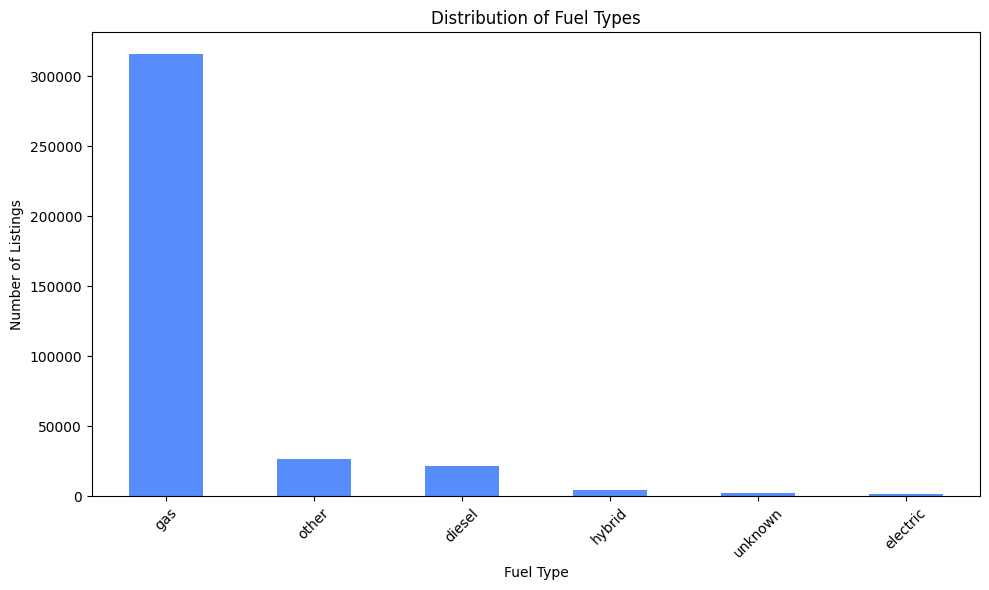

In [48]:
# ════════════════════════════════════════════════════════════════
# Q71 — What is the distribution of fuel types?
# ════════════════════════════════════════════════════════════════

fuel_dist = df_age['fuel'].value_counts()

print(fuel_dist)

plt.figure(figsize=(10,6))
fuel_dist.plot(kind='bar')

plt.title('Distribution of Fuel Types')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Listings')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Electric or Hybrid: 1.69%


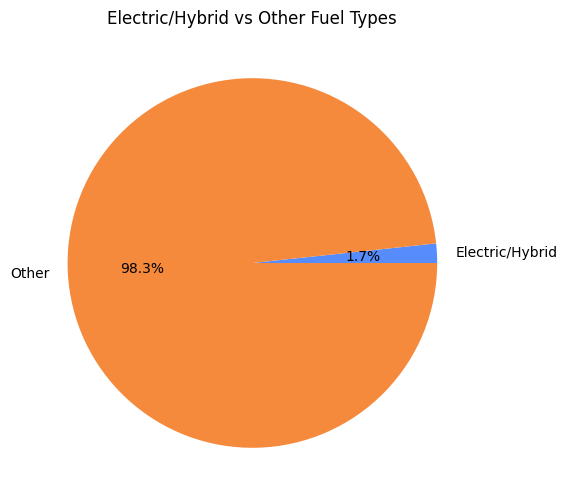

In [49]:
# ════════════════════════════════════════════════════════════════
# Q72 — What percentage of listings are electric or hybrid?
# ════════════════════════════════════════════════════════════════

fuel_clean = df_age['fuel'].dropna().str.lower()

ev_hybrid_count = fuel_clean.isin(['electric', 'hybrid']).sum()
total_count = fuel_clean.shape[0]

percentage = (ev_hybrid_count / total_count) * 100

print(f"Electric or Hybrid: {percentage:.2f}%")

plt.figure(figsize=(6,6))
plt.pie(
    [ev_hybrid_count, total_count - ev_hybrid_count],
    labels=['Electric/Hybrid', 'Other'],
    autopct='%1.1f%%'
)

plt.title('Electric/Hybrid vs Other Fuel Types')
plt.show()

fuel
diesel   31,220.92
gas      16,768.89
Name: price, dtype: float64


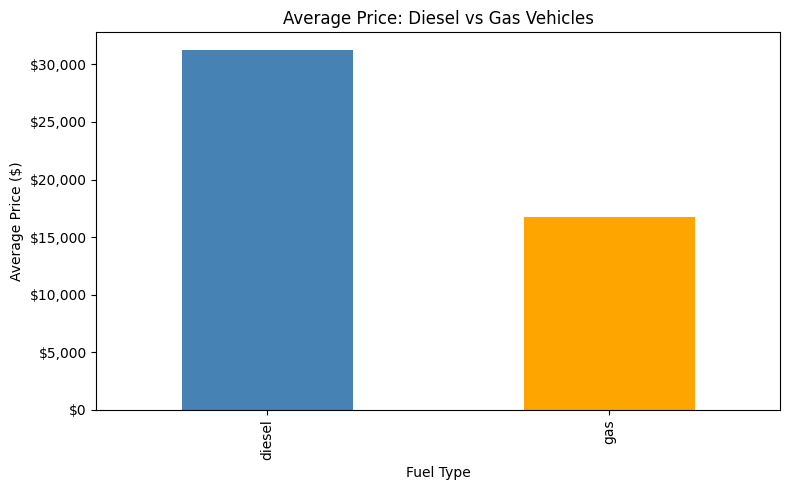

In [51]:
# ════════════════════════════════════════════════════════════════
# Q73 — What is the average price of diesel vs gas vehicles?
# ════════════════════════════════════════════════════════════════

fuel_price = (
    df_age[df_age['fuel'].isin(['diesel', 'gas'])]
    .groupby('fuel')['price']
    .mean()
    .sort_values(ascending=False)
)

print(fuel_price)

plt.figure(figsize=(8,5))
fuel_price.plot(kind='bar', color=['steelblue', 'orange'])

plt.title('Average Price: Diesel vs Gas Vehicles')
plt.xlabel('Fuel Type')
plt.ylabel('Average Price ($)')

plt.gca().yaxis.set_major_formatter(
    mticker.StrMethodFormatter('${x:,.0f}')
)

plt.tight_layout()
plt.show()

drive
4wd        114926
unknown    112773
fwd         94005
rwd         50077
Name: count, dtype: int64


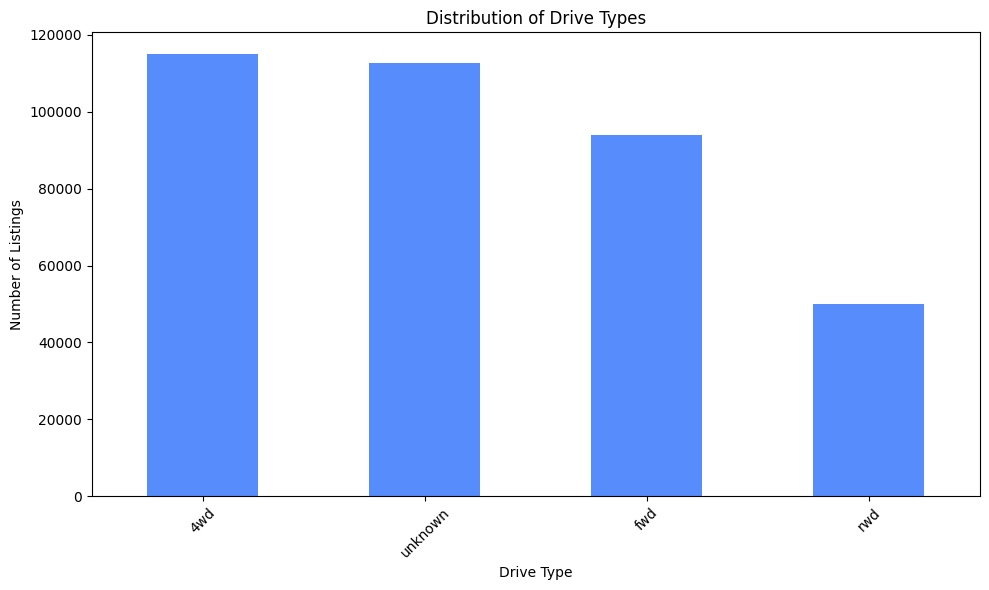

In [52]:
# ════════════════════════════════════════════════════════════════
# Q74 — What is the distribution of drive types?
# ════════════════════════════════════════════════════════════════

drive_dist = df_age['drive'].value_counts()

print(drive_dist)

plt.figure(figsize=(10,6))
drive_dist.plot(kind='bar')

plt.title('Distribution of Drive Types')
plt.xlabel('Drive Type')
plt.ylabel('Number of Listings')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

drive_clean
2WD   15,209.29
4WD   22,648.95
Name: price, dtype: float64


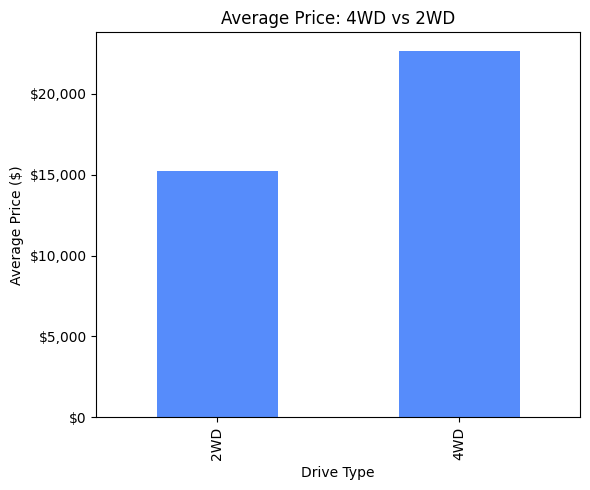

In [53]:
# ════════════════════════════════════════════════════════════════
# Q76 — What is the average price of 4WD vs 2WD vehicles?
# ════════════════════════════════════════════════════════════════

df_drive = df_age.copy()

df_drive['drive_clean'] = df_drive['drive'].replace({
    '4wd': '4WD',
    'fwd': '2WD',
    'rwd': '2WD'
})

drive_price = (
    df_drive[df_drive['drive_clean'].isin(['4WD', '2WD'])]
    .groupby('drive_clean')['price']
    .mean()
)

print(drive_price)

plt.figure(figsize=(6,5))
drive_price.plot(kind='bar')

plt.title('Average Price: 4WD vs 2WD')
plt.xlabel('Drive Type')
plt.ylabel('Average Price ($)')

plt.gca().yaxis.set_major_formatter(
    mticker.StrMethodFormatter('${x:,.0f}')
)

plt.tight_layout()
plt.show()

## **Listing & seller analysis**

In [59]:
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────────────────────
# LISTING & SELLER CLEANING PIPELINE (Q79–Q86 READY)
# ─────────────────────────────────────────────────────────────

df_ls = df.copy()

# ── Fix datetime (IMPORTANT: resolves timezone error) ────────
# df_ls['posting_date'] = pd.to_datetime(
#     df_ls['posting_date'],
#     errors='coerce',
#     utc=True
# )

# Remove invalid dates
# # df_ls = df_ls.dropna(subset=['posting_date'])

# ── Time features ─────────────────────────────────────────────
# # df_ls['day_of_week'] = df_ls['posting_date'].dt.day_name()
# # df_ls['date'] = df_ls['posting_date'].dt.date

# ── Normalize text columns ────────────────────────────────────
# text_cols = ['title_status', 'condition', 'cylinders', 'drive', 'size']
# for col in text_cols:
#     if col in df_ls.columns:
#         df_ls[col] = df_ls[col].astype(str).str.lower().str.strip()

# ── Clean seller column (safe handling) ───────────────────────
# if 'seller' in df_ls.columns:
#     df_ls['seller'] = df_ls['seller'].astype(str).str.lower().str.strip()
# elif 'source' in df_ls.columns:
#     df_ls['seller'] = df_ls['source'].astype(str).str.lower().str.strip()
# else:
#     df_ls['seller'] = 'unknown'

# ── Remove invalid numeric values ─────────────────────────────
df_ls = df_ls[
    (df_ls['price'] > 0) &
    (df_ls['odometer'] > 0)
    ]

# ── Remove price outliers ─────────────────────────────────────
p_low = df_ls['price'].quantile(0.01)
p_high = df_ls['price'].quantile(0.99)

df_ls = df_ls[
    (df_ls['price'] >= p_low) &
    (df_ls['price'] <= p_high)
    ]

# ── Missing data feature (Q86) ────────────────────────────────
df_ls['missing_fields_count'] = df_ls[
    ['condition', 'cylinders', 'drive', 'size']
].isna().sum(axis=1)

# ── Final check ────────────────────────────────────────────────
print(f"df_ls ready — {len(df_ls):,} rows")
print("Listing & Seller dataset cleaned successfully ✓")


df_ls ready — 371,850 rows
Listing & Seller dataset cleaned successfully ✓


region
omaha          2868
grandrapids    2837
kansascity     2803
cnj            2769
milwaukee      2761
nashville      2749
tampa          2746
sarasota       2739
detroit        2713
denver         2712
stlouis        2707
columbus       2700
newjersey      2699
southjersey    2697
chicago        2694
Name: count, dtype: int64


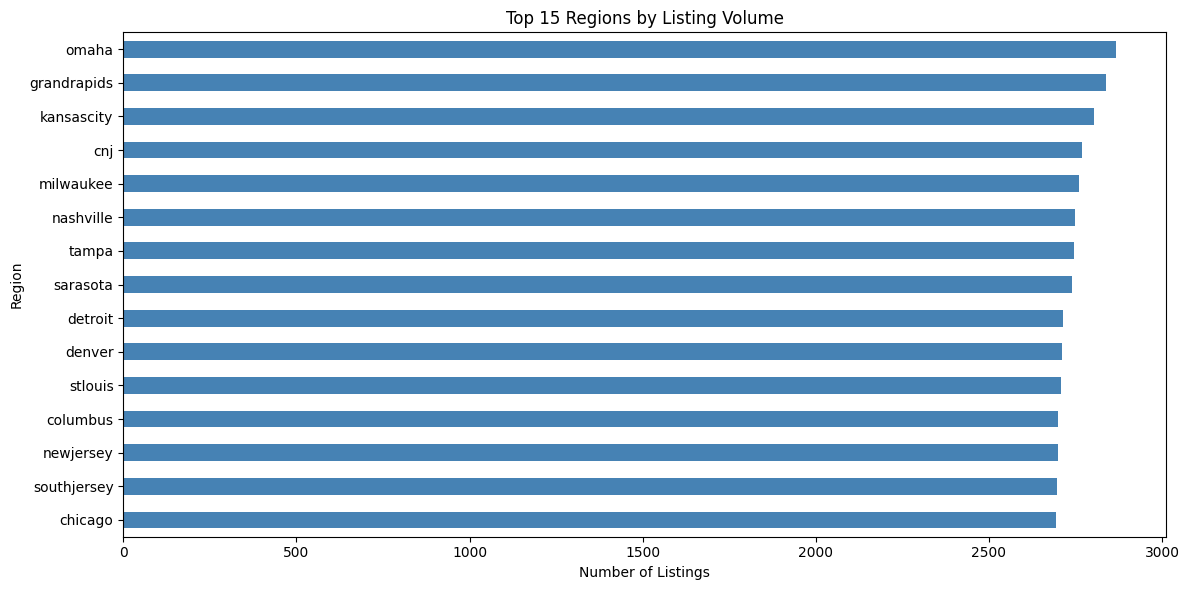

In [62]:
# ════════════════════════════════════════════════════════════════
# Q79 — Which regions have the most listings?
# ════════════════════════════════════════════════════════════════

region_count = df_ls['region'].value_counts().head(15)

print(region_count)

plt.figure(figsize=(12,6))
region_count.sort_values().plot(kind='barh', color='steelblue')

plt.title('Top 15 Regions by Listing Volume')
plt.xlabel('Number of Listings')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

state
ca    42203
fl    24884
tx    20125
ny    17085
oh    15908
mi    15752
or    13223
pa    12232
nc    12059
wa    11595
wi    10750
tn    10123
co     9916
il     9443
nj     8943
Name: count, dtype: int64


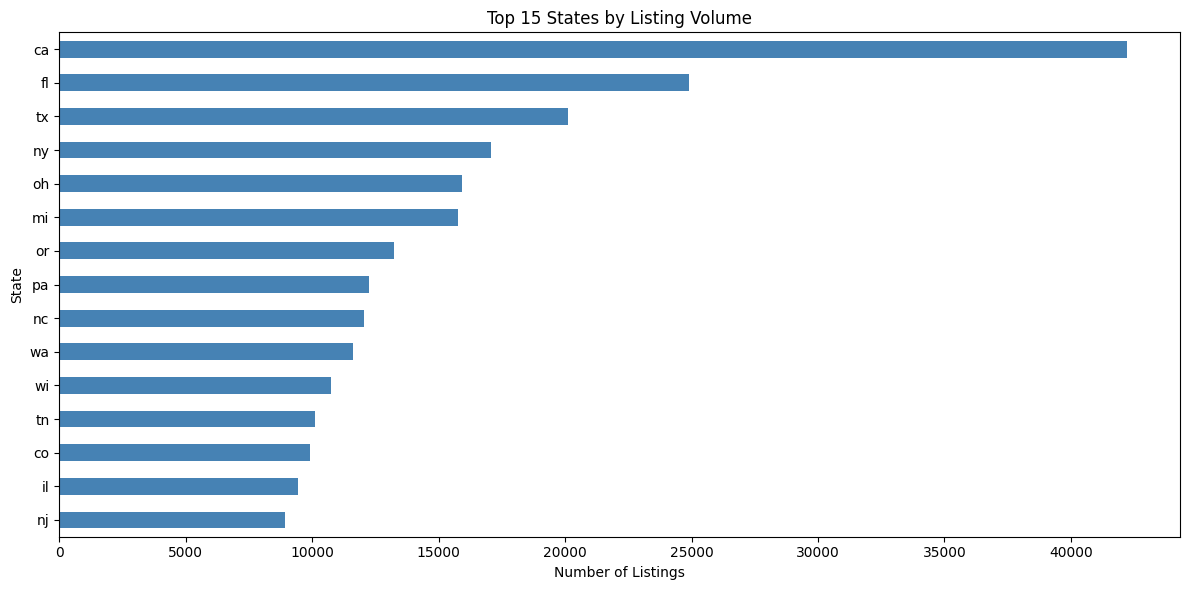

In [63]:
# ════════════════════════════════════════════════════════════════
# Q80 — Which states have the most listings?
# ════════════════════════════════════════════════════════════════

state_count = df_ls['state'].value_counts().head(15)

print(state_count)

plt.figure(figsize=(12,6))
state_count.sort_values().plot(kind='barh', color='steelblue')

plt.title('Top 15 States by Listing Volume')
plt.xlabel('Number of Listings')
plt.ylabel('State')

plt.tight_layout()
plt.show()

title_status
parts only    3,310.50
missing       5,440.12
salvage       9,547.12
rebuilt      12,773.52
unknown      15,444.37
clean        18,685.54
lien         21,075.32
Name: price, dtype: float64


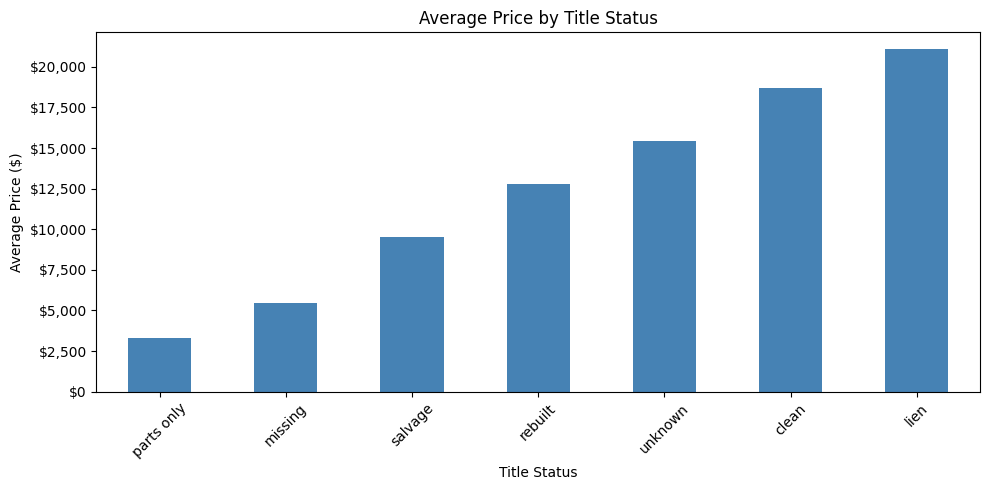

In [64]:
# ════════════════════════════════════════════════════════════════
# Q81 — What is the average price of listings with a clean title
#        vs other statuses?
# ════════════════════════════════════════════════════════════════

title_price = (
    df_ls.groupby('title_status')['price']
    .mean()
    .sort_values()
)

print(title_price)

plt.figure(figsize=(10,5))
title_price.plot(kind='bar', color='steelblue')

plt.title('Average Price by Title Status')
plt.xlabel('Title Status')
plt.ylabel('Average Price ($)')

plt.gca().yaxis.set_major_formatter(
    mticker.StrMethodFormatter('${x:,.0f}')
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

date
2021-04-04    3031
2021-04-05    6487
2021-04-06    6028
2021-04-07    6561
2021-04-08    7504
dtype: int64


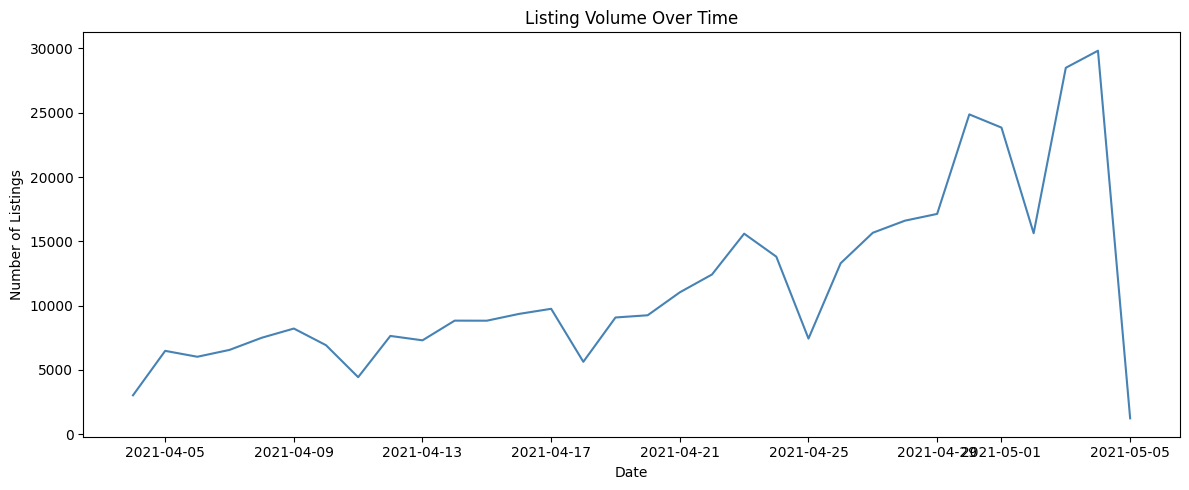

In [65]:
# ════════════════════════════════════════════════════════════════
# Q82 — How does listing volume change over posting dates?
# ════════════════════════════════════════════════════════════════

daily_listings = df_ls.groupby('date').size()

print(daily_listings.head())

plt.figure(figsize=(12,5))
daily_listings.plot(color='steelblue')

plt.title('Listing Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Listings')

plt.tight_layout()
plt.show()

day_of_week
Monday       65012
Tuesday      68081
Wednesday    44286
Thursday     45896
Friday       58053
Saturday     54340
Sunday       36182
Name: count, dtype: int64


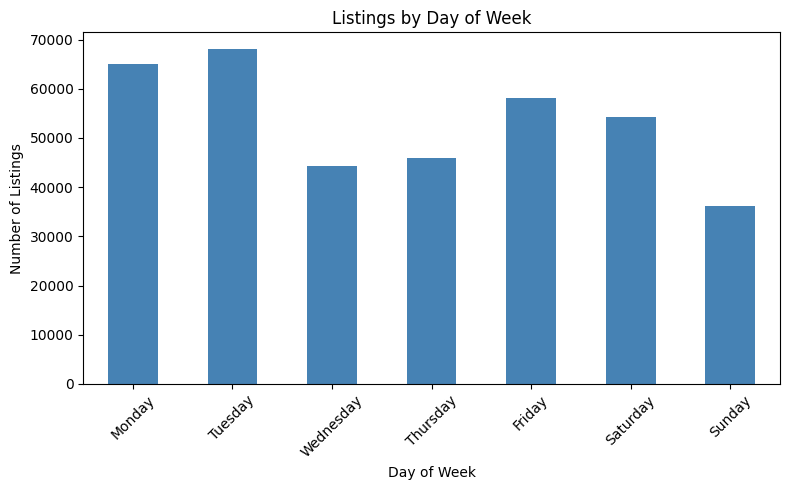

In [66]:
# ════════════════════════════════════════════════════════════════
# Q83 — What day of the week has the most listings?
# ════════════════════════════════════════════════════════════════

dow = df_ls['day_of_week'].value_counts()

order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

dow = dow.reindex(order)

print(dow)

plt.figure(figsize=(8,5))
dow.plot(kind='bar', color='steelblue')

plt.title('Listings by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Listings')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Missing data & quality** ##

In [67]:
# Q87

missing_percent = (df_ls.isna().mean() * 100).sort_values(ascending=False)

# also treat "unknown" strings
unknown_percent = (
    df_ls.apply(lambda x: x.astype(str).str.lower().eq('unknown').mean() * 100)
)

combined = pd.DataFrame({
    'Missing %': missing_percent,
    'Unknown %': unknown_percent
}).fillna(0)

print(combined.sort_values(by='Missing %', ascending=False).head(15))


                      Missing %  Unknown %
long                       0.90       0.00
lat                        0.90       0.00
description                0.00       0.00
condition                  0.00      38.22
cylinders                  0.00      40.28
day_of_week                0.00       0.00
date                       0.00       0.00
drive                      0.00      30.33
fuel                       0.00       0.57
image_url                  0.00       0.00
id                         0.00       0.00
manufacturer               0.00       0.00
missing_fields_count       0.00       0.00
model                      0.00       1.15
odometer                   0.00       0.00


long           0.90
lat            0.90
description    0.00
url            0.00
id             0.00
manufacturer   0.00
model          0.00
condition      0.00
cylinders      0.00
fuel           0.00
dtype: float64


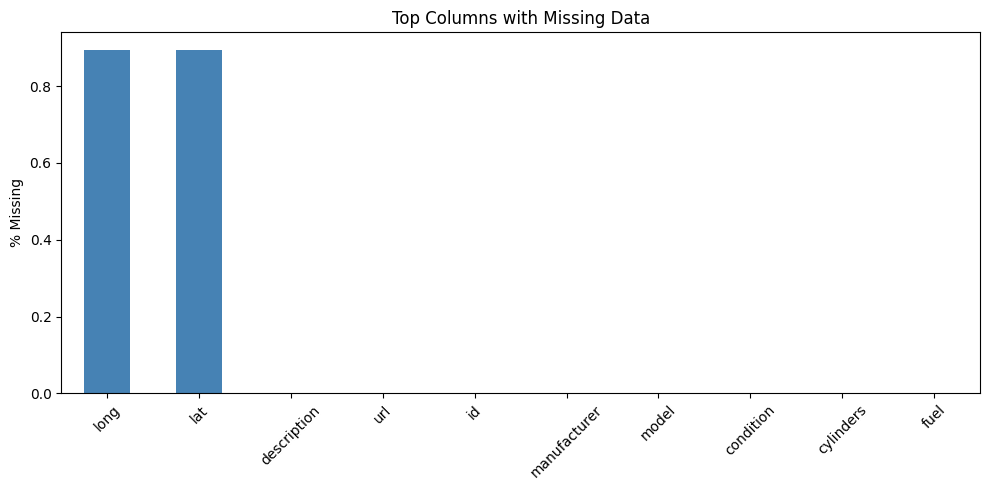

In [68]:
# Q88

missing_cols = df_ls.isna().mean().sort_values(ascending=False) * 100

print(missing_cols.head(10))

plt.figure(figsize=(10,5))
missing_cols.head(10).plot(kind='bar', color='steelblue')

plt.title('Top Columns with Missing Data')
plt.ylabel('% Missing')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

manufacturer
acura          0.00
alfa-romeo     0.00
aston-martin   0.00
audi           0.00
bmw            0.00
buick          0.00
cadillac       0.00
chevrolet      0.00
chrysler       0.00
datsun         0.00
Name: price, dtype: float64


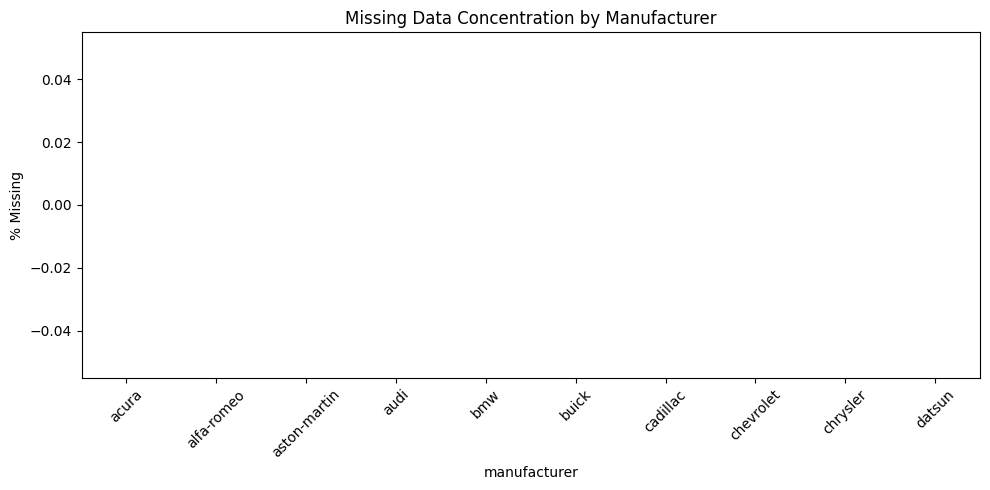

In [69]:
# Q89

missing_by_manu = (
    df_ls.groupby('manufacturer')['price']
    .apply(lambda x: x.isna().mean() * 100)
    .sort_values(ascending=False)
    .head(10)
)

print(missing_by_manu)

plt.figure(figsize=(10,5))
missing_by_manu.plot(kind='bar', color='steelblue')

plt.title('Missing Data Concentration by Manufacturer')
plt.ylabel('% Missing')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Duplicate VINs: 128451


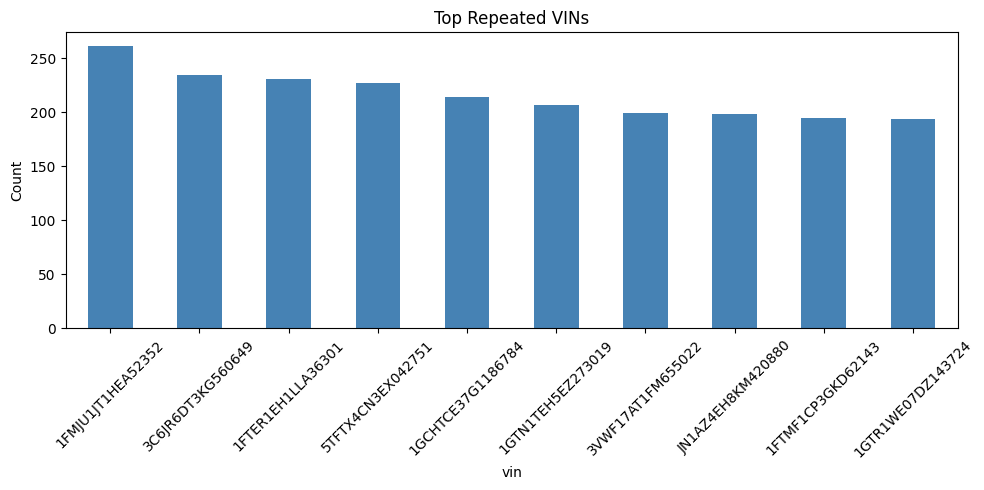

In [70]:
# Q90

df_vin = df_ls[df_ls['vin'].notna() & (df_ls['vin'].str.lower() != 'unknown')]

dup_vin_count = df_vin['vin'].duplicated().sum()

print("Duplicate VINs:", dup_vin_count)

vin_counts = df_vin['vin'].value_counts().head(10)

plt.figure(figsize=(10,5))
vin_counts.plot(kind='bar', color='steelblue')

plt.title('Top Repeated VINs')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Odometer outliers: 594


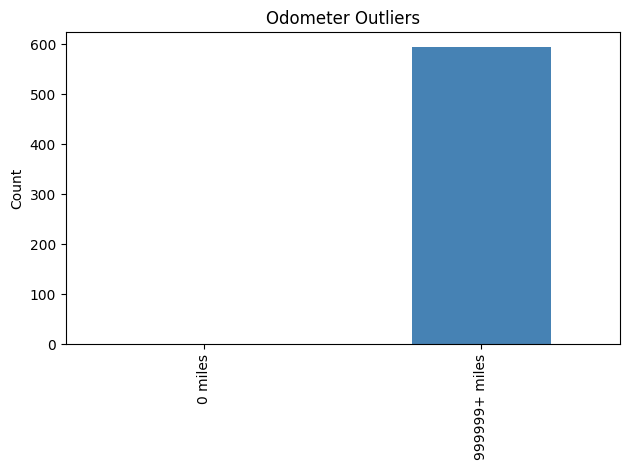

In [71]:
# Q92

odometer_outliers = df_ls[
    (df_ls['odometer'] == 0) |
    (df_ls['odometer'] >= 999999)
].shape[0]

print("Odometer outliers:", odometer_outliers)

odometer_df = pd.Series({
    '0 miles': (df_ls['odometer'] == 0).sum(),
    '999999+ miles': (df_ls['odometer'] >= 999999).sum()
})

odometer_df.plot(kind='bar', color='steelblue')

plt.title('Odometer Outliers')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

Valid VIN percentage: 61.79%


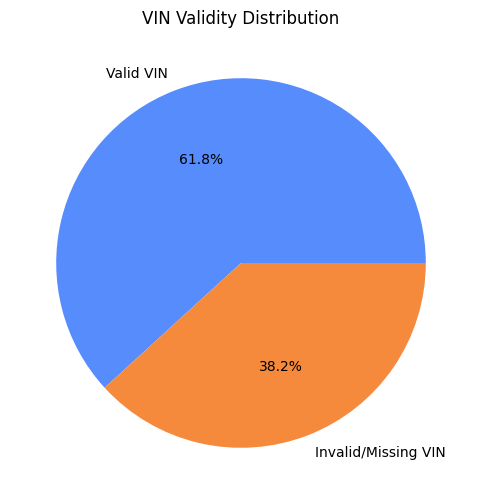

In [72]:
# Q93

valid_vin = df_ls[
    df_ls['vin'].notna() &
    (df_ls['vin'].astype(str).str.lower() != 'unknown')
].shape[0]

total = len(df_ls)

percentage = (valid_vin / total) * 100

print(f"Valid VIN percentage: {percentage:.2f}%")

vin_df = pd.Series({
    'Valid VIN': valid_vin,
    'Invalid/Missing VIN': total - valid_vin
})

vin_df.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))

plt.title('VIN Validity Distribution')
plt.ylabel('')

plt.show()

## **Advanced** ##

          price  year  odometer
price      1.00  0.39     -0.20
year       0.39  1.00     -0.18
odometer  -0.20 -0.18      1.00


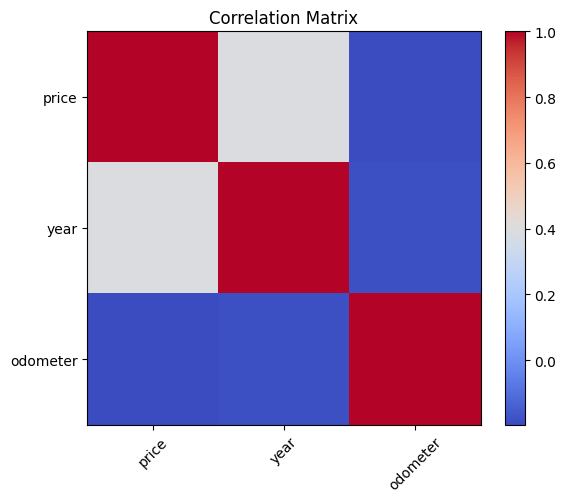

In [73]:
# Q94 Build a correlation matrix across price, year, odometer, and cylinders.
corr_df = df_ls[['price', 'year', 'odometer']].copy()

corr_matrix = corr_df.corr()

print(corr_matrix)

plt.figure(figsize=(6,5))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [74]:
# Q95 Which combination of manufacturer + model + year has the best price-to-mileage value?
df_value = df_ls.copy()

df_value['price_per_mile'] = df_value['price'] / (df_value['odometer'] + 1)

best_value = (
    df_value.groupby(['manufacturer', 'model', 'year'])['price_per_mile']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(best_value)

manufacturer  model                    year
chevrolet     suburban                 2021   31,089.11
dodge         charger                  2005   25,000.00
jaguar        xk120                    1951   24,975.00
ford          explorer limited 4x4     2021   24,283.50
gmc           sierra 3500 all terrain  2016   22,931.50
ford          mustang gt premium       2021   22,758.50
              f-250 stx                2017   21,994.00
chevrolet     roadster pickup          1932   19,750.00
ford          f-250 xlt                2017   19,112.53
chevrolet     silverado lt z71         2016   18,975.00
Name: price_per_mile, dtype: float64
